In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

iitm21f1006434_dsaisqlite2hql_path = kagglehub.dataset_download('iitm21f1006434/dsaisqlite2hql')

print('Data source import complete.')


100%|██████████| 257k/257k [00:00<00:00, 53.1MB/s]

Extracting files...
Data source import complete.


In [6]:
!pip install transformers>=4.40.0 datasets evaluate sacrebleu \
            torch torchvision accelerate sentencepiece sqlglot -q
!pip install faiss-cpu sentence-transformers rouge-score -q
!pip install peft -q                        # LoRA / PEFT support
!pip install --upgrade huggingface_hub -q
!pip install requests beautifulsoup4 lxml -q


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 15.3 MB/s eta 0:00:00


In [7]:
import os
from google.colab import drive

# Ensure the mount point is clean before attempting to mount
if os.path.exists('/content/drive'):
    try:
        # Attempt to unmount if it's already mounted to avoid issues
        drive.flush_and_unmount()
    except:
        pass # Ignore errors if not actually mounted
    # Recursively remove the directory if it still exists and is not empty
    os.system('rm -rf /content/drive/*')
    os.system('rmdir /content/drive 2>/dev/null') # Remove if empty, ignore if not

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Train Config

In [8]:
import os

# ── Platform selector — change only this one variable ────────────────────────
PLATFORM = 'colab'   # 'kaggle' | 'colab' | 'runpod' | 'local'
#The data already exists in dataset dsaisqlite2hql. Would you like to continue creating this dataset?
BASE = {
    'kaggle'  : '/kaggle/input/datasets/iitm21f1006434/dsaisqlite2hql',
    'colab'   : '/content/drive/MyDrive/DSAI_project',
    'runpod'  : '/workspace/DSAI_project',
    'local'   : './data',
}[PLATFORM]

HF_CACHE = {
    'kaggle' : '/kaggle/working/hf_cache',
    'colab'  : '/content/drive/MyDrive/hf_cache',
    'runpod' : '/workspace/hf_cache',
    'local'  : './hf_cache',
}[PLATFORM]

os.environ['HF_DATASETS_CACHE'] = HF_CACHE
os.makedirs(HF_CACHE, exist_ok=True)
print(f"HF_DATASETS_CACHE = {HF_CACHE}")

train_config = {
    # Model
    'model_name'       : 't5-base',
    'src_pfx'          : '<sqlite>',
    'tgt_pfx'          : '<hive>',
    'ctx_pfx'          : '<context>',
    'ex_pfx'           : '<examples>',
    'cot_trigger'      : 'Translate step-by-step:',
    # ── Memory-optimised sequence lengths ──────────────────────────────────
    'max_ip_ln'        : 512,  # increased from 384 to fit full RAG+FSP+CoT budget
    'max_op_ln'        : 256,
    # DATA
    'train_file'  : f'{BASE}/split/train.csv',
    'valid_file'  : f'{BASE}/split/val.csv',
    'test_file'   : f'{BASE}/split/test.csv',
    'sqlite_doc_file' : f'{BASE}/docs/sqlite_syntax.txt',
    'hive_doc_file'   : f'{BASE}/docs/hiveql_syntax.txt',
    'schema_file'     : f'{BASE}/docs/parrot_schema.txt',
    # RAG
    'retriever_model' : 'microsoft/codebert-base',
    'reranker_model'  : 'cross-encoder/ms-marco-MiniLM-L-6-v2',
    # HyDE (Hypothetical Document Embedding) settings
    # HyDE generates a hypothetical HiveQL translation of the input SQLite
    # query and uses THAT as the retrieval query instead of the raw SQLite.
    # This closes the vocabulary gap between SQLite queries and HiveQL docs.
    'use_hyde'         : False,   # enable HyDE retrieval globally
    'hyde_max_tokens'  : 64,     # max tokens for hypothetical HiveQL
    'hyde_num_beams'   : 2,      # beam width for hypothesis generation
    'rag_top_k'       : 5,
    'rag_top_n'       : 2,
    'chunk_size'      : 150,
    'chunk_overlap'   : 30,
    # Few-shot
    'fsp_n_shots'     : 1,
    'fsp_pool_size'   : 200,
    # CoT
    'cot_fraction'    : 0.3,
    'cot_sep'         : ' Answer: ',
    # ── LoRA settings ──────────────────────────────────────────────────────
    # Set use_lora=True to enable LoRA for any experiment.
    # When True, only LoRA adapter weights are trained (~1% of params),
    # saving ~2.7 GB of optimizer + gradient memory on the T4.
    'use_lora'         : False,  # default off; overridden per experiment
    'lora_r'           : 16,     # rank — higher = more capacity, more memory
    'lora_alpha'       : 32,     # scaling (usually 2 × r)
    'lora_dropout'     : 0.1,
    # T5 attention projection names that LoRA wraps
    'lora_target_modules' : ['q', 'v'],   # query + value projections
    # ── Training settings ──────────────────────────────────────────────────
    'num_epochs'       : 10,
    'batch_size'       : 4,
    'grad_accum_steps' : 8,
    'learning_rate'    : 3e-4,
    'warmup_ratio'     : 0.06,
    'weight_decay'     : 0.01,
    'lr_scheduler'     : 'cosine',
    'fp16'             : True,
    # Generation
    'num_beams'        : 4,
    'early_stopping'   : False,
    'max_new_tokens'   : 320,
    # Checkpointing
    'ckpt_dir'         : 'checkpoints',
    'save_total_lmt'   : None,
    'metric_for_best'  : 'eval_exact_match',
    'seed'             : 42,
}

print(f"Platform : {PLATFORM}")
print(f"Base path: {BASE}")
print(f"Effective batch size: {train_config['batch_size']} x {train_config['grad_accum_steps']} = {train_config['batch_size']*train_config['grad_accum_steps']}")
print(f"Max input length : {train_config['max_ip_ln']}")
print(f"LoRA enabled by default: {train_config['use_lora']}  (overridden per experiment)")


HF_DATASETS_CACHE = /content/drive/MyDrive/hf_cache
Platform : colab
Base path: /content/drive/MyDrive/DSAI_project
Effective batch size: 4 x 8 = 32
Max input length : 512
LoRA enabled by default: False  (overridden per experiment)


In [9]:
import random, os, re, time, warnings, pickle
import numpy as np
import torch
import pandas as pd
warnings.filterwarnings('ignore')


In [10]:
import gc, os

# ── Environment-level memory optimisation flags ───────────────────────────
# Tell PyTorch to use expandable memory segments — reduces fragmentation,
# which is the most common cause of "OOM even though plenty of free memory"
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'  # FIX: correct env var name

# Limit HuggingFace datasets arrow cache to avoid filling /tmp
#os.environ['HF_DATASETS_CACHE'] = '/kaggle/working/hf_cache'   # adjust per platform
os.makedirs(os.environ['HF_DATASETS_CACHE'], exist_ok=True)

def gpu_snapshot(label: str = ''):
    """Print current GPU memory usage. Call whenever you suspect pressure."""
    if not torch.cuda.is_available():
        print("No GPU detected.")
        return
    alloc  = torch.cuda.memory_allocated()  / 1e9
    reserv = torch.cuda.memory_reserved()   / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    free   = total - reserv
    bar    = int(reserv / total * 30)
    print(f"GPU [{label}]  "
          f"alloc={alloc:.2f}  reserv={reserv:.2f}  free={free:.2f}  "
          f"total={total:.2f} GB  "
          f"[{'#'*bar}{'.'*(30-bar)}]")

def free_gpu(label: str = ''):
    """Aggressive GPU + RAM cleanup. Call between experiments."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
    gpu_snapshot(label)

print("Memory utilities ready.")
print("PYTORCH_CUDA_ALLOC_CONF =", os.environ.get('PYTORCH_CUDA_ALLOC_CONF'))


Memory utilities ready.
PYTORCH_CUDA_ALLOC_CONF = expandable_segments:True


In [11]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(train_config['seed'])
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
print(f"Model  : {train_config['model_name']}")
print(f"Max input length : {train_config['max_ip_ln']}")


Device : cuda
Model  : t5-base
Max input length : 512


In [12]:
from datasets import Dataset

In [13]:
train_df = pd.read_csv(train_config['train_file'])
val_df   = pd.read_csv(train_config['valid_file'])
test_df  = pd.read_csv(train_config['test_file'])


In [14]:
print("Split sizes:")
print(f"  train : {len(train_df):,}  val : {len(val_df):,}  test : {len(test_df):,}")
print("\nComplexity (train):")
print(train_df['complexity'].value_counts().to_string())
train_ds = Dataset.from_pandas(train_df[['sqlite','hive']].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df  [['sqlite','hive']].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df [['sqlite','hive']].reset_index(drop=True))
print("\nDatasets ready.")


Split sizes:
  train : 3,064  val : 963  test : 888

Complexity (train):
complexity
High Complexity      1607
Medium Complexity     844
Low Complexity        613

Datasets ready.


#Tokenization

In [2]:
from transformers import T5Tokenizer

In [16]:
tokenizer = T5Tokenizer.from_pretrained(train_config['model_name'])
# FIX: Added '<hive>' to match tgt_pfx in train_config (was only '<hiveql>' before)
# Both tokens are registered so normalise_sql/is_valid_hive can strip either prefix.
num_added = tokenizer.add_tokens(
    ['<sqlite>', '<hive>', '<hiveql>', '<context>', '<examples>', '<sep>'],
    special_tokens=True
)
print(f"Special tokens added : {num_added}")
print(f"Vocabulary size      : {len(tokenizer):,}")
print("Tokens: <sqlite> <hive> <hiveql> <context> <examples> <sep>")


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Special tokens added : 6
Vocabulary size      : 32,106
Tokens: <sqlite> <hive> <hiveql> <context> <examples> <sep>


In [17]:
def preprocess(batch):
    """Baseline preprocessing — no RAG, no FSP, no CoT."""
    inputs  = [train_config['src_pfx'] + q for q in batch['sqlite']]
    targets = [train_config['tgt_pfx'] + q for q in batch['hive']]
    model_inputs = tokenizer(inputs, max_length=train_config['max_ip_ln'],
                              padding='max_length', truncation=True)
    labels = tokenizer(targets, max_length=train_config['max_op_ln'],
                       padding='max_length', truncation=True)
    model_inputs['labels'] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in lbl]
        for lbl in labels['input_ids']
    ]
    return model_inputs


In [18]:
tokenised_train = train_ds.map(preprocess, batched=True, remove_columns=['sqlite','hive'])
tokenised_val   = val_ds.map(preprocess,   batched=True, remove_columns=['sqlite','hive'])
tokenised_test  = test_ds.map(preprocess,  batched=True, remove_columns=['sqlite','hive'])
print("Baseline tokenised splits ready.")


Map:   0%|          | 0/3064 [00:00<?, ? examples/s]

Map:   0%|          | 0/963 [00:00<?, ? examples/s]

Map:   0%|          | 0/888 [00:00<?, ? examples/s]

Baseline tokenised splits ready.


In [19]:
sample_src = train_config['src_pfx'] + train_df['sqlite'].iloc[0]
sample_tgt = train_config['tgt_pfx'] + train_df['hive'].iloc[0]
print(f"Sample input  : {sample_src[:120]}")
print(f"Input tokens  : {tokenizer(sample_src, return_length=True)['length'][0]}")


Sample input  : <sqlite>SELECT DISTINCT COUNT( PAPERalias0.PAPERID ) FROM AUTHOR AS AUTHORalias0 , PAPER AS PAPERalias0 , WRITES AS WRIT
Input tokens  : 149


#Model initialization

In [20]:
from transformers import T5ForConditionalGeneration
import gc

# ── Free any leftover GPU memory before loading ───────────────────────────
# This matters if you re-run this cell or came from a crashed experiment
if 'model' in dir() and model is not None:
    del model
gc.collect()
torch.cuda.empty_cache()

model = T5ForConditionalGeneration.from_pretrained(train_config['model_name'])
model.resize_token_embeddings(len(tokenizer))
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")
print(f"Model on device      : {next(model.parameters()).device}")

if device == 'cuda':
    alloc = torch.cuda.memory_allocated() / 1e9
    reserv= torch.cuda.memory_reserved()  / 1e9
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory — allocated: {alloc:.2f} GB  reserved: {reserv:.2f} GB  total: {total_mem:.2f} GB")
    print(f"GPU memory free after model load: {total_mem - reserv:.2f} GB")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Total parameters     : 222,886,656
Trainable parameters : 222,886,656
Model on device      : cuda:0
GPU memory — allocated: 0.89 GB  reserved: 0.90 GB  total: 15.64 GB
GPU memory free after model load: 14.73 GB


#Evaluation Metrics

In [21]:
import evaluate, sqlglot
bleu_metric = evaluate.load('sacrebleu')


In [22]:
def normalise_sql(sql: str) -> str:
    clean = sql.strip()
    for tag in ('<hive>', '<hiveql>', '<sqlite>'):
        if clean.startswith(tag):
            clean = clean[len(tag):].strip()
            break
    return ' '.join(clean.lower().split())
    #return ' '.join(sql.lower().split())

#def is_valid_hive(sql: str) -> bool:
 #   clean = sql.strip()
  #  for tag in ('<hive>', '<hiveql>', '<sqlite>'):
   #     if clean.startswith(tag):
    #        clean = clean[len(tag):].strip()
     #       break
    #return ' '.join(clean.lower().split())
    #try:
     #   sqlglot.parse_one(sql, read='hive')
     #   return True
    #except Exception:
     #   return False
def is_valid_hive(sql) -> bool:
    try:
        if not isinstance(sql, str):
            return False
        clean = sql.strip()
        for tag in ['<hiveql>', '<hive>']:
            if clean.startswith(tag):
                clean = clean[len(tag):].strip()
                break
        if not clean or len(clean.split()) < 3:  # FIX: guard empty/truncated
            return False
        sqlglot.parse_one(clean, read='hive')
        return True
    except Exception:
        return False

#def is_valid_hive(sql) -> bool:
#    """Parse-check a HiveQL string. Returns False for any non-string input."""
#    try:
#        if not isinstance(sql, str):
#            return False
#        clean = sql.strip()
#        for tag in ['<hiveql>', '<hive>']:  # FIX: was iterating over chars, now a proper list
#            if clean.startswith(tag):
#                clean = clean[len(tag):].strip()
#                break
#        if not clean:
#            return False
#        sqlglot.parse_one(clean, read='hive')
#        return True
#    except Exception:
#        return False

def strip_cot(text: str) -> str:
    """Remove CoT reasoning prefix; keep only text after 'Answer:'."""
    sep = train_config['cot_sep'].strip()
    if sep in text:
        return text.split(sep, 1)[-1].strip()
    return text.strip()

def compute_metrics(predictions: list, references: list) -> dict:
    clean_preds = [strip_cot(p) for p in predictions]
    norm_preds  = [normalise_sql(p) for p in clean_preds]
    norm_refs   = [normalise_sql(r) for r in references]
    em   = sum(p==r for p,r in zip(norm_preds,norm_refs)) / max(len(norm_preds),1)
    bleu = bleu_metric.compute(predictions=norm_preds,
                                references=[[r] for r in norm_refs])['score']
    pv   = sum(is_valid_hive(p) for p in norm_preds) / max(len(norm_preds),1)
    return {'exact_match': round(em*100,2), 'bleu': round(bleu,2),
            'parse_validity': round(pv*100,2)}


In [23]:
def compute_metrics_trainer(eval_pred):
    preds, labels = eval_pred
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    preds  = np.clip(preds,  0, len(tokenizer)-1)
    labels = np.clip(labels, 0, len(tokenizer)-1)
    decoded_preds  = tokenizer.batch_decode(preds.tolist(),  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels.tolist(), skip_special_tokens=True)
    return compute_metrics(decoded_preds, decoded_labels)

print("Metric functions ready (strip_cot applied automatically).")


Metric functions ready (strip_cot applied automatically).


---
# Milestone 4: Model Training

Pipeline built in this notebook:

| Step | What happens |
|---|---|
| RAG Step 1 | Chunk + embed SQLite docs, HiveQL docs, PARROT schema → FAISS index |
| RAG Step 2 | Bi-encoder retrieve top-k → cross-encoder rerank → top-n |
| RAG Step 2.5 | **HyDE**: T5 generates hypothetical HiveQL → embed that for retrieval |
| FSP Step 3 | Dynamically retrieve 1 similar training example per query |
| CoT Step 4 | Annotate 30% of training targets with reasoning traces |
| Step 5 | Assemble: `<sqlite> query <context> chunks <examples> ex CoT-trigger` |
| Exps 1–12 | Systematic ablations: baseline → RAG → FSP → CoT → full → best config |
| Exps 13–17 | **LoRA experiments**: LoRA baseline, LoRA+RAG, LoRA+Full, rank ablation |

**HyDE (Hypothetical Document Embedding) — how it helps:**
Standard RAG embeds the raw SQLite query. SQLite vocabulary (`INTEGER`,
`strftime`, `GROUP_CONCAT`) differs from HiveQL documentation vocabulary
(`BIGINT`, `date_format`, `COLLECT_LIST`). HyDE bridges this gap: T5
generates a hypothetical HiveQL translation of the input, then that
hypothesis is embedded as the retrieval query. The hypothesis need not be
correct — it just needs to use HiveQL vocabulary to retrieve relevant docs.

**Memory budget on T4 (15 GB):**

| Technique | Memory saving | Mechanism |
|---|---|---|
| `batch_size=4` | ~3 GB | Fewer activations per step |
| Gradient checkpointing | ~1 GB | Recompute activations on backward pass |
| LoRA (r=16) | ~2.7 GB | Only 2.4M params trained — tiny optimizer state |
| `fp16=True` | ~900 MB | Half-precision weights and activations |
| HyDE on CPU | 0 MB GPU | Hypothesis generation never touches GPU |


---
## RAG Step 1 — Build Knowledge Base

Three document sources are chunked, embedded with a sentence-transformer,
and stored in a FAISS cosine-similarity index.


In [24]:
import faiss
from sentence_transformers import SentenceTransformer
from typing import List, Dict

def chunk_text(text: str, chunk_size: int = 200, overlap: int = 50) -> List[str]:
    words = text.split()
    chunks, start = [], 0
    while start < len(words):
        chunks.append(' '.join(words[start:start+chunk_size]))
        start += chunk_size - overlap
    return [c for c in chunks if len(c.split()) > 10]

#def load_doc(path: str, label: str) -> List[Dict]:
#   if not os.path.exists(path):
#        print(f"  [WARN] {path} not found — using placeholder.")
#        placeholder = (
#            f"{label} placeholder. SELECT FROM WHERE GROUP BY ORDER BY HAVING "
#            "JOIN LIMIT. HiveQL uses BIGINT. COLLECT_SET for arrays. "
#            "LATERAL VIEW EXPLODE for unnesting. DISTRIBUTE BY CLUSTER BY. "
#        ) * 10
#        return [{'text':c,'source':label} for c in chunk_text(
#            placeholder, train_config['chunk_size'], train_config['chunk_overlap'])]
#    with open(path,'r',encoding='utf-8') as f: raw = f.read()
#    return [{'text':c,'source':label} for c in chunk_text(
#        raw, train_config['chunk_size'], train_config['chunk_overlap'])]

#print("Loading knowledge sources...")
#sqlite_chunks = load_doc(train_config['sqlite_doc_file'], 'sqlite_docs')
#hive_chunks   = load_doc(train_config['hive_doc_file'],   'hiveql_docs')
#schema_chunks = load_doc(train_config['schema_file'],     'schema')
#all_chunks    = sqlite_chunks + hive_chunks + schema_chunks
#chunk_texts   = [c['text'] for c in all_chunks]
#print(f"  Total chunks : {len(all_chunks)}")


In [25]:
import requests
from bs4 import BeautifulSoup
import time, re
from typing import List, Dict

# ── URL lists for each knowledge source ──────────────────────────────────────
SQLITE_URLS = [
    "https://www.sqlite.org/lang_select.html",
    "https://www.sqlite.org/lang_insert.html",
    "https://www.sqlite.org/lang_update.html",
    "https://www.sqlite.org/lang_delete.html",
    "https://www.sqlite.org/lang_with.html",
    "https://www.sqlite.org/lang_aggfunc.html",
    "https://www.sqlite.org/lang_corefunc.html",
    "https://www.sqlite.org/lang_datefunc.html",
    "https://www.sqlite.org/datatype3.html",
    "https://www.sqlite.org/windowfunctions.html",
]

HIVEQL_URLS = [
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+Select",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+GroupBy",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+Joins",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+SortBy",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+SubQueries",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+UDF",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+DDL",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+WindowingAndAnalytics",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+Types",
    "https://cwiki.apache.org/confluence/display/Hive/LanguageManual+LateralView",
]

In [26]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (compatible; DSAI-RAG-Bot/1.0; "
        "research project; contact: your@email.com)"
    )
}

def scrape_url(url: str, label: str,
               retry: int = 3, delay: float = 1.5) -> str:
    """
    Fetch a documentation page and return clean plain text.
    Strips navigation, code blocks, sidebars, and HTML tags.
    Returns empty string on failure (so pipeline degrades gracefully).
    """
    for attempt in range(retry):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            resp.raise_for_status()
            soup = BeautifulSoup(resp.text, 'lxml')

            # Remove boilerplate elements common across both doc sites
            for tag in soup.find_all([
                'nav', 'header', 'footer', 'aside',
                'script', 'style', 'noscript',
            ]):
                tag.decompose()

            # Remove Confluence sidebar/breadcrumb divs
            for cls in ['aui-sidebar', 'breadcrumb-section',
                        'page-metadata', 'footer-body',
                        'ia-fixed-sidebar', 'wiki-content-footer']:
                for el in soup.find_all(class_=cls):
                    el.decompose()

            # Extract main content area — try common content containers
            main = (
                soup.find('div', id='wikiBody')           # Confluence
                or soup.find('div', class_='wiki-content')
                or soup.find('div', id='contentSql')      # sqlite.org
                or soup.find('div', id='content')
                or soup.find('main')
                or soup.find('article')
                or soup.body
            )
            if main is None:
                return ''

            # Get text: preserve paragraph breaks, collapse whitespace
            paragraphs = []
            for elem in main.find_all(['p', 'li', 'td', 'th', 'h1',
                                        'h2', 'h3', 'h4', 'pre']):
                text = elem.get_text(separator=' ', strip=True)
                # Skip very short strings (nav labels, page numbers)
                if len(text.split()) >= 5:
                    paragraphs.append(text)

            full_text = '\n'.join(paragraphs)
            # Collapse excessive whitespace
            full_text = re.sub(r'\n{3,}', '\n\n', full_text)
            full_text = re.sub(r'[ \t]{2,}', ' ', full_text)

            time.sleep(delay)   # polite crawl delay
            return full_text

        except requests.exceptions.RequestException as e:
            print(f"  [WARN] attempt {attempt+1} failed for {url}: {e}")
            time.sleep(delay * 2)

    print(f"  [WARN] all {retry} attempts failed for {url} — skipping.")
    return ''


def scrape_url_list(urls: List[str], label: str) -> List[Dict]:
    """
    Scrape a list of URLs, chunk each page, and return
    a flat list of {text, source, url} dicts.
    """
    all_doc_chunks = []
    for i, url in enumerate(urls, 1):
        print(f"  [{i}/{len(urls)}] {url.split('/')[-1][:50]}...", end=' ')
        raw = scrape_url(url, label)
        if not raw.strip():
            print("EMPTY — skipped")
            continue
        page_chunks = chunk_text(
            raw,
            train_config['chunk_size'],
            train_config['chunk_overlap']
        )
        for chunk in page_chunks:
            all_doc_chunks.append({
                'text'  : chunk,
                'source': label,
                'url'   : url,
            })
        print(f"{len(page_chunks)} chunks")

    print(f"  Total {label} chunks: {len(all_doc_chunks)}")
    return all_doc_chunks


def schema_to_chunks(df: pd.DataFrame) -> List[Dict]:
    """
    Generate one chunk per unique table in the dataset.
    Each chunk describes the table name and all column names
    that appear in the SQLite queries referencing that table.

    This does not require any external file — it derives schema
    information directly from the training dataframe itself.
    """
    import re as _re
    table_columns: Dict[str, set] = {}

    for sql in df['sqlite'].tolist() + df['hive'].tolist():
        sql_l = sql.lower()
        # Extract table names after FROM / JOIN
        for m in _re.finditer(
            r'(?:from|join)\s+([a-zA-Z_][a-zA-Z0-9_]*)', sql_l
        ):
            tname = m.group(1)
            if tname not in ('select','where','on','and','or'):
                table_columns.setdefault(tname, set())

        # Extract column-like identifiers (simple heuristic)
        tokens = _re.findall(r'[a-zA-Z_][a-zA-Z0-9_]*', sql_l)
        sql_keywords = {
            'select','from','where','group','by','order','having',
            'join','left','right','inner','outer','on','as','and',
            'or','not','in','is','null','like','between','distinct',
            'count','sum','avg','max','min','cast','case','when',
            'then','else','end','limit','union','intersect','with',
        }
        for tname in table_columns:
            for tok in tokens:
                if (len(tok) > 2
                        and tok not in sql_keywords
                        and tok != tname):
                    table_columns[tname].add(tok)

    schema_chunks = []
    for tname, cols in sorted(table_columns.items()):
        if not cols:
            continue
        col_list = ', '.join(sorted(cols)[:30])  # cap at 30 cols
        text = (
            f"Table: {tname}. "
            f"Columns: {col_list}. "
            f"Use this table in HiveQL with the same name. "
            f"Column types follow HiveQL conventions: "
            f"INTEGER columns map to BIGINT, TEXT to STRING, REAL to DOUBLE."
        )
        schema_chunks.append({
            'text'  : text,
            'source': 'schema',
            'url'   : 'derived_from_dataset',
        })

    print(f"  Schema chunks derived from dataset: {len(schema_chunks)} tables")
    return schema_chunks

In [27]:
# ── schema_to_chunks: derive schema knowledge from PARROT train data ────────
# FIX: This function was called in Cell 27 but never defined. Added here.
def schema_to_chunks(df: pd.DataFrame) -> list:
    """
    Derive schema-level knowledge chunks from the PARROT training dataframe.
    Extracts table names, column patterns, and common SQL constructs so the
    RAG retriever can ground translations in dataset-specific schema context.
    """
    import re
    # Extract table names from FROM / JOIN clauses
    table_pattern = re.compile(r'(?:FROM|JOIN)\s+([a-zA-Z_][a-zA-Z0-9_]*)', re.IGNORECASE)
    tables = set()
    for sql in df['sqlite'].dropna():
        tables.update(table_pattern.findall(sql))

    # Extract column-like identifiers (simple heuristic)
    col_pattern = re.compile(r'SELECT\s+(.+?)\s+FROM', re.IGNORECASE | re.DOTALL)
    col_snippets = []
    for sql in df['sqlite'].dropna().head(200):
        m = col_pattern.search(sql)
        if m:
            col_snippets.append(m.group(1).strip()[:120])

    # Build schema description text
    schema_text = (
        "PARROT dataset schema summary. "
        f"Known tables: {', '.join(sorted(tables)[:50])}. "
        "Common patterns: SELECT with aggregates (COUNT, SUM, AVG), "
        "GROUP BY with HAVING, multi-table JOINs, subqueries, ORDER BY with LIMIT. "
        "SQLite INTEGER maps to HiveQL BIGINT. "
        "SQLite TEXT maps to HiveQL STRING. "
        "SQLite REAL/FLOAT maps to HiveQL DOUBLE. "
        "GROUP_CONCAT in SQLite becomes COLLECT_LIST in HiveQL. "
        "strftime() in SQLite becomes date_format() or from_unixtime() in HiveQL. "
        + " ".join(col_snippets[:20])
    )

    # Chunk the schema text
    chunks = chunk_text(schema_text,
                        chunk_size=train_config['chunk_size'],
                        overlap=train_config['chunk_overlap'])
    result = [{'text': c, 'source': 'schema'} for c in chunks]
    print(f"  Schema chunks derived from {len(tables)} tables, {len(df)} training rows → {len(result)} chunks")
    return result

print("schema_to_chunks() defined.")


schema_to_chunks() defined.


In [28]:
print("=" * 55)
print("BUILDING KNOWLEDGE BASE FROM WEB SOURCES")
print("=" * 55)

print("\n[1/3] Scraping SQLite documentation...")
sqlite_chunks = scrape_url_list(SQLITE_URLS, label='sqlite_docs')

print("\n[2/3] Scraping HiveQL documentation...")
hive_chunks = scrape_url_list(HIVEQL_URLS, label='hiveql_docs')

print("\n[3/3] Deriving schema from PARROT dataset...")
schema_chunks = schema_to_chunks(train_df)

# Combine all sources
all_chunks  = sqlite_chunks + hive_chunks + schema_chunks
chunk_texts = [c['text'] for c in all_chunks]

print(f"\nKnowledge base summary:")
print(f"  SQLite doc chunks : {len(sqlite_chunks)}")
print(f"  HiveQL doc chunks : {len(hive_chunks)}")
print(f"  Schema chunks     : {len(schema_chunks)}")
print(f"  Total             : {len(all_chunks)}")


BUILDING KNOWLEDGE BASE FROM WEB SOURCES

[1/3] Scraping SQLite documentation...
  [1/10] lang_select.html... 61 chunks
  [2/10] lang_insert.html... 9 chunks
  [3/10] lang_update.html... 12 chunks
  [4/10] lang_delete.html... 8 chunks
  [5/10] lang_with.html... 35 chunks
  [6/10] lang_aggfunc.html... 12 chunks
  [7/10] lang_corefunc.html... 32 chunks
  [8/10] lang_datefunc.html... 22 chunks
  [9/10] datatype3.html... 45 chunks
  [10/10] windowfunctions.html... 59 chunks
  Total sqlite_docs chunks: 295

[2/3] Scraping HiveQL documentation...
  [1/10] LanguageManual+Select... 10 chunks
  [2/10] LanguageManual+GroupBy... 6 chunks
  [3/10] LanguageManual+Joins... 34 chunks
  [4/10] LanguageManual+SortBy... 8 chunks
  [5/10] LanguageManual+SubQueries... 3 chunks
  [6/10] LanguageManual+UDF... 114 chunks
  [7/10] LanguageManual+DDL... 137 chunks
  [8/10] LanguageManual+WindowingAndAnalytics... 16 chunks
  [9/10] LanguageManual+Types... 26 chunks
  [10/10] LanguageManual+LateralView... 5 chun

In [29]:
# ── IMPORTANT: bi_encoder and cross_encoder run on CPU ──────────────────
# Sentence-transformers models loaded onto GPU would consume ~400 MB
# of the already-tight T4 budget. Inference on CPU is ~200ms per batch
# which is acceptable since embedding only runs once (offline indexing).

from sentence_transformers import SentenceTransformer, models
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

print(f"Loading CodeBERT bi-encoder on CPU...")

_word_model = models.Transformer(
    train_config['retriever_model'],
    max_seq_length = 512,
)
_pool_model = models.Pooling(
    _word_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens = True,
    pooling_mode_cls_token   = False,
)
bi_encoder = SentenceTransformer(
    modules=[_word_model, _pool_model],
    device='cpu',
)
print(f"  Embedding dim : {bi_encoder.get_sentence_embedding_dimension()}")

t0 = time.time()

chunk_embeddings = bi_encoder.encode(
    chunk_texts,
    batch_size           = 8,    # CodeBERT is 6x larger than MiniLM
    show_progress_bar    = True,
    normalize_embeddings = True,
    convert_to_numpy     = True,
)

#chunk_embeddings = bi_encoder.encode(
#    chunk_texts,
#    batch_size        = 32,   # reduced from 64 — avoids CPU RAM spike
#    show_progress_bar = True,
#    normalize_embeddings = True,
#    convert_to_numpy  = True,
#)
print(f"  Embedded {len(chunk_embeddings)} chunks in {time.time()-t0:.1f}s")
print(f"  Embedding dim: {chunk_embeddings.shape[1]}")

import os
for f in ['rag_index.faiss', 'rag_chunks.pkl']:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted {f} — rebuilding with CodeBERT 768-dim embeddings")

dim   = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(chunk_embeddings.astype('float32'))
faiss.write_index(index, 'rag_index.faiss')
with open('rag_chunks.pkl', 'wb') as f:
    pickle.dump(all_chunks, f)
print(f"  FAISS index: {index.ntotal} vectors  →  rag_index.faiss")



# Free embedding array — no longer needed after index is built
del chunk_embeddings
gc.collect()
print("  Embeddings array freed from RAM.")


Loading CodeBERT bi-encoder on CPU...


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

  Embedding dim : 768


Batches:   0%|          | 0/82 [00:00<?, ?it/s]

  Embedded 656 chunks in 348.5s
  Embedding dim: 768
  FAISS index: 656 vectors  →  rag_index.faiss
  Embeddings array freed from RAM.


---
## RAG Step 2 — Retriever, Reranker & HyDE

**Standard retrieval (bi-encoder → cross-encoder):**
- Bi-encoder (FAISS): embeds query → retrieves top-k candidates
- Cross-encoder reranker: scores each `(query, chunk)` jointly → top-n

**HyDE (Hypothetical Document Embedding):**
HyDE addresses the vocabulary mismatch between SQLite queries and HiveQL
documentation. The raw SQLite query uses SQLite syntax (`INTEGER`, `strftime`,
`GROUP_CONCAT`) while the knowledge base is written in HiveQL terms (`BIGINT`,
`date_format`, `COLLECT_LIST`). A bi-encoder trained on general text finds
this domain gap difficult.

HyDE solves this by:
1. Using the partially-trained T5 model to generate a **hypothetical HiveQL
   translation** of the input SQLite query
2. Embedding that hypothetical HiveQL (not the raw SQLite) as the retrieval query
3. The hypothetical output naturally uses HiveQL vocabulary → retrieved chunks
   are more relevant

**When HyDE is active:** `retrieve_and_rerank_hyde()` is used instead of
`retrieve_and_rerank()`. The two are interchangeable — all downstream code
(dataset build, preprocess functions) uses `retrieve_and_rerank()` which
dispatches to the HyDE version when `train_config['use_hyde'] = True`.


In [30]:
from sentence_transformers import CrossEncoder
import gc

print(f"Loading cross-encoder reranker on CPU: {train_config['reranker_model']}")
cross_encoder = CrossEncoder(train_config['reranker_model'],
                              max_length=256,
                              device='cpu')

# ── Standard retrieval helpers ────────────────────────────────────────────
def retrieve(query: str, k: int = None) -> List[Dict]:
    """Bi-encoder FAISS retrieval — embeds query and returns top-k chunks."""
    k = k or train_config['rag_top_k']
    q_emb = bi_encoder.encode([query], normalize_embeddings=True,
                               convert_to_numpy=True)
    scores, indices = index.search(q_emb.astype('float32'), k)
    return [{'text'  : all_chunks[i]['text'],
             'source': all_chunks[i]['source'],
             'score' : float(scores[0][j])}
            for j, i in enumerate(indices[0])]

def rerank(query: str, candidates: List[Dict], n: int = None) -> List[Dict]:
    """Cross-encoder reranker — rescores candidates and returns top-n."""
    n = n or train_config['rag_top_n']
    if not candidates:
        return []
    scores = cross_encoder.predict(
        [(query, c['text']) for c in candidates],
        show_progress_bar=False,
        batch_size=4,
    )
    for c, s in zip(candidates, scores):
        c['rerank_score'] = float(s)
    return sorted(candidates, key=lambda x: x['rerank_score'], reverse=True)[:n]

def build_context_string(chunks: List[Dict]) -> str:
    return ' <sep> '.join(c['text'] for c in chunks)


# ── HyDE: Hypothetical Document Embedding ────────────────────────────────
# Global reference to the T5 model used for hypothesis generation.
# Set by init_hyde_model() after model is loaded.
_hyde_model = None
_hyde_model_name = train_config['model_name']

def init_hyde_model(model=None):
    """
    Register a T5 model to use for HyDE hypothesis generation.
    Call this after loading any checkpoint. If model=None, loads
    the base T5 from HuggingFace (useful for generating hypotheses
    before any fine-tuning checkpoint is available).

    The model runs on CPU for hypothesis generation to avoid
    interfering with GPU training.
    """
    global _hyde_model
    if model is not None:
        _hyde_model = model
        print(f"  HyDE model registered: {type(model).__name__}")
    else:
        from transformers import T5ForConditionalGeneration
        print(f"  Loading base T5 for HyDE hypothesis generation...")
        _hyde_model = T5ForConditionalGeneration.from_pretrained(
            _hyde_model_name)
        _hyde_model.eval()
        # Keep on CPU — hypothesis generation is a short seq2seq call
        print(f"  HyDE model ready on CPU (base weights)")
    return _hyde_model

def generate_hypothesis(sqlite_query: str) -> str:
    """
    Generate a hypothetical HiveQL translation of a SQLite query.

    Why this works for RAG:
      The raw SQLite query uses SQLite vocabulary (INTEGER, strftime,
      GROUP_CONCAT) while the knowledge base chunks use HiveQL vocabulary
      (BIGINT, date_format, COLLECT_LIST). Embedding the SQLite query
      directly leads to poor chunk retrieval because of this domain gap.

      By generating a hypothetical HiveQL first, even an imperfect one,
      the embedding query uses HiveQL terms that appear in the knowledge
      base → retrieved chunks are more relevant.

    Returns the hypothetical HiveQL string (may be grammatically imperfect).
    Falls back to the original SQLite query if generation fails.
    """
    global _hyde_model
    if _hyde_model is None:
        init_hyde_model()

    try:
        src_text = train_config['src_pfx'] + sqlite_query
        enc = tokenizer(
            src_text,
            max_length=train_config['max_ip_ln'],
            truncation=True,
            return_tensors='pt',
        )
        # Move to same device as model
        _dev = next(_hyde_model.parameters()).device
        enc = {k: v.to(_dev) for k, v in enc.items()}

        with torch.no_grad():
            out = _hyde_model.generate(
                input_ids      = enc['input_ids'],
                attention_mask = enc['attention_mask'],
                num_beams      = train_config['hyde_num_beams'],
                max_new_tokens = train_config['hyde_max_tokens'],
                early_stopping = True,
            )
        hypothesis = tokenizer.decode(out[0], skip_special_tokens=True)
        # Strip dialect prefix tags if present
        for tag in ('<hive>', '<hiveql>'):
            if hypothesis.startswith(tag):
                hypothesis = hypothesis[len(tag):].strip()
                break
        return hypothesis if hypothesis.strip() else sqlite_query
    except Exception as _e:
        # Graceful fallback — never block retrieval due to generation failure
        return sqlite_query
def generate_hypotheses_batch(queries: list,
                               batch_size: int = 16) -> list:
    """
    Generate hypothetical HiveQL for all queries in batches.
    Batched generation is 8-12x faster than one-at-a-time on CPU.
    """
    global _hyde_model
    if _hyde_model is None:
        init_hyde_model()

    _dev  = next(_hyde_model.parameters()).device
    hyps  = []
    total = len(queries)

    for start in range(0, total, batch_size):
        batch_q = queries[start : start + batch_size]

        # Tokenise batch
        enc = tokenizer(
            [train_config['src_pfx'] + q for q in batch_q],
            max_length  = train_config['max_ip_ln'],
            padding     = True,
            truncation  = True,
            return_tensors = 'pt',
        )
        enc = {k: v.to(_dev) for k, v in enc.items()}

        with torch.no_grad():
            out = _hyde_model.generate(
                input_ids      = enc['input_ids'],
                attention_mask = enc['attention_mask'],
                num_beams      = train_config['hyde_num_beams'],
                max_new_tokens = train_config['hyde_max_tokens'],
                early_stopping = True,
            )

        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        for hyp in decoded:
            for tag in ('<hive>', '<hiveql>'):
                if hyp.startswith(tag):
                    hyp = hyp[len(tag):].strip()
                    break
            hyps.append(hyp if hyp.strip() else '')

        if (start + batch_size) % 200 == 0 or start == 0:
            elapsed = time.time() - _t_hyp_start
            done    = min(start + batch_size, total)
            rate    = done / elapsed
            eta     = (total - done) / rate / 60
            print(f"  [{done:>4}/{total}]  "
                  f"{rate:.1f} q/s  "
                  f"ETA {eta:.0f} min")

    return hyps

def retrieve_hyde(query: str, k: int = None) -> List[Dict]:
    """
    HyDE retrieval: generate hypothetical HiveQL → embed that → FAISS search.
    The hypothesis is used ONLY as the embedding query; retrieved chunks
    are real knowledge base documents, not the hypothesis itself.
    """
    k = k or train_config['rag_top_k']
    hypothesis = generate_hypothesis(query)
    # Embed the hypothetical HiveQL, not the raw SQLite
    h_emb = bi_encoder.encode([hypothesis], normalize_embeddings=True,
                               convert_to_numpy=True)
    scores, indices = index.search(h_emb.astype('float32'), k)
    return [{'text'      : all_chunks[i]['text'],
             'source'    : all_chunks[i]['source'],
             'score'     : float(scores[0][j]),
             'hypothesis': hypothesis}          # store for debugging
            for j, i in enumerate(indices[0])]

def retrieve_and_rerank(query: str) -> List[Dict]:
    """
    Main retrieval entry point used by all preprocess functions.
    Dispatches to HyDE retrieval when use_hyde=True, standard otherwise.
    Reranks with cross-encoder in both cases.
    """
    if train_config.get('use_hyde', False):
        candidates = retrieve_hyde(query)
    else:
        candidates = retrieve(query, k=train_config['rag_top_k'])
    return rerank(query, candidates, n=train_config['rag_top_n'])

# ── Sanity check ─────────────────────────────────────────────────────────
test_q = "SELECT COUNT(*) FROM orders WHERE status = 'pending'"
print(f"\nRetrieval test (HyDE={'ON' if train_config['use_hyde'] else 'OFF'}):")
print(f"  Query: {test_q}")

if train_config['use_hyde']:
    # Need model for HyDE — use base weights for sanity check
    init_hyde_model()
    hyp = generate_hypothesis(test_q)
    print(f"  Hypothesis: {hyp[:100]}")

res = retrieve_and_rerank(test_q)
print(f"  Retrieved {len(res)} chunks:")
for i, r in enumerate(res, 1):
    print(f"  [{i}] {r['source']}  score={r['rerank_score']:.3f}  {r['text'][:80]}...")


Loading cross-encoder reranker on CPU: cross-encoder/ms-marco-MiniLM-L-6-v2


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]


Retrieval test (HyDE=OFF):
  Query: SELECT COUNT(*) FROM orders WHERE status = 'pending'
  Retrieved 2 chunks:
  [1] hiveql_docs  score=-4.266  T WINDOW w AS (PARTITION BY c ORDER BY d ROWS UNBOUNDED PRECEDING); LEAD using d...
  [2] hiveql_docs  score=-7.940  (SELECT B FROM T2 WHERE T1.X = T2.Y) There are a few limitations: These subqueri...


---
## RAG Step 2.5 — HyDE Model Initialisation

Before building datasets, the T5 model must be registered with the HyDE
retriever. During dataset build (before any fine-tuning), the base T5
weights are used. After each experiment, `init_hyde_model(checkpoint)`
can be called to use a better hypothesis generator.

**Token budget impact of HyDE:**
HyDE adds ~0.2–0.5 seconds per query during dataset build (one T5 forward
pass per query on CPU). For ~4,000 training rows this adds ~15–20 minutes
to the dataset build time. The FAISS index itself is unchanged — only the
query embedding changes.


In [31]:
# ── Initialise HyDE with base T5 model ───────────────────────────────────
# This registers the model used to generate hypothetical HiveQL queries.
# During dataset build we use base weights (no fine-tuning yet).
# After Exp 1 (Baseline) trains, you can call:
#   init_hyde_model(T5ForConditionalGeneration.from_pretrained('checkpoints/Baseline/...'))
# to use a better hypothesis generator for subsequent dataset rebuilds.

if train_config.get('use_hyde', False):
    print("HyDE is ENABLED — initialising hypothesis generator...")
    init_hyde_model()   # loads base T5 on CPU
    # Quick test
    _test_q  = train_df['sqlite'].iloc[0]
    _hyp     = generate_hypothesis(_test_q)
    print(f"\nHyDE test:")
    print(f"  SQLite   : {_test_q[:80]}")
    print(f"  Hypothesis: {_hyp[:80]}")
    print("\nHyDE ready — retrieve_and_rerank() will use hypothetical HiveQL embeddings.")
else:
    print("HyDE is DISABLED — standard bi-encoder retrieval will be used.")
    print("To enable: set train_config['use_hyde'] = True in the config cell.")


HyDE is DISABLED — standard bi-encoder retrieval will be used.
To enable: set train_config['use_hyde'] = True in the config cell.


---
## FSP Step 3 — Few-Shot Example Pool & Dynamic Retrieval

**Why dynamic, not static few-shot?**
Fixed examples work for general-purpose LLMs but T5 has a 512-token budget
shared between the query, RAG context, and examples. We therefore:

1. Build a **separate FAISS index** over a pool of training pairs
   (by default the first `fsp_pool_size` rows).
2. At preprocessing time, embed each SQLite query and retrieve the
   **top-`fsp_n_shots` most similar training examples** (excluding the
   query itself). Similar queries share clauses, tables, and complexity —
   so the examples are maximally relevant.
3. Append them as:
   `<examples> Input: {ex1_sqlite} Output: {ex1_hive} <sep> Input: {ex2_sqlite} Output: {ex2_hive}`

This costs ~60 tokens for 2 examples and is always more helpful than
fixed examples because it mirrors the structure of the current query.


In [32]:
import gc

# ── Build FSP example pool ────────────────────────────────────────────────
fsp_pool = train_df.head(train_config['fsp_pool_size'])[['sqlite','hive']]                   .reset_index(drop=True)

fsp_pool_texts = fsp_pool['sqlite'].tolist()
print(f"Embedding FSP pool ({len(fsp_pool_texts)} training queries) on CPU...")
fsp_embeddings = bi_encoder.encode(
    fsp_pool_texts,
    batch_size           = 32,
    show_progress_bar    = True,
    normalize_embeddings = True,
    convert_to_numpy     = True,
)
fsp_index = faiss.IndexFlatIP(fsp_embeddings.shape[1])
fsp_index.add(fsp_embeddings.astype('float32'))
print(f"  FSP FAISS index built: {fsp_index.ntotal} entries")

# Free FSP embeddings array — index holds the data
del fsp_embeddings
gc.collect()
print("  FSP embeddings array freed from RAM.")

def retrieve_fsp_examples(query: str, n: int = None,
                           exclude_idx: int = -1) -> List[Dict]:
    n = n or train_config['fsp_n_shots']
    q_emb = bi_encoder.encode([query], normalize_embeddings=True,
                               convert_to_numpy=True)
    scores, indices = fsp_index.search(q_emb.astype('float32'), n + 1)
    examples = []
    for idx in indices[0]:
        if idx == exclude_idx:
            continue
        examples.append({'sqlite': fsp_pool.loc[idx, 'sqlite'],
                         'hive'  : fsp_pool.loc[idx, 'hive']})
        if len(examples) == n:
            break
    return examples

def format_fsp_block(examples: List[Dict]) -> str:
    parts = [f"Input: {e['sqlite']} Output: {e['hive']}" for e in examples]
    return train_config['ex_pfx'] + ' ' + ' <sep> '.join(parts)

# Verify
sample_exs = retrieve_fsp_examples(train_df['sqlite'].iloc[5], n=1)
print(f"\nFSP retrieval test (1-shot):")
for i, ex in enumerate(sample_exs, 1):
    print(f"  [{i}] {ex['sqlite'][:70]}")
    print(f"       → {ex['hive'][:70]}")


Embedding FSP pool (200 training queries) on CPU...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

  FSP FAISS index built: 200 entries
  FSP embeddings array freed from RAM.

FSP retrieval test (1-shot):
  [1] SELECT COUNT( DISTINCT COURSE_PREREQUISITEalias0.COURSE_ID ) , COURSEa
       → SELECT COUNT(DISTINCT COURSE_PREREQUISITEalias0.COURSE_ID), COURSEalia


---
## CoT Step 4 — Chain-of-Thought Annotation

**Why CoT for T5?**
T5 is not a prompted LLM — emergent CoT is weaker than in large autoregressive
models. The most reliable approach is **rationale distillation**: we augment a
fraction of training *targets* with a short reasoning trace. The model learns
to output reasoning before the final HiveQL, which improves structural accuracy
on complex queries.

**Trace format:**
```
Step 1: Identify dialect differences — SQLite INTEGER → HiveQL BIGINT.
Step 2: Check JOIN type — INNER JOIN syntax is identical.
Step 3: GROUP BY and ORDER BY — no changes needed.
Answer: SELECT dept, COUNT(*) FROM employees GROUP BY dept ORDER BY 2 DESC
```

**Annotation strategy:**
- We annotate `cot_fraction` (default 30 %) of training rows.
- Priority: complex queries first (most benefit from explicit reasoning).
- For rows without manual traces we use a **rule-based auto-annotator**
  that identifies known SQLite→HiveQL differences from the translation pair.
- At inference, `strip_cot()` removes everything up to `Answer:` before metrics.


In [33]:
# ── Rule-based CoT trace generator ─────────────────────────────────────
DIALECT_RULES = [
    (r'\bINTEGER\b',            'SQLite INTEGER → HiveQL BIGINT'),
    (r'\bREAL\b|\bFLOAT\b',   'SQLite REAL/FLOAT → HiveQL DOUBLE'),
    (r'\bTEXT\b',               'SQLite TEXT → HiveQL STRING'),
    (r'\bGROUP_CONCAT\b',       'GROUP_CONCAT → COLLECT_LIST in HiveQL'),
    (r'\bstrftime\b',           'strftime → from_unixtime/date_format in HiveQL'),
    (r'\bCAST\b',               'CAST syntax retained; verify type names'),
    (r'\bLIMIT\b',              'LIMIT clause — same syntax in HiveQL'),
    (r'\bJOIN\b',               'JOIN — syntax identical in HiveQL'),
    (r'\bGROUP BY\b',           'GROUP BY — same syntax; result type may differ'),
    (r'\bHAVING\b',             'HAVING — same syntax in HiveQL'),
    (r'\bWITH\b',               'CTE (WITH clause) — supported in HiveQL 0.13+'),
    (r'\bDISTINCT\b',           'DISTINCT — same syntax in HiveQL'),
    (r'\bLIKE\b',               'LIKE — same syntax; HiveQL also supports RLIKE'),
    (r'\bSUBSTR\b|\bSUBSTRING\b', 'SUBSTR/SUBSTRING — same in HiveQL'),
    (r'\bCOUNT\b',              'COUNT returns BIGINT in HiveQL'),
    (r'\bSUM\b|\bAVG\b',       'SUM/AVG — same syntax; result types differ'),
]

def generate_cot_trace(sqlite_sql: str, hive_sql: str) -> str:
    """
    Auto-generate a CoT reasoning trace by scanning the SQLite query
    for known dialect-difference patterns.
    Returns a full trace ending with the HiveQL answer.
    """
    steps = []
    for pattern, note in DIALECT_RULES:
        if re.search(pattern, sqlite_sql, re.IGNORECASE):
            steps.append(note)

    if not steps:
        steps.append('No dialect differences detected — direct translation applies')

    trace_lines = [f"Step {i+1}: {s}." for i,s in enumerate(steps)]
    trace = ' '.join(trace_lines)
    return trace + train_config['cot_sep'] + hive_sql

# ── Annotate cot_fraction of training data ────────────────────────────────
train_df_cot = train_df.copy().reset_index(drop=True)

# Sort so complex queries get annotated first
if 'complexity' in train_df_cot.columns:
    priority_order = {'complex':0,'medium':1,'simple':2}
    train_df_cot['_sort'] = train_df_cot['complexity'].map(priority_order).fillna(3)
    train_df_cot = train_df_cot.sort_values('_sort').drop('_sort',axis=1)

n_cot = int(len(train_df_cot) * train_config['cot_fraction'])
train_df_cot['use_cot'] = False
train_df_cot.iloc[:n_cot, train_df_cot.columns.get_loc('use_cot')] = True

train_df_cot['hive_target'] = train_df_cot.apply(
    lambda r: generate_cot_trace(r['sqlite'], r['hive'])
              if r['use_cot'] else r['hive'],
    axis=1
)

print(f"CoT annotation complete:")
print(f"  Total training rows : {len(train_df_cot)}")
print(f"  CoT-annotated rows  : {train_df_cot['use_cot'].sum()} ({train_config['cot_fraction']*100:.0f}%)")
print(f"  Standard rows       : {(~train_df_cot['use_cot']).sum()}")

# Show a sample CoT target
cot_sample = train_df_cot[train_df_cot['use_cot']].iloc[0]
print(f"\nSample CoT target:")
print(f"  Input  : {cot_sample['sqlite'][:100]}")
print(f"  Target : {cot_sample['hive_target'][:200]}")


CoT annotation complete:
  Total training rows : 3064
  CoT-annotated rows  : 919 (30%)
  Standard rows       : 2145

Sample CoT target:
  Input  : SELECT A.concert_Name, 1.0 * (COUNT(DISTINCT (B.Singer_ID)) + 1) / (SELECT COUNT(DISTINCT (B.Singer_
  Target : Step 1: JOIN — syntax identical in HiveQL. Step 2: GROUP BY — same syntax; result type may differ. Step 3: HAVING — same syntax in HiveQL. Step 4: DISTINCT — same syntax in HiveQL. Step 5: COUNT retur


---
## Step 5 — Unified Input Assembler & Dataset Variants

We build **five tokenised dataset variants** that can be selected per experiment:

| Variant | RAG | HyDE | FSP | CoT targets |
|---|---|---|---|---|
| `tokenised_*` | ✗ | ✗ | ✗ | ✗ |
| `rag_tokenised_*` | ✓ | ✓ (if enabled) | ✗ | ✗ |
| `fsp_tokenised_*` | ✓ | ✓ (if enabled) | ✓ | ✗ |
| `cot_tokenised_*` | ✓ | ✓ (if enabled) | ✗ | ✓ |
| `full_tokenised_*` | ✓ | ✓ (if enabled) | ✓ | ✓ |

**HyDE behaviour in dataset build:**
When `use_hyde=True`, every call to `retrieve_and_rerank(q)` inside
`make_preprocess_fn` automatically uses the HyDE path — no changes needed
in the preprocess functions themselves. Toggle `train_config['use_hyde']`
to switch between standard and HyDE retrieval for all variants at once.

**Input format (full pipeline with HyDE):**
```
SQLite query → T5 generates hypothetical HiveQL → embed hypothesis
→ FAISS retrieves top-k chunks → cross-encoder reranks → top-n context

Final input:
<sqlite> {sqlite_query} <context> {chunk1} <sep> {chunk2}
         <examples> Input:{ex_sql} Output:{ex_hive}
         Translate step-by-step:
```


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FAST DATASET BUILD — pre-computed embeddings
# ══════════════════════════════════════════════════════════════════════════
# Root cause of slowness: bi_encoder.encode([single_query]) is called once
# per row inside Dataset.map(). Each call is a full CodeBERT forward pass
# (~0.5s). For 3,064 rows × 4 variants × 3 splits = ~37,000 calls = 5+ hrs.
#
# Fix: embed ALL queries in one batched call (all rows at once).
# Batched encoding is 15-20x faster — matrix ops parallelise across queries.
# Then pre-compute ALL context strings and FSP blocks before map().
# Dataset.map() then only tokenises (fast CPU string ops, no model calls).
# ══════════════════════════════════════════════════════════════════════════

import gc, os, time, pickle
import numpy as np
import faiss
from datasets import Dataset

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# ── Step 1: Embed ALL queries in one batched call ─────────────────────────
print("Pre-computing query embeddings (single batched encode call)...")
print("This replaces thousands of individual encode([query]) calls.\n")

all_queries = {
    'train': train_df['sqlite'].tolist(),
    'val'  : val_df['sqlite'].tolist(),
    'test' : test_df['sqlite'].tolist(),
}

t0 = time.time()
query_embeddings = {}
for split, queries in all_queries.items():
    print(f"  Embedding {split} ({len(queries)} queries)...")
    # HyDE: generate hypotheses first, then embed them
    if train_config.get('use_hyde', False):
        print(f"    Generating HyDE hypotheses...")
        # Replace this (slow — one query at a time):
        # hypotheses = [generate_hypothesis(q) for q in queries]

        # With this (fast — batched generation):
        _t_hyp_start = time.time()
        print(f"  Generating {len(queries)} hypotheses in batches of 16...")
        hypotheses = generate_hypotheses_batch(queries, batch_size=16)
        print(f"  Done in {(time.time()-_t_hyp_start)/60:.1f} min")
        #hypotheses = [generate_hypothesis(q) for q in queries]
        embs = bi_encoder.encode(
            hypotheses,
            batch_size           = 32,
            show_progress_bar    = True,
            normalize_embeddings = True,
            convert_to_numpy     = True,
        )
    else:
        embs = bi_encoder.encode(
            queries,
            batch_size           = 32,
            show_progress_bar    = True,
            normalize_embeddings = True,
            convert_to_numpy     = True,
        )
    query_embeddings[split] = embs
    print(f"    Done — shape: {embs.shape}")

print(f"\nAll query embeddings computed in {(time.time()-t0)/60:.1f} min")
gc.collect()


# ── Step 2: Pre-compute top-k candidates for ALL queries ──────────────────
# Run FAISS search in bulk (single matrix multiply for all queries at once)
# then cross-encoder rerank per query — still sequential but no encode cost.
print("\nPre-computing RAG context strings (bulk FAISS + reranking)...")

def bulk_retrieve_and_rerank(queries: list, embs: np.ndarray) -> list:
    """
    Retrieve and rerank for a list of queries using pre-computed embeddings.
    FAISS search is batched (all queries at once — one matrix multiply).
    Cross-encoder reranking is per-query but much cheaper than bi-encoder.
    Returns list of context strings, one per query.
    """
    k = train_config['rag_top_k']
    n = train_config['rag_top_n']

    # Single batched FAISS search — all queries in one call
    scores, indices = index.search(embs.astype('float32'), k)

    context_strings = []
    for qi, (q, q_scores, q_indices) in enumerate(zip(queries, scores, indices)):
        candidates = [
            {'text': all_chunks[i]['text'],
             'source': all_chunks[i]['source'],
             'score': float(q_scores[j])}
            for j, i in enumerate(q_indices)
        ]
        # Cross-encoder reranking (still per-query, but no bi-encoder call)
        if candidates:
            ce_scores = cross_encoder.predict(
                [(q, c['text']) for c in candidates],
                show_progress_bar=False,
                batch_size=4,
            )
            for c, s in zip(candidates, ce_scores):
                c['rerank_score'] = float(s)
            top = sorted(candidates,
                         key=lambda x: x['rerank_score'],
                         reverse=True)[:n]
        else:
            top = []
        ctx = ' <sep> '.join(c['text'] for c in top) if top \
              else 'no context available'
        context_strings.append(ctx)

        if (qi + 1) % 500 == 0:
            print(f"    Reranked {qi+1}/{len(queries)}")

    return context_strings


# Pre-compute context strings for all splits
print("Computing context strings...")
t0 = time.time()
context_cache = {}
for split, queries in all_queries.items():
    print(f"\n  {split} ({len(queries)} queries)...")
    context_cache[split] = bulk_retrieve_and_rerank(
        queries, query_embeddings[split])
    print(f"  Done — {len(context_cache[split])} context strings")

print(f"\nAll context strings computed in {(time.time()-t0)/60:.1f} min")
gc.collect()


# ── Step 3: Pre-compute FSP blocks for ALL queries ────────────────────────
print("\nPre-computing FSP example blocks (batched FSP FAISS search)...")
t0 = time.time()

def bulk_fsp_blocks(queries: list, embs: np.ndarray) -> list:
    """
    Retrieve FSP examples for all queries using pre-computed embeddings.
    Single batched FAISS search over the FSP index.
    """
    n = train_config['fsp_n_shots']
    _, indices = fsp_index.search(embs.astype('float32'), n + 2)
    blocks = []
    for qi, (q, q_indices) in enumerate(zip(queries, indices)):
        examples = []
        for idx in q_indices:
            if not (0 <= idx < len(fsp_pool)):
                continue
            examples.append({
                'sqlite': fsp_pool.loc[idx, 'sqlite'],
                'hive'  : fsp_pool.loc[idx, 'hive'],
            })
            if len(examples) == n:
                break
        if not examples:
            examples = [{'sqlite': fsp_pool.loc[0, 'sqlite'],
                         'hive'  : fsp_pool.loc[0, 'hive']}]
        parts = [f"Input: {e['sqlite']} Output: {e['hive']}"
                 for e in examples]
        blocks.append(train_config['ex_pfx'] + ' ' + ' <sep> '.join(parts))
    return blocks

fsp_cache = {}
for split, queries in all_queries.items():
    print(f"  FSP {split} ({len(queries)} queries)...")
    fsp_cache[split] = bulk_fsp_blocks(queries, query_embeddings[split])

print(f"All FSP blocks computed in {(time.time()-t0)/60:.1f} min")
gc.collect()


# ── Step 4: CoT lookup ────────────────────────────────────────────────────
cot_lookup = dict(zip(train_df_cot['sqlite'], train_df_cot['hive_target']))


# ── Step 5: Fast tokenise-only preprocess (no model calls inside map) ─────
# These functions only do string assembly + tokenisation.
# All expensive retrieval is already done above.

def make_fast_preprocess(split: str, use_ctx: bool, use_fsp: bool,
                          use_cot: bool):
    """
    Returns a preprocess function that looks up pre-computed context
    and FSP strings by row index — no model calls inside map().
    """
    ctx_list = context_cache[split] if use_ctx else None
    fsp_list = fsp_cache[split]     if use_fsp else None

    # Build index map: sqlite query → position in split df
    split_df = {'train': train_df, 'val': val_df, 'test': test_df}[split]
    query_to_idx = {q: i for i, q in enumerate(split_df['sqlite'].tolist())}

    def _preprocess(batch):
        inputs, targets = [], []
        for bi, q in enumerate(batch['sqlite']):
            row_idx = query_to_idx.get(q, 0)
            parts   = [train_config['src_pfx'] + q]

            if use_ctx and ctx_list:
                parts.append(train_config['ctx_pfx'] + ' ' + ctx_list[row_idx])

            if use_fsp and fsp_list:
                parts.append(fsp_list[row_idx])

            raw_hive = batch['hive'][bi]
            hive_tgt = cot_lookup.get(q, raw_hive) if use_cot else raw_hive
            if use_cot and hive_tgt != raw_hive:
                parts.append(train_config['cot_trigger'])

            inputs.append(' '.join(parts))
            targets.append(train_config['tgt_pfx'] + hive_tgt)

        mi = tokenizer(inputs, max_length=train_config['max_ip_ln'],
                       padding='max_length', truncation=True)
        lb = tokenizer(targets, max_length=train_config['max_op_ln'],
                       padding='max_length', truncation=True)
        mi['labels'] = [
            [(t if t != tokenizer.pad_token_id else -100) for t in l]
            for l in lb['input_ids']
        ]
        return mi

    return _preprocess


# ── Step 6: Build all datasets (tokenisation only — very fast) ────────────
print("\nBuilding tokenised datasets (lookup + tokenise only)...")
print("Expected time: ~2-4 min per split (no model calls)\n")

cot_train_ds = Dataset.from_pandas(
    train_df_cot[['sqlite', 'hive']].reset_index(drop=True))

# Build CoT context + FSP caches using train_df_cot queries
# (same queries as train_df — just with hive_target column)
context_cache['cot_train'] = context_cache['train']
fsp_cache['cot_train']     = fsp_cache['train']

# For cot_train, query_to_idx needs to map cot_train queries
cot_query_to_idx = {q: i for i, q in
                    enumerate(train_df_cot['sqlite'].tolist())}

# CoT targets are longer — use a dedicated length:
COT_MAX_OP_LN = 320

def make_cot_fast_preprocess(use_fsp: bool):
    ctx_list = context_cache['cot_train']
    fsp_list = fsp_cache['cot_train'] if use_fsp else None
    def _preprocess(batch):
        inputs, targets = [], []
        for bi, q in enumerate(batch['sqlite']):
            row_idx = cot_query_to_idx.get(q, 0)
            parts   = [train_config['src_pfx'] + q,
                       train_config['ctx_pfx'] + ' ' + ctx_list[row_idx]]
            if use_fsp and fsp_list:
                parts.append(fsp_list[row_idx])
            raw_hive = batch['hive'][bi]
            hive_tgt = cot_lookup.get(q, raw_hive)
            if hive_tgt != raw_hive:
                parts.append(train_config['cot_trigger'])
            inputs.append(' '.join(parts))
            targets.append(train_config['tgt_pfx'] + hive_tgt)
        mi = tokenizer(inputs, max_length=train_config['max_ip_ln'],
                       padding='max_length', truncation=True)
        lb = tokenizer(targets, max_length=COT_MAX_OP_LN,
                       padding='max_length', truncation=True)
        mi['labels'] = [
            [(t if t != tokenizer.pad_token_id else -100) for t in l]
            for l in lb['input_ids']
        ]
        return mi
    return _preprocess

t_total = time.time()

print("[1/4] RAG datasets...")
t0 = time.time()
rag_tokenised_train = train_ds.map(
    make_fast_preprocess('train', True, False, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="RAG train")
rag_tokenised_val = val_ds.map(
    make_fast_preprocess('val', True, False, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="RAG val")
rag_tokenised_test = test_ds.map(
    make_fast_preprocess('test', True, False, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="RAG test")
print(f"  Done in {(time.time()-t0)/60:.1f} min")

print("[2/4] FSP datasets...")
t0 = time.time()
fsp_tokenised_train = train_ds.map(
    make_fast_preprocess('train', True, True, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="FSP train")
fsp_tokenised_val = val_ds.map(
    make_fast_preprocess('val', True, True, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="FSP val")
fsp_tokenised_test = test_ds.map(
    make_fast_preprocess('test', True, True, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="FSP test")
print(f"  Done in {(time.time()-t0)/60:.1f} min")

print("[3/4] CoT datasets...")
t0 = time.time()
cot_tokenised_train = cot_train_ds.map(
    make_cot_fast_preprocess(use_fsp=False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="CoT train")
cot_tokenised_val = val_ds.map(
    make_fast_preprocess('val', True, False, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="CoT val")
cot_tokenised_test = test_ds.map(
    make_fast_preprocess('test', True, False, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="CoT test")
print(f"  Done in {(time.time()-t0)/60:.1f} min")

print("[4/4] Full pipeline datasets...")
t0 = time.time()
full_tokenised_train = cot_train_ds.map(
    make_cot_fast_preprocess(use_fsp=True),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="Full train")
full_tokenised_val = val_ds.map(
    make_fast_preprocess('val', True, True, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="Full val")
full_tokenised_test = test_ds.map(
    make_fast_preprocess('test', True, True, False),
    batched=True, batch_size=64, num_proc=1,
    remove_columns=['sqlite','hive'], desc="Full test")
print(f"  Done in {(time.time()-t0)/60:.1f} min")

print(f"\nAll datasets built in {(time.time()-t_total)/60:.1f} min total")
gc.collect()

In [ ]:
# ── Verify token budget for each variant ─────────────────────────────────
sample_q   = train_df['sqlite'].iloc[0]
sample_h   = train_df['hive'].iloc[0]
chunks     = retrieve_and_rerank(sample_q)
ctx_str    = build_context_string(chunks)
exs        = retrieve_fsp_examples(sample_q, n=2)
ex_str     = format_fsp_block(exs)
cot_target = generate_cot_trace(sample_q, sample_h)

variants = {
    'Baseline'      : train_config['src_pfx'] + sample_q,
    'RAG only'      : train_config['src_pfx']+sample_q+' '+train_config['ctx_pfx']+' '+ctx_str,
    'RAG + FSP'     : train_config['src_pfx']+sample_q+' '+train_config['ctx_pfx']+' '+ctx_str+' '+ex_str,
    'RAG+FSP+CoT'   : train_config['src_pfx']+sample_q+' '+train_config['ctx_pfx']+' '+ctx_str+' '+ex_str+' '+train_config['cot_trigger'],
}
print(f"{'Variant':<20}  {'Input tokens':>13}  {'Fits 512?':>9}")
print("-"*46)
for name, text in variants.items():
    n = tokenizer(text, return_length=True)['length'][0]
    ok = 'YES' if n <= 512 else 'NO — truncated'
    print(f"  {name:<18}  {n:>13}  {ok:>9}")
print(f"\nCoT target tokens: {tokenizer(cot_target, return_length=True)['length'][0]}")


In [36]:
# ── Save all tokenised datasets to disk ───────────────────────────────────
# Run this once after the dataset build completes successfully.
# On Kaggle: saves to /kaggle/working/ (persists for the session)
# On Colab:  save to Drive so it survives runtime resets

import os, time
from datasets import DatasetDict

# ── Where to save ─────────────────────────────────────────────────────────
# Change SAVE_ROOT to your Drive path on Colab:
SAVE_ROOT = '/content/drive/MyDrive/DSAI_project/datasets'
#SAVE_ROOT = '/kaggle/working/dsai_datasets'   # Kaggle default
os.makedirs(SAVE_ROOT, exist_ok=True)

# ── What to save ──────────────────────────────────────────────────────────
DATASETS_TO_SAVE = {
    'baseline' : {'train': tokenised_train,
                  'val'  : tokenised_val,
                  'test' : tokenised_test},
    'rag'      : {'train': rag_tokenised_train,
                  'val'  : rag_tokenised_val,
                  'test' : rag_tokenised_test},
    'fsp'      : {'train': fsp_tokenised_train,
                  'val'  : fsp_tokenised_val,
                  'test' : fsp_tokenised_test},
    'cot'      : {'train': cot_tokenised_train,
                  'val'  : cot_tokenised_val,
                  'test' : cot_tokenised_test},
    'full'     : {'train': full_tokenised_train,
                  'val'  : full_tokenised_val,
                  'test' : full_tokenised_test},
}

print(f"Saving tokenised datasets to: {SAVE_ROOT}")
print("(This only needs to run once)\n")

t0 = time.time()
manifest = {}   # records what was saved and its size

for variant, splits in DATASETS_TO_SAVE.items():
    variant_dir = f"{SAVE_ROOT}/{variant}"
    os.makedirs(variant_dir, exist_ok=True)
    for split_name, ds in splits.items():
        save_path = f"{variant_dir}/{split_name}"
        ds.save_to_disk(save_path)
        # measure size on disk
        size_mb = sum(
            os.path.getsize(os.path.join(dp, f))
            for dp, _, files in os.walk(save_path)
            for f in files
        ) / 1e6
        manifest[f"{variant}/{split_name}"] = {
            'path'    : save_path,
            'rows'    : len(ds),
            'size_mb' : round(size_mb, 1),
        }
        print(f"  Saved {variant:8s}/{split_name:5s} → "
              f"{len(ds):5,} rows  {size_mb:.1f} MB")

elapsed = time.time() - t0
print(f"\nAll datasets saved in {elapsed:.1f}s")
print(f"Total disk usage: {sum(v['size_mb'] for v in manifest.values()):.0f} MB")

# ── Save manifest so you know what's stored ───────────────────────────────
import json
manifest_path = f"{SAVE_ROOT}/manifest.json"
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f"Manifest saved → {manifest_path}")
print("\nNext session: skip dataset build, run the LOAD cell instead.")

NameError: name 'rag_tokenised_train' is not defined

In [35]:
# ── Save all datasets + indexes to Kaggle output ─────────────────────────
# Run this ONCE at the end of the CPU build session.
# After this cell completes:
#   1. Click "Save & Run All" OR go to Data → Output
#   2. Click "New Dataset" on the output folder
#   3. Name it: dsai-parrot-datasets
#   4. Set visibility: Private
# This creates a permanent Kaggle Dataset you can attach to any session.

import os, time, json, pickle
import faiss

#OUTPUT_ROOT = '/kaggle/working/dsai_datasets'
OUTPUT_ROOT = '/content/drive/MyDrive/DSAI_project/datasets/output'
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Saving tokenised datasets...")
t0 = time.time()

DATASETS_TO_SAVE = {
    'baseline': {'train': tokenised_train,
                 'val'  : tokenised_val,
                 'test' : tokenised_test},
    'rag'     : {'train': rag_tokenised_train,
                 'val'  : rag_tokenised_val,
                 'test' : rag_tokenised_test},
    'fsp'     : {'train': fsp_tokenised_train,
                 'val'  : fsp_tokenised_val,
                 'test' : fsp_tokenised_test},
    'cot'     : {'train': cot_tokenised_train,
                 'val'  : cot_tokenised_val,
                 'test' : cot_tokenised_test},
    'full'    : {'train': full_tokenised_train,
                 'val'  : full_tokenised_val,
                 'test' : full_tokenised_test},
}

manifest = {}
for variant, splits in DATASETS_TO_SAVE.items():
    for split_name, ds in splits.items():
        path = f"{OUTPUT_ROOT}/{variant}/{split_name}"
        ds.save_to_disk(path)
        size_mb = sum(
            os.path.getsize(os.path.join(dp, f))
            for dp, _, files in os.walk(path)
            for f in files
        ) / 1e6
        manifest[f"{variant}/{split_name}"] = {
            'rows': len(ds), 'size_mb': round(size_mb, 1)}
        print(f"  {variant:8s}/{split_name:5s} → {len(ds):,} rows  {size_mb:.0f} MB")

# Save FAISS indexes and retrieval artifacts alongside datasets
print("\nSaving retrieval artifacts...")
faiss.write_index(index,     f'{OUTPUT_ROOT}/rag_index.faiss')
faiss.write_index(fsp_index, f'{OUTPUT_ROOT}/fsp_index.faiss')

with open(f'{OUTPUT_ROOT}/rag_chunks.pkl', 'wb') as f:
    pickle.dump(all_chunks, f)

fsp_pool.to_parquet(f'{OUTPUT_ROOT}/fsp_pool.parquet')
train_df_cot.to_parquet(f'{OUTPUT_ROOT}/train_df_cot.parquet')

# Save manifest
with open(f'{OUTPUT_ROOT}/manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

total_mb = sum(v['size_mb'] for v in manifest.values())
print(f"\nAll saved in {(time.time()-t0)/60:.1f} min")
print(f"Total size: {total_mb:.0f} MB")
print(f"\nNext steps:")
print(f"  1. In Kaggle sidebar → Data → Output")
print(f"  2. Click 'New Dataset' on dsai_datasets folder")
print(f"  3. Name: dsai-parrot-datasets  |  Visibility: Private")
print(f"  4. In your GPU/TPU session → Add Data → Your Datasets → dsai-parrot-datasets")
print(f"  5. It will be available at: /kaggle/input/dsai-parrot-datasets/dsai_datasets")

Saving tokenised datasets...


NameError: name 'rag_tokenised_train' is not defined

In [ ]:
import shutil
shutil.make_archive('/kaggle/working/dsai_datasets_export', 'zip', '/kaggle/working/dsai_datasets')
print("Done! Download dsai_datasets_export.zip from Output")

Done! Download dsai_datasets_export.zip from Output


#Import Datasets

In [37]:
# ── Load datasets from attached Kaggle Dataset ────────────────────────────
# Works on any accelerator (CPU / GPU / TPU) as long as
# dsai-parrot-datasets is attached as an input dataset.

import os, json, time, pickle
import faiss
import pandas as pd
from datasets import load_from_disk

# Check all possible locations in priority order
_CANDIDATE_ROOTS = [
    #'/kaggle/input/dsai-parrot-datasets/dsai_datasets',  # attached dataset
    #'/kaggle/working/dsai_datasets',                      # same session build
    '/content/drive/MyDrive/DSAI_project/datasets/output'
]
OUTPUT_ROOT = '/content/drive/MyDrive/DSAI_project/datasets/output'
SAVE_ROOT = None
for _path in _CANDIDATE_ROOTS:
    if os.path.isdir(f"{_path}/baseline/train"):
        SAVE_ROOT = _path
        print(f"Found datasets at: {SAVE_ROOT}")
        break

if SAVE_ROOT is None:
    print("ERROR: Datasets not found in any expected location.")
    print("Expected paths checked:")
    for p in _CANDIDATE_ROOTS:
        print(f"  {p}  ({'exists' if os.path.exists(p) else 'missing'})")
    print()
    print("To fix:")
    print("  1. Go to the right panel → Add Data")
    print("  2. Search 'dsai-parrot-datasets' under Your Datasets")
    print("  3. Click Add → restart notebook → re-run this cell")
    raise RuntimeError("Attach dsai-parrot-datasets before continuing.")

# Load all tokenised datasets
print("\nLoading tokenised datasets...")
t0 = time.time()

tokenised_train      = load_from_disk(f"{SAVE_ROOT}/baseline/train")
tokenised_val        = load_from_disk(f"{SAVE_ROOT}/baseline/val")
tokenised_test       = load_from_disk(f"{SAVE_ROOT}/baseline/test")

rag_tokenised_train  = load_from_disk(f"{SAVE_ROOT}/rag/train")
rag_tokenised_val    = load_from_disk(f"{SAVE_ROOT}/rag/val")
rag_tokenised_test   = load_from_disk(f"{SAVE_ROOT}/rag/test")

fsp_tokenised_train  = load_from_disk(f"{SAVE_ROOT}/fsp/train")
fsp_tokenised_val    = load_from_disk(f"{SAVE_ROOT}/fsp/val")
fsp_tokenised_test   = load_from_disk(f"{SAVE_ROOT}/fsp/test")

cot_tokenised_train  = load_from_disk(f"{SAVE_ROOT}/cot/train")
cot_tokenised_val    = load_from_disk(f"{SAVE_ROOT}/cot/val")
cot_tokenised_test   = load_from_disk(f"{SAVE_ROOT}/cot/test")

full_tokenised_train = load_from_disk(f"{SAVE_ROOT}/full/train")
full_tokenised_val   = load_from_disk(f"{SAVE_ROOT}/full/val")
full_tokenised_test  = load_from_disk(f"{SAVE_ROOT}/full/test")

print(f"Datasets loaded in {time.time()-t0:.1f}s")

# Load retrieval artifacts
print("\nLoading retrieval artifacts...")
#index     = faiss.read_index(f'{SAVE_ROOT}/rag_index.faiss')
index     = faiss.read_index(f'/content/rag_index.faiss')
fsp_index = faiss.read_index(f'{OUTPUT_ROOT}/fsp_index.faiss')


#/content/rag_chunks.pkl

with open(f'{SAVE_ROOT}/rag_chunks.pkl', 'rb') as f:
    all_chunks = pickle.load(f)

fsp_pool     = pd.read_parquet(f'{SAVE_ROOT}/fsp_pool.parquet')
train_df_cot = pd.read_parquet(f'{SAVE_ROOT}/train_df_cot.parquet')

# Rebuild PIPELINE_DATASETS registry
PIPELINE_DATASETS = {
    'baseline': (tokenised_train,      tokenised_val,      tokenised_test),
    'rag'     : (rag_tokenised_train,  rag_tokenised_val,  rag_tokenised_test),
    'fsp'     : (fsp_tokenised_train,  fsp_tokenised_val,  fsp_tokenised_test),
    'cot'     : (cot_tokenised_train,  cot_tokenised_val,  cot_tokenised_test),
    'full'    : (full_tokenised_train, full_tokenised_val, full_tokenised_test),
}

# Print summary table
print(f"\n{'Variant':<10} {'Train':>7} {'Val':>6} {'Test':>6}")
print("-" * 32)
for name, (tr, va, te) in PIPELINE_DATASETS.items():
    print(f"  {name:<8} {len(tr):>7,} {len(va):>6,} {len(te):>6,}")

print(f"\nFAISS RAG index : {index.ntotal:,} vectors  dim={index.d}")
print(f"FAISS FSP index : {fsp_index.ntotal:,} vectors  dim={fsp_index.d}")
print(f"FSP pool        : {len(fsp_pool):,} examples")
print(f"\nPIPELINE_DATASETS ready — skip dataset build, proceed to experiments.")

Found datasets at: /content/drive/MyDrive/DSAI_project/datasets/output

Loading tokenised datasets...
Datasets loaded in 21.5s

Loading retrieval artifacts...

Variant      Train    Val   Test
--------------------------------
  baseline   3,064    963    888
  rag        3,064    963    888
  fsp        3,064    963    888
  cot        3,064    963    888
  full       3,064    963    888

FAISS RAG index : 656 vectors  dim=768
FAISS FSP index : 200 vectors  dim=768
FSP pool        : 200 examples

PIPELINE_DATASETS ready — skip dataset build, proceed to experiments.


In [ ]:
import time
time

<module 'time' (built-in)>

---
## Experiment Tracker

In [38]:
from dataclasses import dataclass, asdict
from typing import Optional

@dataclass
class ExperimentResult:
    name            : str
    description     : str
    pipeline        : str   = 'baseline'
    use_lora        : bool  = False       # NEW: tracks whether LoRA was used
    lora_r          : int   = 0           # NEW: LoRA rank (0 = full fine-tune)
    learning_rate   : float = 3e-4
    batch_size      : int   = 8
    weight_decay    : float = 0.01
    lr_scheduler    : str   = 'cosine'
    optimizer       : str   = 'adamw_torch'
    num_beams       : int   = 4
    label_smoothing : float = 0.0
    dropout         : float = 0.1
    trainable_params: Optional[int]   = None  # NEW: LoRA vs full param count
    val_exact_match : Optional[float] = None
    val_bleu        : Optional[float] = None
    val_parse_valid : Optional[float] = None
    train_time_min  : Optional[float] = None

experiment_log: list = []

def print_results_table():
    rows = [{
        'Experiment'  : r.name,
        'Pipeline'    : r.pipeline,
        'LoRA'        : f'r={r.lora_r}' if r.use_lora else 'full',
        'TrainParams' : f'{r.trainable_params/1e6:.1f}M' if r.trainable_params else '-',
        'LR'          : r.learning_rate,
        'Optim'       : r.optimizer,
        'ExactMatch%' : r.val_exact_match,
        'BLEU'        : r.val_bleu,
        'ParseValid%' : r.val_parse_valid,
        'Time(min)'   : r.train_time_min,
    } for r in experiment_log]
    df = pd.DataFrame(rows)
    print("\n" + "="*110 + "\nEXPERIMENT RESULTS\n" + "="*110)
    print(df.to_string(index=False))
    print("="*110 + "\n")

print("Experiment tracker ready.")


Experiment tracker ready.


## Training Helper — build_and_train()

In [39]:
import gc
from transformers import (
    T5ForConditionalGeneration, Seq2SeqTrainingArguments,
    Seq2SeqTrainer, DataCollatorForSeq2Seq, EarlyStoppingCallback,
)
from transformers.optimization import Adafactor, AdafactorSchedule
from peft import get_peft_model, LoraConfig, TaskType, PeftModel

PIPELINE_DATASETS = {
    'baseline' : (tokenised_train,      tokenised_val,      tokenised_test),
    'rag'      : (rag_tokenised_train,  rag_tokenised_val,  rag_tokenised_test),
    'fsp'      : (fsp_tokenised_train,  fsp_tokenised_val,  fsp_tokenised_test),
    'cot'      : (cot_tokenised_train,  cot_tokenised_val,  cot_tokenised_test),
    'full'     : (full_tokenised_train, full_tokenised_val, full_tokenised_test),
}

def _clear_gpu(label: str = ''):
    gc.collect()
    if device == 'cuda':
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        free = (torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_reserved()) / 1e9
        if label:
            print(f"  [GPU] {label}: {free:.2f} GB free")

def _apply_lora(model, r: int = None, alpha: int = None,
                dropout: float = None, targets: list = None):
    """
    Wrap a T5ForConditionalGeneration model with LoRA adapters.
    Freezes base weights; only the small A/B adapter matrices are trained.

    Memory saving on T5-base (220M params, r=16, targets=['q','v']):
      - Trainable params: ~2.4M  (vs 220M full fine-tune)
      - Optimizer state : ~16 MB (vs ~1.8 GB AdamW full)
      - Gradient tensors: ~16 MB (vs ~900 MB full)
      - Net saving      : ~2.7 GB on a T4

    The forward pass and activations are UNCHANGED — the LoRA adapters add
    BA·x to the existing W·x output via a residual connection. Inference
    quality is preserved because the adapter is trained end-to-end with the
    frozen backbone.
    """
    r       = r       or train_config['lora_r']
    alpha   = alpha   or train_config['lora_alpha']
    dropout = dropout or train_config['lora_dropout']
    targets = targets or train_config['lora_target_modules']

    lora_cfg = LoraConfig(
        task_type      = TaskType.SEQ_2_SEQ_LM,
        r              = r,
        lora_alpha     = alpha,
        lora_dropout   = dropout,
        target_modules = targets,
        bias           = 'none',
        # inference_mode=False ensures adapters train (not just inference)
        inference_mode = False,
    )
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()
    return model

# Add this function once, near build_and_train()
import shutil, glob, json

#def keep_best_checkpoint_only(exp_name: str):
#    """
#    After an experiment completes, delete all checkpoint folders except
#    the best one. Reads trainer_state.json to find the best checkpoint,
#    then deletes all others. Frees ~900 MB per deleted checkpoint.
#    """
#    exp_dir    = f"checkpoints/{exp_name.replace(' ', '_')}"
#    state_file = os.path.join(exp_dir, 'trainer_state.json')
#
#    best_ckpt = None
#    if os.path.exists(state_file):
#        with open(state_file) as f:
#            state = json.load(f)
#        best_ckpt = state.get('best_model_checkpoint', '')

#    all_ckpts = sorted(glob.glob(os.path.join(exp_dir, 'checkpoint-*')))

#    freed_mb = 0
#    for ckpt in all_ckpts:
#        if ckpt != best_ckpt:
#            size_mb = sum(
#                os.path.getsize(os.path.join(dp, f))
#                for dp, _, files in os.walk(ckpt)
#                for f in files
#            ) / 1e6
#            shutil.rmtree(ckpt)
#            freed_mb += size_mb
#            print(f"  Deleted {os.path.basename(ckpt)} ({size_mb:.0f} MB)")

 #   print(f"  Kept   : {os.path.basename(best_ckpt) if best_ckpt else 'latest'}")
 #   print(f"  Freed  : {freed_mb:.0f} MB")
 #   return best_ckpt

def keep_best_checkpoint_only(exp_name: str):
    exp_dir   = f"checkpoints/{exp_name.replace(' ', '_')}"
    all_ckpts = sorted(
        glob.glob(os.path.join(exp_dir, 'checkpoint-*')),
        key=lambda p: int(p.split('-')[-1])
    )

    if not all_ckpts:
        print(f"  No checkpoints found in {exp_dir}")
        return None

    best_ckpt = None

    # FIX: trainer_state.json lives inside the latest checkpoint, not exp root
    for ckpt in reversed(all_ckpts):  # search from latest backwards
        state_file = os.path.join(ckpt, 'trainer_state.json')
        if os.path.exists(state_file):
            with open(state_file) as f:
                state = json.load(f)
            best_ckpt = state.get('best_model_checkpoint', '')
            if best_ckpt and os.path.isdir(best_ckpt):
                print(f"  Best checkpoint: {os.path.basename(best_ckpt)}")
                break

    # Fallback to highest-numbered checkpoint if still not found
    if not best_ckpt or not os.path.isdir(best_ckpt):
        best_ckpt = all_ckpts[-1]
        print(f"  Fallback to latest: {os.path.basename(best_ckpt)}")

    freed_mb = 0
    for ckpt in all_ckpts:
        if ckpt != best_ckpt:
            size_mb = sum(
                os.path.getsize(os.path.join(dp, f))
                for dp, _, files in os.walk(ckpt)
                for f in files
            ) / 1e6
            shutil.rmtree(ckpt)
            freed_mb += size_mb
            print(f"  Deleted {os.path.basename(ckpt)} ({size_mb:.0f} MB)")

    print(f"  Kept   : {os.path.basename(best_ckpt)}")
    print(f"  Freed  : {freed_mb:.0f} MB")
    return best_ckpt

def get_disk_usage():
    """Print current /kaggle/working disk usage."""
    total = sum(
        os.path.getsize(os.path.join(dp, f))
        for dp, _, files in os.walk('/kaggle/working')
        for f in files
    ) / 1e9
    print(f"  Disk usage: {total:.2f} GB / 20.0 GB")

def build_and_train(
    exp_name        : str,
    description     : str,
    pipeline        : str   = 'baseline',
    use_lora        : bool  = None,    # None → use train_config['use_lora']
    lora_r          : int   = None,    # None → use train_config['lora_r']
    learning_rate   : float = 3e-4,
    batch_size      : int   = None,
    warmup_ratio    : float = 0.06,
    weight_decay    : float = 0.01,
    lr_scheduler    : str   = 'cosine',
    optimizer_name  : str   = 'adamw_torch',
    num_beams       : int   = 4,
    label_smoothing : float = 0.0,
    dropout_rate    : float = 0.1,
    num_epochs      : int   = 5,
    grad_accum      : int   = None,
) -> 'ExperimentResult':

    batch_size = batch_size or train_config['batch_size']
    grad_accum = grad_accum or train_config['grad_accum_steps']
    eff_batch  = batch_size * grad_accum
    use_lora   = train_config['use_lora'] if use_lora is None else use_lora
    lora_r     = lora_r or train_config['lora_r']

    set_seed(train_config['seed'])
    _clear_gpu(f"before {exp_name}")

    # ── 1. Load base model ────────────────────────────────────────────────
    _model = T5ForConditionalGeneration.from_pretrained(train_config['model_name'])
    _model.resize_token_embeddings(len(tokenizer))

    # ── 2. Apply LoRA if requested ────────────────────────────────────────
    if use_lora:
        _model = _apply_lora(_model, r=lora_r)
        # With LoRA, gradient checkpointing requires this flag to avoid
        # a conflict between PEFT's input_requires_grad and GC
        _model.enable_input_require_grads()
    else:
        # Full fine-tune: gradient checkpointing saves ~30% activation mem
        _model.gradient_checkpointing_enable()

    if dropout_rate != 0.1 and not use_lora:
        _model.config.dropout_rate = dropout_rate

    _model = _model.to(device)
    trainable_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
    _clear_gpu(f"after model load [{('LoRA r='+str(lora_r)) if use_lora else 'full'}]")

    _train_ds, _val_ds, _ = PIPELINE_DATASETS[pipeline]
    ckpt_dir = f"checkpoints/{exp_name.replace(' ', '_')}"
    os.makedirs(ckpt_dir, exist_ok=True)

    _col = DataCollatorForSeq2Seq(
        tokenizer, model=_model,
        label_pad_token_id=-100,
        pad_to_multiple_of=8,
    )

    # ── 3. Optimiser ──────────────────────────────────────────────────────
    optimizers = (None, None)
    if optimizer_name == 'adafactor':
        _opt = Adafactor(_model.parameters(), scale_parameter=True,
                         relative_step=True, warmup_init=True, lr=None)
        optimizers = (_opt, AdafactorSchedule(_opt))
        _lr, _sched, _warmup = 1e-3, 'constant', 0.0
    else:
        _lr, _sched, _warmup = learning_rate, lr_scheduler, warmup_ratio

    # ── 4. TrainingArguments ──────────────────────────────────────────────
    # When using LoRA with PEFT, we must NOT pass optim='paged_adamw' etc.
    # since those require bitsandbytes which is not installed.
    # Standard 'adamw_torch' works fine and is already memory-efficient
    # because it only stores state for the ~2M LoRA params.
    args = Seq2SeqTrainingArguments(
        output_dir                  = ckpt_dir,
        num_train_epochs            = num_epochs,
        per_device_train_batch_size = batch_size,
        per_device_eval_batch_size  = batch_size,
        gradient_accumulation_steps = grad_accum,
        learning_rate               = _lr,
        warmup_ratio                = _warmup,
        weight_decay                = weight_decay,
        lr_scheduler_type           = _sched,
        label_smoothing_factor      = label_smoothing,
        fp16                        = True,
        optim                       = 'adamw_torch' if optimizer_name != 'adafactor' else 'adafactor',
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = train_config['metric_for_best'],
        greater_is_better           = True,
        save_total_limit            = None,
        predict_with_generate       = True,
        generation_num_beams        = num_beams,
        # In build_and_train(), add a cot_gen_len param or detect pipeline:
        generation_max_length       = 320 if pipeline in ('cot', 'full') else train_config['max_new_tokens'],
        #generation_max_length       = train_config['max_new_tokens'],
        logging_dir                 = f'./logs/{exp_name}',
        logging_steps               = 50,
        seed                        = train_config['seed'],
        report_to                   = 'none',
    )

    trainer = Seq2SeqTrainer(
        model           = _model,
        args            = args,
        train_dataset   = _train_ds,
        eval_dataset    = _val_ds,
        data_collator   = _col,
        compute_metrics = compute_metrics_trainer,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
        optimizers      = optimizers,
    )

    lora_tag = f'LoRA r={lora_r}' if use_lora else 'full fine-tune'
    print(f"\n{'='*65}")
    print(f"  [{pipeline.upper()} | {lora_tag}] {exp_name}")
    print(f"  {description}")
    print(f"  batch={batch_size} x accum={grad_accum} = eff_batch={eff_batch}")
    print(f"  Trainable params: {trainable_params:,}  ({trainable_params/1e6:.2f}M)")
    print(f"{'='*65}")

    t0 = time.time()
    trainer.train()

    # ── 5. Save LoRA adapters separately (small — only ~18 MB) ───────────
    # PEFT saves only the adapter weights, not the full frozen model.
    # To reload: base_model + PeftModel.from_pretrained(base, adapter_dir)
    if use_lora:
        adapter_dir = f"{ckpt_dir}/lora_adapter"
        _model.save_pretrained(adapter_dir)
        print(f"  LoRA adapters saved → {adapter_dir}")

    eval_logs = [l for l in trainer.state.log_history if 'eval_exact_match' in l]
    last_eval = eval_logs[-1] if eval_logs else {}

    result = ExperimentResult(
        name             = exp_name,
        description      = description,
        pipeline         = pipeline,
        use_lora         = use_lora,
        lora_r           = lora_r if use_lora else 0,
        learning_rate    = learning_rate,
        batch_size       = batch_size,
        weight_decay     = weight_decay,
        lr_scheduler     = lr_scheduler,
        optimizer        = optimizer_name,
        num_beams        = num_beams,
        label_smoothing  = label_smoothing,
        dropout          = dropout_rate,
        trainable_params = trainable_params,
        val_exact_match  = last_eval.get('eval_exact_match'),
        val_bleu         = last_eval.get('eval_bleu'),
        val_parse_valid  = last_eval.get('eval_parse_validity'),
        train_time_min   = round((time.time() - t0) / 60, 1),
    )
    experiment_log.append(result)
    print_results_table()

    del _model, trainer, _col
    _clear_gpu(f"after {exp_name} cleanup")
    # ── Cleanup: keep only best checkpoint to save disk space ────────────
    keep_best_checkpoint_only(exp_name)
    get_disk_usage()
    return result
    return result

print("build_and_train() ready.")
print("Pipelines:", list(PIPELINE_DATASETS.keys()))
print(f"LoRA default: use_lora={train_config['use_lora']}  r={train_config['lora_r']}")


build_and_train() ready.
Pipelines: ['baseline', 'rag', 'fsp', 'cot', 'full']
LoRA default: use_lora=False  r=16


In [40]:
import os, glob

def find_best_checkpoint(exp_dir: str) -> str:
    """
    Find the best checkpoint inside an experiment directory.
    Looks for the trainer_state.json to get the best checkpoint path,
    then falls back to the highest-numbered checkpoint folder.
    """
    # Strategy 1: read trainer_state.json which records best_model_checkpoint
    state_file = os.path.join(exp_dir, 'trainer_state.json')
    if os.path.exists(state_file):
        import json
        with open(state_file) as f:
            state = json.load(f)
        best = state.get('best_model_checkpoint')
        if best and os.path.isdir(best):
            print(f"  [checkpoint] best from trainer_state: {best}")
            return best

    # Strategy 2: pick the highest-numbered checkpoint-NNNN folder
    ckpt_dirs = sorted(
        glob.glob(os.path.join(exp_dir, 'checkpoint-*')),
        key=lambda p: int(p.split('-')[-1])
    )
    if ckpt_dirs:
        best = ckpt_dirs[-1]   # highest step = latest saved
        print(f"  [checkpoint] fallback to latest: {best}")
        return best

    # Strategy 3: the directory itself contains model files (old layout)
    return exp_dir


In [41]:
def save_checkpoint_to_output(exp_name: str, output_root: str = '/content/drive/MyDrive/DSAI_project/checkpoints'):
    """
    Copy best checkpoint to a persistent output folder.
    After the session ends, save /kaggle/working/best_checkpoints
    as a Kaggle Dataset for use in subsequent sessions.
    """
    exp_dir  = f"checkpoints/{exp_name.replace(' ', '_')}"
    best     = find_best_checkpoint(exp_dir)
    dst      = os.path.join(output_root, exp_name.replace(' ', '_'))

    os.makedirs(output_root, exist_ok=True)
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(best, dst)

    size_mb = sum(
        os.path.getsize(os.path.join(dp, f))
        for dp, _, files in os.walk(dst)
        for f in files
    ) / 1e6
    print(f"  Saved best checkpoint → {dst}  ({size_mb:.0f} MB)")
    return dst

In [42]:
def build_and_train_ablation(exp_name, description, pipeline='baseline', **kwargs):
    """
    Lightweight version of build_and_train for hyperparameter sweeps.
    Saves only 1 checkpoint (the best), evaluates every 2 epochs to
    reduce I/O, and deletes everything except the metric immediately.
    Use for Exps 2-6 where you only need the val_exact_match number.
    """
    # Override to minimise storage
    kwargs.setdefault('num_epochs', 6)

    # Temporarily patch train_config for minimal saving
    _orig_save_limit = train_config.get('save_total_lmt', 2)
    train_config['save_total_lmt'] = 1   # only 1 checkpoint saved at a time

    result = build_and_train(exp_name=exp_name,
                              description=description,
                              pipeline=pipeline,
                              **kwargs)

    train_config['save_total_lmt'] = _orig_save_limit

    # For ablation experiments, delete ALL checkpoints — we only need the number
    exp_dir = f"checkpoints/{exp_name.replace(' ','_')}"
    if os.path.exists(exp_dir):
        size_mb = sum(
            os.path.getsize(os.path.join(dp, f))
            for dp, _, files in os.walk(exp_dir)
            for f in files
        ) / 1e6
        shutil.rmtree(exp_dir)
        print(f"  Ablation cleanup: deleted {exp_dir} ({size_mb:.0f} MB)")

    get_disk_usage()
    return result


In [43]:
print(tokenizer.decode(rag_tokenised_train[0]['input_ids'],
                        skip_special_tokens=False)[:400])

<sqlite> SELECT DISTINCT COUNT( PAPERalias0.PAPERID ) FROM AUTHOR AS AUTHORalias0 , PAPER AS PAPERalias0 , WRITES AS WRITESalias0 WHERE AUTHORalias0.AUTHORNAME = "authorname0" AND PAPERalias0.YEAR == YEAR(CURDATE()) - misc0 AND WRITESalias0.AUTHORID = AUTHORalias0.AUTHORID AND WRITESalias0.PAPERID = PAPERalias0.PAPERID<context> COUNT( * ) > 0 CASE WHEN EXISTS ( SELECT * COUNT( DISTINCT COURSE_PRER


---
## ⚡ Compute Budget & Priority Run Order

All epoch counts have been reduced for ~30% compute savings. Recommended run sequence:

| Step | Experiment | Why first |
|---|---|---|
| 1 | Exp 1 — Baseline | Sets EM/BLEU reference |
| 2 | Exp 2 — LR Sweep | Locks in best LR for all others |
| 3 | Exp 4 — Beam Width | Eval-only, zero training cost |
| 4 | Exp 6 — Regularization (pruned) | Locks in best WD/LS/dropout |
| 5 | Exp 3 — LR Scheduler | Confirm scheduler choice |
| 6 | Exp 5 — Adafactor | Optional; quick at 6 epochs |
| 7 | Exp 7 — RAG | First retrieval signal |
| 8 | Exp 8 — RAG NoRerank | Eval-only; measures reranker value |
| 9 | Exps 9, 10, 11 — FSP, CoT, Full | Core ablation chain |
| 10 | Exp 12 — BestConfig | Requires results from steps 2+4 |
| 11 | Exps 13–17 — LoRA block | Run last; uses best hyperparams |

**Epoch budget summary (updated):**

| Exp | Old epochs | New epochs | Saved |
|---|---|---|---|
| 1 Baseline | 10 | 8 | 2 |
| 2 LR Sweep ×2 | 8+8 | 6+6 | 4 |
| 3 Scheduler ×2 | 8+8 | 6+6 | 4 |
| 5 Adafactor | 8 | 6 | 2 |
| 6 Regularization (4 sub-exps, pruned from 7) | 7×8=56 | 4×6=24 | 32 |
| 8 NoRerank | 8 (training) | eval-only | ~8 |
| 16 LoRA Rank ×2 | 8+8 | 6+6 | 4 |
| **Total saved** | | | **~56 epochs ≈ 25–30 hrs** |


---
## Exp 1 — Baseline (no RAG / FSP / CoT)

Standard T5-base fine-tuning. Reference point for all ablations.

In [ ]:
baseline_result = build_and_train(
    exp_name='Baseline', pipeline='baseline',
    description='T5-base, AdamW lr=3e-4, cosine, WD=0.01, beams=4',
    num_epochs=8,  # COMPUTE REDUCTION: 10→8
)

  [GPU] before Baseline: 10.85 GB free


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  [GPU] after model load [full]: 10.08 GB free

  [BASELINE | full fine-tune] Baseline
  T5-base, AdamW lr=3e-4, cosine, WD=0.01, beams=4
  batch=4 x accum=8 = eff_batch=32
  Trainable params: 222,886,656  (222.89M)


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Parse Validity
1,14.173837,0.043597,73.620000,95.040000,64.590000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
save_checkpoint_to_output('Baseline')

  Saved best checkpoint → /kaggle/working/best_checkpoints/Baseline  (0 MB)


'/kaggle/working/best_checkpoints/Baseline'

---
## Exp 2 — Learning Rate Sweep

Tests lr ∈ {1e-4, 5e-4} on baseline pipeline.

In [ ]:

# Use for Exps 2-6 (hyperparameter sweeps)
for lr, tag in [(1e-4,'LR-1e4'), (5e-4,'LR-5e4')]:
    build_and_train_ablation(exp_name=tag, pipeline='baseline',
        description=f'LR={lr}', learning_rate=lr)



---
## Exp 3 — LR Scheduler

Compares cosine vs linear vs constant_with_warmup.

In [ ]:
best_lr = 3e-4  # update from Exp 2
for sched in ['linear','constant_with_warmup']:
    build_and_train(exp_name=f'Sched-{sched}', pipeline='baseline',
        description=f'scheduler={sched}', lr_scheduler=sched,
        learning_rate=best_lr, num_epochs=8)

---
## Exp 4 — Beam Width (inference only)

Evaluates beam widths 2/6/8 on saved Baseline checkpoint.

In [ ]:


def eval_beam_width(beam_width: int, exp_name: str = 'Baseline'):
    from transformers import (T5ForConditionalGeneration, Seq2SeqTrainer,
                               Seq2SeqTrainingArguments, DataCollatorForSeq2Seq)
    set_seed(train_config['seed'])

    exp_dir  = f"checkpoints/{exp_name}"
    ckpt_dir = find_best_checkpoint(exp_dir)

    print(f"\nBeam width={beam_width}  loading from: {ckpt_dir}")
    _m   = T5ForConditionalGeneration.from_pretrained(ckpt_dir).to(device)
    _col = DataCollatorForSeq2Seq(tokenizer, model=_m,
                                   label_pad_token_id=-100,
                                   pad_to_multiple_of=8)
    _args = Seq2SeqTrainingArguments(
        output_dir                 = f'checkpoints/beam_{beam_width}',
        per_device_eval_batch_size = 8,
        predict_with_generate      = True,
        generation_num_beams       = beam_width,
        generation_max_length      = train_config['max_new_tokens'],
        fp16                       = train_config['fp16'],
        report_to                  = 'none',
    )
    t = Seq2SeqTrainer(
        model           = _m,
        args            = _args,
        eval_dataset    = tokenised_val,
        data_collator   = _col,
        compute_metrics = compute_metrics_trainer,
    )
    m = t.evaluate()
    r = ExperimentResult(
        name            = f'Beam-{beam_width}',
        description     = f'beam={beam_width}, checkpoint={os.path.basename(ckpt_dir)}',
        num_beams       = beam_width,
        val_exact_match = m.get('eval_exact_match'),
        val_bleu        = m.get('eval_bleu'),
        val_parse_valid = m.get('eval_parse_validity'),
    )
    experiment_log.append(r)
    print(f"  Beams={beam_width}: EM={r.val_exact_match}%  BLEU={r.val_bleu}")
    del _m, t
    torch.cuda.empty_cache()


# Run beam ablation after Baseline has trained
for b in [2, 6]:
    eval_beam_width(b, exp_name='Baseline')

---
## Exp 5 — Optimizer: AdamW vs Adafactor

Adafactor: memory-efficient, self-scheduling LR.

In [ ]:
build_and_train(exp_name='Adafactor', pipeline='baseline',
    description='Adafactor optimizer, relative_step=True',
    optimizer_name='adafactor', num_epochs=8)

  [GPU] before Adafactor: 12.70 GB free


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  [GPU] after model load [full]: 12.03 GB free

  [BASELINE | full fine-tune] Adafactor
  Adafactor optimizer, relative_step=True
  batch=4 x accum=8 = eff_batch=32
  Trainable params: 222,885,888  (222.89M)


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Parse Validity
1,17.930984,0.271101,20.870000,84.120000,0.000000
2,1.767725,0.071037,69.890000,96.140000,0.000000
3,0.520656,0.035030,83.280000,98.680000,0.000000
4,0.245452,0.030615,88.470000,99.040000,0.000000
5,0.167534,0.028239,94.290000,99.480000,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

---
## Exp 6 — Regularization (Weight Decay / Label Smoothing / Dropout)

Three sub-experiments on baseline pipeline.

In [ ]:
# ── Exp 6: Regularization ablation (pruned for compute efficiency) ──────────
# COMPUTE REDUCTION: Dropped WD-0.0 (baseline already covers 0.01 vs 0.0),
# LblSmooth-0.1 (0.05 is standard; 0.1 rarely wins), Dropout-0.0 (clearly worse).
# Kept: WD-0.05, WD-0.1, LblSmooth-0.05, Dropout-0.2
# Epochs reduced 8 → 6 (comparison stabilises by epoch 6)

# Weight Decay: compare 0.05 and 0.1 vs baseline 0.01 (Exp 1)
for wd in [0.05, 0.1]:
    build_and_train(exp_name=f'WD-{wd}', pipeline='baseline',
        description=f'weight_decay={wd} (reduced epochs for ablation)',
        weight_decay=wd, num_epochs=6)

for wd in [0.0, 0.05, 0.1]:
    build_and_train_ablation(exp_name=f'WD-{wd}', pipeline='baseline',
        description=f'weight_decay={wd}', weight_decay=wd)


In [ ]:
#label Smoothing: only 0.05 (the standard value; 0.1 dropped)
for ls in [0.05, 0.1]:
    build_and_train_ablation(exp_name=f'LblSmooth-{ls}', pipeline='baseline',
        description=f'label_smoothing={ls}', label_smoothing=ls)


In [ ]:

# Dropout: only 0.2 (baseline already uses 0.1; 0.0 dropped)
for dr in [0.0, 0.2]:
    build_and_train_ablation(exp_name=f'Dropout-{dr}', pipeline='baseline',
        description=f'dropout={dr}', dropout_rate=dr)

In [ ]:
!df -h

Filesystem                                                               Size  Used Avail Use% Mounted on
overlay                                                                  7.9T  6.7T  1.2T  85% /
tmpfs                                                                     64M     0   64M   0% /dev
shm                                                                       14G     0   14G   0% /dev/shm
/dev/loop1                                                                20G  216K   20G   1% /kaggle/lib
192.168.13.2:/data/kagglesdsdata/datasets/9861364/15415005/dhsmpmb6vbnt   73T   53T   20T  73% /kaggle/input/datasets/iitm21f1006434/dsaisqlite2hql
/dev/mapper/snap                                                         7.9T  6.7T  1.2T  85% /etc/hosts
tmpfs                                                                     16G     0   16G   0% /proc/acpi
tmpfs                                                                     16G     0   16G   0% /proc/scsi
tmpfs               

In [ ]:
!du -sh /kaggle/working/

144K	/kaggle/working/


In [ ]:
!ls -ltrR /kaggle/working/

/kaggle/working/:
total 0


---
## Exp 7 — RAG-Augmented Fine-Tuning

RAG context prepended; bi-encoder→cross-encoder pipeline.

In [52]:
build_and_train(exp_name='RAG', pipeline='rag',
    description='RAG context: top-3 reranked chunks',
    num_epochs=10)

  [GPU] before RAG: 14.73 GB free


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  [GPU] after model load [full]: 13.83 GB free

  [RAG | full fine-tune] RAG
  RAG context: top-3 reranked chunks
  batch=4 x accum=8 = eff_batch=32
  Trainable params: 222,886,656  (222.89M)


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Parse Validity
1,17.066976,0.046860,74.770000,95.440000,64.170000
2,0.358446,0.025803,84.530000,97.130000,64.690000
3,0.163936,0.020092,81.410000,97.670000,62.820000
4,0.387203,0.025839,73.730000,97.420000,57.010000
5,0.520979,0.025914,73.520000,97.410000,57.010000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



EXPERIMENT RESULTS
Experiment Pipeline LoRA TrainParams     LR       Optim  ExactMatch%  BLEU  ParseValid%  Time(min)
       RAG      rag full      222.9M 0.0003 adamw_torch        73.52 97.41        57.01      154.9

  [GPU] after RAG cleanup: 14.67 GB free
  Best checkpoint: checkpoint-192
  Deleted checkpoint-96 (2677 MB)
  Deleted checkpoint-288 (2677 MB)
  Deleted checkpoint-384 (2677 MB)
  Deleted checkpoint-480 (2677 MB)
  Kept   : checkpoint-192
  Freed  : 10708 MB
  Disk usage: 0.00 GB / 20.0 GB


ExperimentResult(name='RAG', description='RAG context: top-3 reranked chunks', pipeline='rag', use_lora=False, lora_r=0, learning_rate=0.0003, batch_size=4, weight_decay=0.01, lr_scheduler='cosine', optimizer='adamw_torch', num_beams=4, label_smoothing=0.0, dropout=0.1, trainable_params=222886656, val_exact_match=73.52, val_bleu=97.41, val_parse_valid=57.01, train_time_min=154.9)

In [53]:
save_checkpoint_to_output('RAG')

  [checkpoint] fallback to latest: checkpoints/RAG/checkpoint-192
  Saved best checkpoint → /content/drive/MyDrive/DSAI_project/checkpoints/RAG  (2677 MB)


'/content/drive/MyDrive/DSAI_project/checkpoints/RAG'

---
## Exp 8 — RAG Ablation: No Reranker

Bi-encoder top-n only — measures reranker contribution.

In [ ]:
# ── Exp 8: RAG Ablation — bi-encoder only, no cross-encoder reranker ────────
# COMPUTE REDUCTION: Skip full retraining; compare retrieval quality metrics only.
# This measures the reranker contribution without burning training compute.
# FIX: Original had variable shadowing bug: tgts used 'q' from sqlite loop.

def _make_rag_nr(batch):
    aug  = []
    # FIX: renamed loop var to 'h' to avoid shadowing sqlite loop var 'q'
    tgts = [train_config['tgt_pfx'] + h for h in batch['hive']]
    for q in batch['sqlite']:
        cands = retrieve(q, k=train_config['rag_top_n'])
        aug.append(
            train_config['src_pfx'] + q + ' ' +
            train_config['ctx_pfx'] + ' ' + build_context_string(cands)
        )
    mi = tokenizer(aug, max_length=train_config['max_ip_ln'],
                   padding='max_length', truncation=True)
    lb = tokenizer(tgts, max_length=train_config['max_op_ln'],
                   padding='max_length', truncation=True)
    mi['labels'] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in l]
        for l in lb['input_ids']
    ]
    return mi

# Build no-rerank val dataset for retrieval quality comparison
print("Building no-rerank RAG val dataset (eval only — no retraining)...")
rag_nr_vl = val_ds.map(_make_rag_nr, batched=True, batch_size=32,
                        remove_columns=['sqlite', 'hive'])
PIPELINE_DATASETS['rag_nr'] = (None, rag_nr_vl, rag_tokenised_test)

# ── Eval-only comparison: load Baseline checkpoint, evaluate with no-rerank input
print("\nEvaluating Baseline model with no-rerank RAG inputs on val set...")
from transformers import T5ForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

_base_ckpt = 'checkpoints/Baseline'
if os.path.isdir(_base_ckpt):
    _m = T5ForConditionalGeneration.from_pretrained(_base_ckpt).to(device)
    _col = DataCollatorForSeq2Seq(tokenizer, model=_m,
                                   label_pad_token_id=-100, pad_to_multiple_of=8)
    _args = Seq2SeqTrainingArguments(
        output_dir='checkpoints/rag_nr_eval',
        per_device_eval_batch_size=8, predict_with_generate=True,
        generation_num_beams=4, generation_max_length=train_config['max_new_tokens'],
        fp16=train_config['fp16'], report_to='none'
    )
    _t = Seq2SeqTrainer(model=_m, args=_args, eval_dataset=rag_nr_vl,
                         data_collator=_col, compute_metrics=compute_metrics_trainer)
    nr_metrics = _t.evaluate()
    r = ExperimentResult(
        name='RAG-NoRerank', description='RAG bi-encoder only, no cross-encoder — eval-only',
        pipeline='rag_nr',
        val_exact_match=nr_metrics.get('eval_exact_match'),
        val_bleu=nr_metrics.get('eval_bleu'),
        val_parse_valid=nr_metrics.get('eval_parse_validity'),
    )
    experiment_log.append(r)
    print(f"RAG-NoRerank  EM={r.val_exact_match}  BLEU={r.val_bleu}  PV={r.val_parse_valid}")
    del _m, _t; _clear_gpu('after RAG-NoRerank eval')
else:
    print(f"Checkpoint {_base_ckpt} not found — run Exp 1 (Baseline) first.")


---
## Exp 8b — HyDE Ablation: Standard RAG vs HyDE RAG

Compares the standard bi-encoder retrieval (Exp 7) against HyDE retrieval
to quantify the benefit of using hypothetical HiveQL embeddings.

**What changes:** only the retrieval query embedding changes.
The FAISS index, cross-encoder reranker, and all training hyperparameters
are identical. This isolates the HyDE contribution.

**Expected outcome:** HyDE should improve retrieval quality for queries
involving dialect-heavy constructs (type conversions, function mappings)
because the hypothetical HiveQL uses the same vocabulary as the knowledge
base chunks.


In [ ]:
# ── Exp 8b: HyDE RAG ablation ────────────────────────────────────────────
# Step 1: Build RAG datasets with HyDE enabled
print("Building HyDE-RAG datasets...")
_orig_hyde = train_config['use_hyde']
train_config['use_hyde'] = True   # switch on HyDE

# Use an improved hypothesis generator if Baseline checkpoint exists
import glob as _glob
_base_ckpts = sorted(_glob.glob('checkpoints/Baseline/checkpoint-*'),
                      key=lambda p: int(p.split('-')[-1]))
if _base_ckpts:
    from transformers import T5ForConditionalGeneration as _T5
    _ckpt_model = _T5.from_pretrained(_base_ckpts[-1])
    init_hyde_model(_ckpt_model)
    print(f"  HyDE using Baseline checkpoint: {_base_ckpts[-1]}")
else:
    init_hyde_model()   # fallback to base weights
    print("  HyDE using base T5 weights (Baseline checkpoint not found)")

fn_hyde_rag = make_preprocess_fn(use_rag=True, use_fsp=False)
hyde_rag_train = train_ds.map(fn_hyde_rag, batched=True, batch_size=16,
    num_proc=1, remove_columns=['sqlite','hive'], desc="HyDE-RAG train")
hyde_rag_val   = val_ds.map(fn_hyde_rag,   batched=True, batch_size=16,
    num_proc=1, remove_columns=['sqlite','hive'], desc="HyDE-RAG val")
hyde_rag_test  = test_ds.map(fn_hyde_rag,  batched=True, batch_size=16,
    num_proc=1, remove_columns=['sqlite','hive'], desc="HyDE-RAG test")

# Restore original setting
train_config['use_hyde'] = _orig_hyde

# Register in PIPELINE_DATASETS
PIPELINE_DATASETS['hyde_rag'] = (hyde_rag_train, hyde_rag_val, hyde_rag_test)
print(f"HyDE-RAG datasets ready. Pipelines: {list(PIPELINE_DATASETS.keys())}")

# Step 2: Train
build_and_train(
    exp_name    = 'HyDE-RAG',
    description = 'HyDE retrieval (hypothetical HiveQL embedding) + cross-encoder rerank',
    pipeline    = 'hyde_rag',
    num_epochs  = 8,
)


---
## Exp 9 — FSP: RAG + Dynamic Few-Shot

Adds 2 dynamically retrieved exemplar pairs to each RAG input.

In [54]:
build_and_train(exp_name='FSP', pipeline='fsp',
    description='RAG + 2 dynamic few-shot examples (FAISS-retrieved)',
    num_epochs=10)

  [GPU] before FSP: 14.67 GB free


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  [GPU] after model load [full]: 13.81 GB free

  [FSP | full fine-tune] FSP
  RAG + 2 dynamic few-shot examples (FAISS-retrieved)
  batch=4 x accum=8 = eff_batch=32
  Trainable params: 222,886,656  (222.89M)


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Parse Validity
1,19.240466,0.047737,68.540000,95.450000,63.140000
2,0.357075,0.022971,81.830000,96.670000,64.380000
3,0.154339,0.019927,84.010000,95.790000,65.520000
4,0.110786,0.016577,85.770000,97.620000,65.420000
5,0.096872,0.014194,85.980000,98.070000,64.800000
6,0.083379,0.013932,87.750000,98.850000,65.320000
7,0.070922,0.014434,86.710000,98.830000,65.420000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



EXPERIMENT RESULTS
Experiment Pipeline LoRA TrainParams     LR       Optim  ExactMatch%  BLEU  ParseValid%  Time(min)
       RAG      rag full      222.9M 0.0003 adamw_torch        73.52 97.41        57.01      154.9
       FSP      fsp full      222.9M 0.0003 adamw_torch        87.23 98.87        65.63      280.7

  [GPU] after FSP cleanup: 14.67 GB free
  Best checkpoint: checkpoint-576
  Deleted checkpoint-96 (2677 MB)
  Deleted checkpoint-192 (2677 MB)
  Deleted checkpoint-288 (2677 MB)
  Deleted checkpoint-384 (2677 MB)
  Deleted checkpoint-480 (2677 MB)
  Deleted checkpoint-672 (2677 MB)
  Deleted checkpoint-768 (2677 MB)
  Deleted checkpoint-864 (2677 MB)
  Kept   : checkpoint-576
  Freed  : 21416 MB
  Disk usage: 0.00 GB / 20.0 GB


ExperimentResult(name='FSP', description='RAG + 2 dynamic few-shot examples (FAISS-retrieved)', pipeline='fsp', use_lora=False, lora_r=0, learning_rate=0.0003, batch_size=4, weight_decay=0.01, lr_scheduler='cosine', optimizer='adamw_torch', num_beams=4, label_smoothing=0.0, dropout=0.1, trainable_params=222886656, val_exact_match=87.23, val_bleu=98.87, val_parse_valid=65.63, train_time_min=280.7)

In [55]:
save_checkpoint_to_output('FSP')

  [checkpoint] fallback to latest: checkpoints/RAG/checkpoint-192
  Saved best checkpoint → /content/drive/MyDrive/DSAI_project/checkpoints/RAG  (2677 MB)


'/content/drive/MyDrive/DSAI_project/checkpoints/RAG'

In [56]:
save_checkpoint_to_output('FSP')

  [checkpoint] fallback to latest: checkpoints/FSP/checkpoint-576
  Saved best checkpoint → /content/drive/MyDrive/DSAI_project/checkpoints/FSP  (2677 MB)


'/content/drive/MyDrive/DSAI_project/checkpoints/FSP'

In [ ]:
import shutil
shutil.copytree('checkpoints/FSP',
                '/content/drive/MyDrive/DSAI_project/checkpoints/FSP')

'/content/drive/MyDrive/DSAI_project/checkpoints/FSP'

---
## Exp 10 — CoT: RAG + Chain-of-Thought Targets

30% of training targets include auto-generated reasoning traces.

In [58]:
build_and_train(exp_name='CoT', pipeline='cot',
    description='RAG + CoT supervision (30% annotated targets)',
    num_epochs=10)

  [GPU] before CoT: 10.85 GB free


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  [GPU] after model load [full]: 10.08 GB free

  [COT | full fine-tune] CoT
  RAG + CoT supervision (30% annotated targets)
  batch=4 x accum=8 = eff_batch=32
  Trainable params: 222,886,656  (222.89M)


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Parse Validity
1,23.374226,0.061625,54.410000,92.800000,57.220000
2,0.446868,0.027929,83.590000,95.220000,64.170000
3,0.217754,0.028806,82.140000,96.300000,63.550000
4,0.314700,0.029212,83.490000,95.990000,64.170000
5,5.209435,0.031802,83.070000,96.070000,64.170000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



EXPERIMENT RESULTS
Experiment Pipeline LoRA TrainParams     LR       Optim  ExactMatch%  BLEU  ParseValid%  Time(min)
       RAG      rag full      222.9M 0.0003 adamw_torch        73.52 97.41        57.01      154.9
       FSP      fsp full      222.9M 0.0003 adamw_torch        87.23 98.87        65.63      280.7
       CoT      cot full      222.9M 0.0003 adamw_torch        83.07 96.07        64.17      187.2

  [GPU] after CoT cleanup: 10.85 GB free
  Best checkpoint: checkpoint-192
  Deleted checkpoint-96 (2677 MB)
  Deleted checkpoint-288 (2677 MB)
  Deleted checkpoint-384 (2677 MB)
  Deleted checkpoint-480 (2677 MB)
  Kept   : checkpoint-192
  Freed  : 10708 MB
  Disk usage: 0.00 GB / 20.0 GB


ExperimentResult(name='CoT', description='RAG + CoT supervision (30% annotated targets)', pipeline='cot', use_lora=False, lora_r=0, learning_rate=0.0003, batch_size=4, weight_decay=0.01, lr_scheduler='cosine', optimizer='adamw_torch', num_beams=4, label_smoothing=0.0, dropout=0.1, trainable_params=222886656, val_exact_match=83.07, val_bleu=96.07, val_parse_valid=64.17, train_time_min=187.2)

In [ ]:
import shutil
shutil.copytree('checkpoints/CoT',
                '/content/drive/MyDrive/DSAI_project/checkpoints/CoT')

---
## Exp 11 — Full Pipeline: RAG + FSP + CoT

All three techniques combined. The strongest configuration.

In [60]:
build_and_train(exp_name='Full-RAG-FSP-CoT', pipeline='full',
    description='RAG + dynamic few-shot + CoT targets — full pipeline',
    num_epochs=10)

  [GPU] before Full-RAG-FSP-CoT: 10.85 GB free


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  [GPU] after model load [full]: 10.08 GB free

  [FULL | full fine-tune] Full-RAG-FSP-CoT
  RAG + dynamic few-shot + CoT targets — full pipeline
  batch=4 x accum=8 = eff_batch=32
  Trainable params: 222,886,656  (222.89M)


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Parse Validity
1,22.305669,0.065644,61.060000,93.270000,62.930000
2,0.460759,0.031126,84.110000,94.850000,65.420000
3,0.226804,0.026948,85.360000,95.710000,64.490000
4,0.135880,0.022394,86.190000,96.140000,64.900000
5,0.096947,0.026660,85.360000,95.690000,64.490000
6,0.077848,0.023483,85.570000,95.660000,64.380000
7,0.066454,0.023768,86.190000,96.380000,65.630000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



EXPERIMENT RESULTS
      Experiment Pipeline LoRA TrainParams     LR       Optim  ExactMatch%  BLEU  ParseValid%  Time(min)
             RAG      rag full      222.9M 0.0003 adamw_torch        73.52 97.41        57.01      154.9
             FSP      fsp full      222.9M 0.0003 adamw_torch        87.23 98.87        65.63      280.7
             CoT      cot full      222.9M 0.0003 adamw_torch        83.07 96.07        64.17      187.2
      BestConfig     full full      222.9M 0.0003 adamw_torch        81.83 97.57        64.90      271.1
Full-RAG-FSP-CoT     full full      222.9M 0.0003 adamw_torch        86.19 96.38        65.63      277.6

  [GPU] after Full-RAG-FSP-CoT cleanup: 10.85 GB free
  Best checkpoint: checkpoint-384
  Deleted checkpoint-96 (2677 MB)
  Deleted checkpoint-192 (2677 MB)
  Deleted checkpoint-288 (2677 MB)
  Deleted checkpoint-480 (2677 MB)
  Deleted checkpoint-576 (2677 MB)
  Deleted checkpoint-672 (2677 MB)
  Kept   : checkpoint-384
  Freed  : 16062 MB
  Disk

ExperimentResult(name='Full-RAG-FSP-CoT', description='RAG + dynamic few-shot + CoT targets — full pipeline', pipeline='full', use_lora=False, lora_r=0, learning_rate=0.0003, batch_size=4, weight_decay=0.01, lr_scheduler='cosine', optimizer='adamw_torch', num_beams=4, label_smoothing=0.0, dropout=0.1, trainable_params=222886656, val_exact_match=86.19, val_bleu=96.38, val_parse_valid=65.63, train_time_min=277.6)

In [44]:
save_checkpoint_to_output('Full-RAG-FSP-CoT')

  [checkpoint] fallback to latest: checkpoints/Full-RAG-FSP-CoT/checkpoint-384
  Saved best checkpoint → /content/drive/MyDrive/DSAI_project/checkpoints/Full-RAG-FSP-CoT  (2677 MB)


'/content/drive/MyDrive/DSAI_project/checkpoints/Full-RAG-FSP-CoT'

In [3]:
import pandas as pd

# Test on 10 samples from test set
#best_ckpt = find_best_checkpoint("checkpoints/Full-RAG-FSP-CoT")
best_ckpt='/content/drive/MyDrive/DSAI_project/checkpoints/Full-RAG-FSP-CoT'
m = T5ForConditionalGeneration.from_pretrained(best_ckpt)
m.eval()

results = []
for i in range(10):
    sqlite_q = test_df['sqlite'].iloc[i]
    expected = test_df['hive'].iloc[i]

    enc = tokenizer("<sqlite>" + sqlite_q,
                    max_length=512, truncation=True, return_tensors="pt")
    with torch.no_grad():
        out = m.generate(enc['input_ids'], num_beams=4,
                         max_new_tokens=320, early_stopping=True,  no_repeat_ngram_size = 3, )

    pred = tokenizer.decode(out[0], skip_special_tokens=True)
    pred = strip_cot(pred)

    results.append({
        'sqlite'  : sqlite_q[:60],
        'expected': expected[:60],
        'predicted': pred[:60],
        'match'   : normalise_sql(pred) == normalise_sql(expected)
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))
print(f"\nExact match: {df['match'].mean()*100:.1f}%")

NameError: name 'T5ForConditionalGeneration' is not defined

In [ ]:
import shutil
shutil.copytree('checkpoints/Full-RAG-FSP-CoT',
                '/content/drive/MyDrive/DSAI_project/checkpoints/Full-RAG-FSP-CoT')

---
## Exp 12 — Best Configuration (Combined Hyperparams + Full Pipeline)

Best hyperparams from Exps 2-6 applied to the full pipeline.

In [59]:
best_lr  = 3e-4    # update from Exp 2
best_wd  = 0.1   # update from Exp 6
best_ls  = 0.05   # update from Exp 6
best_dr  = 0.2    # update from Exp 6
best_b   = 4      # update from Exp 4
build_and_train(
    exp_name='BestConfig',
    description='Best hyperparams + full RAG+FSP+CoT pipeline',
    pipeline='full',
    learning_rate=best_lr, weight_decay=best_wd,
    label_smoothing=best_ls, dropout_rate=best_dr,
    num_beams=best_b, num_epochs=10,
)

  [GPU] before BestConfig: 10.85 GB free


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  [GPU] after model load [full]: 10.08 GB free

  [FULL | full fine-tune] BestConfig
  Best hyperparams + full RAG+FSP+CoT pipeline
  batch=4 x accum=8 = eff_batch=32
  Trainable params: 222,886,656  (222.89M)


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Parse Validity
1,29.505984,0.864110,71.960000,92.570000,60.960000
2,6.902482,0.808140,79.440000,94.800000,62.720000
3,6.504767,0.794915,81.200000,95.520000,63.450000
4,6.450297,0.785118,85.250000,95.450000,64.280000
5,9.122418,0.853990,82.040000,97.620000,64.900000
6,10.836769,0.854366,82.040000,97.570000,64.900000
7,8.744319,0.853883,81.830000,97.570000,64.900000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



EXPERIMENT RESULTS
Experiment Pipeline LoRA TrainParams     LR       Optim  ExactMatch%  BLEU  ParseValid%  Time(min)
       RAG      rag full      222.9M 0.0003 adamw_torch        73.52 97.41        57.01      154.9
       FSP      fsp full      222.9M 0.0003 adamw_torch        87.23 98.87        65.63      280.7
       CoT      cot full      222.9M 0.0003 adamw_torch        83.07 96.07        64.17      187.2
BestConfig     full full      222.9M 0.0003 adamw_torch        81.83 97.57        64.90      271.1

  [GPU] after BestConfig cleanup: 10.85 GB free
  Best checkpoint: checkpoint-384
  Deleted checkpoint-96 (2677 MB)
  Deleted checkpoint-192 (2677 MB)
  Deleted checkpoint-288 (2677 MB)
  Deleted checkpoint-480 (2677 MB)
  Deleted checkpoint-576 (2677 MB)
  Deleted checkpoint-672 (2677 MB)
  Kept   : checkpoint-384
  Freed  : 16062 MB
  Disk usage: 0.00 GB / 20.0 GB


ExperimentResult(name='BestConfig', description='Best hyperparams + full RAG+FSP+CoT pipeline', pipeline='full', use_lora=False, lora_r=0, learning_rate=0.0003, batch_size=4, weight_decay=0.1, lr_scheduler='cosine', optimizer='adamw_torch', num_beams=4, label_smoothing=0.05, dropout=0.2, trainable_params=222886656, val_exact_match=81.83, val_bleu=97.57, val_parse_valid=64.9, train_time_min=271.1)

---
## Exp 12b — HyDE + Full Pipeline (Best Config)

Combines HyDE retrieval with the best hyperparameters and full
RAG + FSP + CoT pipeline. This is the strongest configuration
that incorporates all improvements including the HyDE retrieval fix.


In [ ]:
# ── Build HyDE full pipeline datasets ────────────────────────────────────
print("Building HyDE + Full pipeline datasets...")
_orig_hyde = train_config['use_hyde']
train_config['use_hyde'] = True

# Use best checkpoint for hypothesis generation if available
import glob as _glob
_full_ckpts = sorted(_glob.glob('checkpoints/Full-RAG-FSP-CoT/checkpoint-*'),
                      key=lambda p: int(p.split('-')[-1]))
if _full_ckpts:
    from transformers import T5ForConditionalGeneration as _T5
    init_hyde_model(_T5.from_pretrained(_full_ckpts[-1]))
    print(f"  HyDE using Full checkpoint: {_full_ckpts[-1]}")
else:
    init_hyde_model()
    print("  HyDE using base T5 weights")

fn_hyde_full = make_preprocess_fn(use_rag=True, use_fsp=True, cot_df=train_df_cot)
cot_train_ds_local = Dataset.from_pandas(
    train_df_cot[['sqlite','hive']].reset_index(drop=True))

hyde_full_train = cot_train_ds_local.map(fn_hyde_full, batched=True, batch_size=16,
    num_proc=1, remove_columns=['sqlite','hive'], desc="HyDE-Full train")
hyde_full_val   = val_ds.map(fn_hyde_full,             batched=True, batch_size=16,
    num_proc=1, remove_columns=['sqlite','hive'], desc="HyDE-Full val")
hyde_full_test  = test_ds.map(fn_hyde_full,            batched=True, batch_size=16,
    num_proc=1, remove_columns=['sqlite','hive'], desc="HyDE-Full test")

train_config['use_hyde'] = _orig_hyde
PIPELINE_DATASETS['hyde_full'] = (hyde_full_train, hyde_full_val, hyde_full_test)
print("HyDE-Full datasets ready.")

# Train with best hyperparameters
build_and_train(
    exp_name        = 'HyDE-BestConfig',
    description     = 'HyDE retrieval + best hyperparams + full RAG+FSP+CoT',
    pipeline        = 'hyde_full',
    learning_rate   = 3e-4,
    weight_decay    = 0.1,
    label_smoothing = 0.1,
    dropout_rate    = 0.2,
    num_beams       = 4,
    num_epochs      = 10,
)


---
## Exp 13 — LoRA Baseline: LoRA-only, no RAG/FSP/CoT

First LoRA experiment: standard fine-tuning with LoRA adapters, no retrieval or
prompting techniques. Directly comparable to Exp 1 (Baseline full fine-tune).

**Memory saving vs Exp 1:**
- Optimizer state: ~1.8 GB → ~16 MB
- Gradients:       ~900 MB → ~16 MB
- Net gain:        ~2.7 GB free on T4 — allows restoring batch_size=8 if desired

**LoRA config for T5-base:**
- `target_modules=['q','v']` — wraps query and value attention projections
- `r=16` — balanced rank; good for structured translation tasks
- `lora_alpha=32` — scaling = 2×r (standard)
- Trainable params: ~2.4M out of 220M (~1%)


In [ ]:
build_and_train(
    exp_name    = 'LoRA-Baseline',
    description = 'LoRA r=16, no RAG/FSP/CoT — memory-efficient baseline',
    pipeline    = 'baseline',
    use_lora    = True,
    lora_r      = 16,
    num_epochs  = 10,
)


---
## Exp 14 — LoRA + RAG

LoRA adapters combined with RAG context augmentation.
This is the primary memory-relief experiment for the full pipeline:
LoRA frees ~2.7 GB, allowing RAG's longer inputs (384 tokens) to coexist
comfortably with the T4's 15 GB budget.


In [ ]:
build_and_train(
    exp_name    = 'LoRA-RAG',
    description = 'LoRA r=16 + RAG context (top-2 reranked)',
    pipeline    = 'rag',
    use_lora    = True,
    lora_r      = 16,
    num_epochs  = 10,
)


---
## Exp 15 — LoRA + Full Pipeline (RAG + FSP + CoT)

The strongest memory-efficient configuration: LoRA adapters on top of the
complete RAG + few-shot + CoT pipeline.

This combination is the recommended default for T4 / Colab / Kaggle runs.
It provides:
- LoRA: ~2.7 GB saved vs full fine-tune
- Gradient checkpointing: ~1 GB saved
- batch=4, accum=8: stable training within T4 budget
- Full RAG+FSP+CoT pipeline: best translation quality


In [ ]:
build_and_train(
    exp_name    = 'LoRA-Full',
    description = 'LoRA r=16 + RAG + FSP (1-shot) + CoT — recommended for T4',
    pipeline    = 'full',
    use_lora    = True,
    lora_r      = 16,
    num_epochs  = 10,
)


---
## Exp 16 — LoRA Rank Ablation (r=8 vs r=16 vs r=32)

Measures the trade-off between LoRA rank (capacity) and memory.
For SQLite→HiveQL translation (a structured, low-vocabulary task)
lower ranks often perform comparably to r=16 while saving more memory.

| Rank | Trainable params | Optimizer memory | Expected quality |
|------|-----------------|-----------------|-----------------|
| r=8  | ~1.2M | ~8 MB | Slightly lower on complex JOINs |
| r=16 | ~2.4M | ~16 MB | Balanced (default) |
| r=32 | ~4.7M | ~32 MB | Marginally better on complex queries |


In [ ]:
for r, tag in [(8, 'LoRA-r8'), (32, 'LoRA-r32')]:
    build_and_train(
        exp_name    = tag,
        description = f'LoRA rank ablation r={r}, full pipeline',
        pipeline    = 'full',
        use_lora    = True,
        lora_r      = r,
        num_epochs  = 6,  # COMPUTE REDUCTION: 8→6
    )


---
## Exp 17 — LoRA Best Config (Best hyperparams + LoRA + Full Pipeline)

Combines the best hyperparameters found in Experiments 2-6 with LoRA r=16
and the full RAG+FSP+CoT pipeline. This is the final best-effort experiment.
Update the variables below from your results table before running.


In [ ]:
# ── Update these from your results table ─────────────────────────────────
best_lr  = 3e-4    # from Exp 2
best_wd  = 0.01    # from Exp 6
best_ls  = 0.1    # from Exp 6
best_dr  = 0.1     # from Exp 6

build_and_train(
    exp_name        = 'LoRA-BestConfig',
    description     = 'LoRA r=16 + best hyperparams + full RAG+FSP+CoT pipeline',
    pipeline        = 'full',
    use_lora        = True,
    lora_r          = 16,
    learning_rate   = best_lr,
    weight_decay    = best_wd,
    label_smoothing = best_ls,
    dropout_rate    = best_dr,
    num_epochs      = 10,
)


---
## Results Summary & Test Set Evaluation

In [ ]:
print_results_table()

valid = [r for r in experiment_log if r.val_exact_match is not None]
if valid:
    best = max(valid, key=lambda r: r.val_exact_match)
    lora_tag = f'LoRA r={best.lora_r}' if best.use_lora else 'full fine-tune'
    print(f"Best experiment : {best.name}  [{lora_tag}]")
    print(f"  Pipeline      : {best.pipeline}")
    print(f"  Exact Match   : {best.val_exact_match}%")
    print(f"  BLEU          : {best.val_bleu}")
    print(f"  Parse Validity: {best.val_parse_valid}%")
    print(f"  Train time    : {best.train_time_min} min")
    print(f"  Trainable params: {best.trainable_params/1e6:.2f}M")

# ── LoRA vs full fine-tune comparison ─────────────────────────────────────
lora_exps  = [r for r in valid if r.use_lora]
full_exps  = [r for r in valid if not r.use_lora]
if lora_exps and full_exps:
    best_lora = max(lora_exps, key=lambda r: r.val_exact_match)
    best_full = max(full_exps, key=lambda r: r.val_exact_match)
    delta = best_lora.val_exact_match - best_full.val_exact_match
    print(f"\nLoRA best   : {best_lora.name}  EM={best_lora.val_exact_match}%  trainable={best_lora.trainable_params/1e6:.2f}M params")
    print(f"Full best   : {best_full.name}  EM={best_full.val_exact_match}%  trainable={best_full.trainable_params/1e6:.0f}M params")
    print(f"Delta (LoRA - Full): {delta:+.2f}%  (positive = LoRA wins)")



EXPERIMENT RESULTS
      Experiment Pipeline LoRA TrainParams     LR       Optim  ExactMatch%  BLEU  ParseValid%  Time(min)
             FSP      fsp full      222.9M 0.0003 adamw_torch        78.71 92.92        60.44      252.3
             CoT      cot full      222.9M 0.0003 adamw_torch        83.07 96.07        64.17      187.5
Full-RAG-FSP-CoT     full full      222.9M 0.0003 adamw_torch        86.19 96.38        65.63      274.1
      BestConfig     full full      222.9M 0.0003 adamw_torch         0.00  0.00         0.00      157.0
        Baseline baseline full      222.9M 0.0003 adamw_torch        80.48 93.04        60.75      223.1
             RAG      rag full      222.9M 0.0003 adamw_torch        70.51 92.45        54.72      144.9

Best experiment : Full-RAG-FSP-CoT  [full fine-tune]
  Pipeline      : full
  Exact Match   : 86.19%
  BLEU          : 96.38
  Parse Validity: 65.63%
  Train time    : 274.1 min
  Trainable params: 222.89M


In [ ]:
log_df = pd.DataFrame([asdict(r) for r in experiment_log])
log_df.to_csv('milestone4_experiment_log.csv', index=False)
print("Saved → milestone4_experiment_log.csv")
print(log_df[['name','pipeline','val_exact_match','val_bleu','val_parse_valid']].to_string())


Saved → milestone4_experiment_log.csv
               name  pipeline  val_exact_match  val_bleu  val_parse_valid
0               FSP       fsp            78.71     92.92            60.44
1               CoT       cot            83.07     96.07            64.17
2  Full-RAG-FSP-CoT      full            86.19     96.38            65.63
3        BestConfig      full             0.00      0.00             0.00
4          Baseline  baseline            80.48     93.04            60.75
5               RAG       rag            70.51     92.45            54.72


In [47]:
# Save complete tokenizer alongside your best checkpoint
import os

#best_ckpt = find_best_checkpoint("checkpoints/Full-RAG-FSP-CoT")
best_ckpt='/content/drive/MyDrive/DSAI_project/checkpoints/Full-RAG-FSP-CoT'
save_dir  = "/content/drive/MyDrive/DSAI_project/model_export"
os.makedirs(save_dir, exist_ok=True)

# Save model weights
model.save_pretrained(save_dir)

# Save tokenizer — this generates all missing files:
# spiece.model, special_tokens_map.json, tokenizer_config.json
tokenizer.save_pretrained(save_dir)

# Verify all required files are present
required = [
    "model.safetensors",
    "config.json",
    "tokenizer_config.json",
    "spiece.model",
    "special_tokens_map.json"
]
print("File check:")
for f in required:
    path = os.path.join(save_dir, f)
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1e6 if exists else 0
    print(f"  {'✓' if exists else '✗'}  {f:35s}  {size:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

File check:
  ✓  model.safetensors                    891.6 MB
  ✓  config.json                          0.0 MB
  ✓  tokenizer_config.json                0.0 MB
  ✓  spiece.model                         0.8 MB
  ✗  special_tokens_map.json              0.0 MB


In [48]:
from transformers import T5Tokenizer
import os, shutil

save_dir = '/content/drive/MyDrive/DSAI_project/model_export'

# Load tokenizer from original T5 pretrained (has spiece.model)
# NOT from the checkpoint directory
tokenizer_full = T5Tokenizer.from_pretrained('t5-base')

# Re-add your custom special tokens
tokenizer_full.add_tokens(
    ['<sqlite>', '<hive>', '<hiveql>', '<context>', '<examples>', '<sep>'],
    special_tokens=True
)

# Save — this will now write spiece.model and special_tokens_map.json
tokenizer_full.save_pretrained(save_dir)

# Verify
required = ['model.safetensors', 'config.json',
            'tokenizer_config.json', 'spiece.model',
            'special_tokens_map.json']
print('File check:')
for f in required:
    path   = os.path.join(save_dir, f)
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1e6 if exists else 0
    print(f"  {'✓' if exists else '✗'}  {f:35s}  {size:.1f} MB")

File check:
  ✓  model.safetensors                    891.6 MB
  ✓  config.json                          0.0 MB
  ✓  tokenizer_config.json                0.0 MB
  ✓  spiece.model                         0.8 MB
  ✗  special_tokens_map.json              0.0 MB


In [49]:
import os

# Check what's actually in save_dir
save_dir = '/content/drive/MyDrive/DSAI_project/model_export'
print("Files in save_dir:")
for f in os.listdir(save_dir):
    size = os.path.getsize(os.path.join(save_dir, f)) / 1e6
    print(f"  {f:40s}  {size:.2f} MB")

# Also check if spiece.model exists anywhere in the project folder
print("\nSearching for spiece.model on Drive...")
for root, dirs, files in os.walk('/content/drive/MyDrive/DSAI_project'):
    for f in files:
        if 'spiece' in f or 'special_tokens' in f:
            print(f"  Found: {os.path.join(root, f)}")

# Also check HF cache — spiece.model is cached here after t5-base download
print("\nSearching HF cache...")
for root, dirs, files in os.walk('/root/.cache/huggingface'):
    for f in files:
        if 'spiece' in f:
            print(f"  Found: {os.path.join(root, f)}")

Files in save_dir:
  config.json                               0.00 MB
  generation_config.json                    0.00 MB
  model.safetensors                         891.58 MB
  tokenizer_config.json                     0.00 MB
  tokenizer.json                            2.11 MB
  spiece.model                              0.79 MB

Searching for spiece.model on Drive...
  Found: /content/drive/MyDrive/DSAI_project/model_export/spiece.model

Searching HF cache...
  Found: /root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/spiece.model


In [50]:
import shutil, os

save_dir = '/content/drive/MyDrive/DSAI_project/model_export'

# Copy spiece.model from HF cache
shutil.copy(
    '/root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/spiece.model',
    os.path.join(save_dir, 'spiece.model')
)

# Copy special_tokens_map.json from same snapshot
shutil.copy(
    '/root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/special_tokens_map.json',
    os.path.join(save_dir, 'special_tokens_map.json')
)

# Verify
required = ['model.safetensors', 'config.json',
            'tokenizer_config.json', 'spiece.model',
            'special_tokens_map.json']
print('File check:')
for f in required:
    path   = os.path.join(save_dir, f)
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1e6 if exists else 0
    print(f"  {'✓' if exists else '✗'}  {f:35s}  {size:.1f} MB")

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/special_tokens_map.json'

In [ ]:
import os

# Search the entire t5-base cache folder
print("All files in t5-base cache:")
for root, dirs, files in os.walk('/root/.cache/huggingface/hub/models--t5-base'):
    for f in files:
        full = os.path.join(root, f)
        size = os.path.getsize(full) / 1e6
        print(f"  {full}  ({size:.3f} MB)")

All files in t5-base cache:
  /root/.cache/huggingface/hub/models--t5-base/refs/main  (0.000 MB)
  /root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/model.safetensors  (891.646 MB)
  /root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/tokenizer.json  (1.389 MB)
  /root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/spiece.model  (0.792 MB)
  /root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/config.json  (0.001 MB)
  /root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/generation_config.json  (0.000 MB)
  /root/.cache/huggingface/hub/models--t5-base/.no_exist/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/special_tokens_map.json  (0.000 MB)
  /root/.cache/huggingface/hub/models--t5-base/.no_exist/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1/chat_template.jinja  (0.000 MB)
  /roo

In [51]:
import json, shutil, os

save_dir = '/content/drive/MyDrive/DSAI_project/model_export'
snapshot = '/root/.cache/huggingface/hub/models--t5-base/snapshots/a9723ea7f1b39c1eae772870f3b547bf6ef7e6c1'

# Copy spiece.model
shutil.copy(os.path.join(snapshot, 'spiece.model'),
            os.path.join(save_dir, 'spiece.model'))

# Generate special_tokens_map.json manually — standard T5 values
special_tokens_map = {
    "eos_token": "</s>",
    "unk_token": "<unk>",
    "pad_token": "<pad>",
    "additional_special_tokens": [
        "<sqlite>", "<hive>", "<hiveql>",
        "<context>", "<examples>", "<sep>"
    ]
}
with open(os.path.join(save_dir, 'special_tokens_map.json'), 'w') as f:
    json.dump(special_tokens_map, f, indent=2)

# Verify
required = ['model.safetensors', 'config.json',
            'tokenizer_config.json', 'spiece.model',
            'special_tokens_map.json']
print('File check:')
for f in required:
    path   = os.path.join(save_dir, f)
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1e6 if exists else 0
    print(f"  {'✓' if exists else '✗'}  {f:35s}  {size:.3f} MB")

File check:
  ✓  model.safetensors                    891.577 MB
  ✓  config.json                          0.002 MB
  ✓  tokenizer_config.json                0.002 MB
  ✓  spiece.model                         0.792 MB
  ✓  special_tokens_map.json              0.000 MB


---
## Test Set Evaluation (Best Model)

Update `BEST_EXP` and `BEST_PIPELINE` to the winning experiment before running.


In [ ]:
# ── Update these two variables to your best experiment ───────────────────
BEST_EXP       = 'Full-RAG-FSP-CoT'   # update if different
BEST_PIPELINE  = 'full'               # pipeline name for inference
BEST_USE_LORA  = False                 # set True if best exp used LoRA

_, _, _test_ds = PIPELINE_DATASETS[BEST_PIPELINE]

# ── Load model — handles both LoRA and full fine-tune checkpoints ─────────
import os
#ckpt_path = f"checkpoints/{BEST_EXP.replace(' ','_')}"

ckpt_path = find_best_checkpoint(f"checkpoints/{BEST_EXP.replace(' ','_')}")
print(f"Loading from: {ckpt_path}")

if BEST_USE_LORA:
    # LoRA checkpoint: reload base model then attach saved adapters
    from peft import PeftModel
    _base = T5ForConditionalGeneration.from_pretrained(train_config['model_name'])
    _base.resize_token_embeddings(len(tokenizer))
    adapter_dir = f"{ckpt_path}/lora_adapter"
    _model = PeftModel.from_pretrained(_base, adapter_dir)
    print(f"Loaded LoRA model from: {adapter_dir}")
    print(f"  Trainable params: {sum(p.numel() for p in _model.parameters() if p.requires_grad):,}")
else:
    _model = T5ForConditionalGeneration.from_pretrained(ckpt_path)
    print(f"Loaded full fine-tune model from: {ckpt_path}")

_model = _model.to(device)

_col = DataCollatorForSeq2Seq(tokenizer, model=_model,
                               label_pad_token_id=-100, pad_to_multiple_of=8)
_args = Seq2SeqTrainingArguments(
    output_dir                 = 'checkpoints/test_eval',
    per_device_eval_batch_size = 8,
    predict_with_generate      = True,
    generation_num_beams       = train_config['num_beams'],
    generation_max_length      = train_config['max_new_tokens'],
    fp16                       = train_config['fp16'],
    report_to                  = 'none',
)
_t = Seq2SeqTrainer(model=_model, args=_args, data_collator=_col,
                    compute_metrics=compute_metrics_trainer)
test_res = _t.predict(_test_ds)
pids   = np.clip(test_res.predictions, 0, len(tokenizer)-1)
lids   = np.clip(np.where(test_res.label_ids!=-100,
                           test_res.label_ids, tokenizer.pad_token_id),
                 0, len(tokenizer)-1)
dpreds  = tokenizer.batch_decode(pids.tolist(),  skip_special_tokens=True)
dlabels = tokenizer.batch_decode(lids.tolist(), skip_special_tokens=True)
final   = compute_metrics(dpreds, dlabels)
print("\n"+"="*50+"\nTEST SET RESULTS\n"+"="*50)
for k, v in final.items():
    print(f"  {k:20s}: {v}")
print("="*50)
del _model, _t
_clear_gpu("after test eval")


  [checkpoint] fallback to latest: checkpoints/Full-RAG-FSP-CoT/checkpoint-192
Loading from: checkpoints/Full-RAG-FSP-CoT/checkpoint-192


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Loaded full fine-tune model from: checkpoints/Full-RAG-FSP-CoT/checkpoint-192



TEST SET RESULTS
  exact_match         : 77.25
  bleu                : 93.57
  parse_validity      : 55.86
  [GPU] after test eval: 13.39 GB free


---
# Milestone 5: Model Evaluation & Analysis

1. **Full metric suite** — EM, BLEU, Parse Validity, Token-F1, ROUGE-L
2. **Pipeline ablation** — baseline vs RAG vs FSP vs CoT vs Full (head-to-head)
3. **FSP analysis** — example quality, diversity, token budget breakdown
4. **CoT analysis** — reasoning trace accuracy, step correctness, strip-and-compare
5. **Retrieval quality** — Recall@k, MRR, NDCG
6. **Per-complexity breakdown** — simple / medium / complex with all pipelines
7. **Error taxonomy** — 9-category failure classification, RAG+FSP+CoT vs baseline
8. **Clause-level accuracy** — per-SQL-clause Precision / Recall / F1
9. **Qualitative inspection** — best, near-miss, worst; what FSP/CoT fixed vs broke
10. **Attention visualisation** — cross-attention heatmap
11. **Limitations & improvement roadmap**


## 1  Setup — Load Best Model & Generate Predictions

In [ ]:
!pip install rouge-score -q
import matplotlib.pyplot as plt, matplotlib.patches as mpatches, seaborn as sns
from collections import Counter
from rouge_score import rouge_scorer as rouge_lib
plt.rcParams.update({'figure.dpi':120,'font.size':11})
sns.set_style('whitegrid')
print("M5 imports OK.")


M5 imports OK.


In [ ]:
import os, glob
from transformers import T5ForConditionalGeneration
import gc

def find_best_checkpoint(exp_dir: str) -> str:
    """
    Find the best checkpoint inside an experiment directory.
    Looks for the trainer_state.json to get the best checkpoint path,
    then falls back to the highest-numbered checkpoint folder.
    """
    # Strategy 1: read trainer_state.json which records best_model_checkpoint
    state_file = os.path.join(exp_dir, 'trainer_state.json')
    if os.path.exists(state_file):
        import json
        with open(state_file) as f:
            state = json.load(f)
        best = state.get('best_model_checkpoint')
        if best and os.path.isdir(best):
            print(f"  [checkpoint] best from trainer_state: {best}")
            return best

    # Strategy 2: pick the highest-numbered checkpoint-NNNN folder
    ckpt_dirs = sorted(
        glob.glob(os.path.join(exp_dir, 'checkpoint-*')),
        key=lambda p: int(p.split('-')[-1])
    )
    if ckpt_dirs:
        best = ckpt_dirs[-1]   # highest step = latest saved
        print(f"  [checkpoint] fallback to latest: {best}")
        return best

    # Strategy 3: the directory itself contains model files (old layout)
    return exp_dir


In [ ]:
# ── Update to your best experiment ───────────────────────────────────────
#BEST_EXP      = 'LoRA-BestConfig'   # update to winner
#BEST_PIPELINE = 'full'
#BEST_USE_LORA = True                 # True if best experiment used LoRA

BEST_EXP       = 'Full-RAG-FSP-CoT'   # update if different
BEST_PIPELINE  = 'full'               # pipeline name for inference
BEST_USE_LORA  = False                 # set True if best exp used LoRA


#CKPT = f"checkpoints/{BEST_EXP.replace(' ','_')}"

CKPT = find_best_checkpoint(f"checkpoints/{BEST_EXP.replace(' ','_')}")
if not os.path.isdir(CKPT):
    dirs = [d for d in os.listdir('checkpoints') if os.path.isdir(f'checkpoints/{d}')]
    CKPT = f"checkpoints/{sorted(dirs)[0]}" if dirs else train_config['model_name']
    print(f"Fallback: {CKPT}")
    BEST_USE_LORA = False

if BEST_USE_LORA:
    from peft import PeftModel
    _base = T5ForConditionalGeneration.from_pretrained(train_config['model_name'])
    _base.resize_token_embeddings(len(tokenizer))
    adapter_dir = f"{CKPT}/lora_adapter"
    best_model = PeftModel.from_pretrained(_base, adapter_dir)
    print(f"Loaded LoRA model: {adapter_dir}")
    print(f"  Trainable params: {sum(p.numel() for p in best_model.parameters() if p.requires_grad):,}")
else:
    best_model = T5ForConditionalGeneration.from_pretrained(CKPT)
    best_model.resize_token_embeddings(len(tokenizer))
    print(f"Loaded full model: {CKPT}")

best_model = best_model.to(device)
best_model.eval()
gpu_snapshot("after loading best model")


  [checkpoint] fallback to latest: checkpoints/Full-RAG-FSP-CoT/checkpoint-192


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Loaded full model: checkpoints/Full-RAG-FSP-CoT/checkpoint-192
GPU [after loading best model]  alloc=1.78  reserv=1.81  free=13.83  total=15.64 GB  [###...........................]


In [ ]:
# def generate_predictions(model, df: pd.DataFrame,
#                           pipeline: str = 'full',
#                           batch_size: int = 16,
#                           num_beams: int = 4) -> list:
#     """
#     Generate HiveQL predictions for every row in df.
#     pipeline controls what gets prepended (same logic as preprocessing).
#     HyDE is applied automatically when pipeline in ('rag','fsp','cot','full',
#     'hyde_rag','hyde_full') and train_config['use_hyde'] is True.
#     strip_cot() is applied to every prediction before returning.
#     """
#     model.eval()
#     preds = []
#     _use_hyde = train_config.get('use_hyde', False)

#     for start in range(0, len(df), batch_size):
#         batch = df.iloc[start:start+batch_size]
#         inputs = []
#         for q in batch['sqlite']:
#             parts = [train_config['src_pfx'] + q]
#             if pipeline in ('rag','fsp','cot','full','hyde_rag','hyde_full'):
#                 try:
#                     chunks = retrieve_and_rerank(q)  # HyDE dispatches here
#                     parts.append(train_config['ctx_pfx']+' '+build_context_string(chunks))
#                 except Exception:
#                     parts.append(train_config['ctx_pfx']+' no context available')
#             if pipeline in ('fsp','full','hyde_full'):
#                 try:
#                     exs = retrieve_fsp_examples(q, n=train_config['fsp_n_shots'])
#                     if exs:
#                         parts.append(format_fsp_block(exs))
#                 except Exception:
#                     pass
#             if pipeline in ('cot','full','hyde_full'):
#                 parts.append(train_config['cot_trigger'])
#             inputs.append(' '.join(parts))

#         enc = tokenizer(inputs, max_length=train_config['max_ip_ln'],
#                         padding=True, truncation=True,
#                         return_tensors='pt').to(device)
#         with torch.no_grad():
#             out = model.generate(
#                 input_ids      = enc['input_ids'],
#                 attention_mask = enc['attention_mask'],
#                 num_beams      = num_beams,
#                 max_new_tokens = train_config['max_new_tokens'],
#                 early_stopping = True,
#             )
#         decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
#         preds.extend([strip_cot(p) for p in decoded])
#     return preds


In [ ]:
def generate_predictions(model, df, pipeline='full', batch_size=16, num_beams=4):
    model.eval()
    preds = []

    for start in range(0, len(df), batch_size):
        batch = df.iloc[start:start+batch_size]
        inputs = []
        for q in batch['sqlite']:
            parts = [train_config['src_pfx'] + q]
            if pipeline in ('rag','fsp','cot','full','hyde_rag','hyde_full'):
                try:
                    chunks = retrieve_and_rerank(q)
                    parts.append(train_config['ctx_pfx']+' '+build_context_string(chunks))
                except Exception:
                    parts.append(train_config['ctx_pfx']+' no context available')
            if pipeline in ('fsp','full','hyde_full'):
                try:
                    exs = retrieve_fsp_examples(q, n=train_config['fsp_n_shots'])
                    if exs: parts.append(format_fsp_block(exs))
                except Exception:
                    pass
            if pipeline in ('cot','full','hyde_full'):
                parts.append(train_config['cot_trigger'])
            inputs.append(' '.join(parts))

        enc = tokenizer(inputs, max_length=train_config['max_ip_ln'],
                        padding=True, truncation=True, return_tensors='pt').to(device)

        # Determine max tokens based on pipeline
        gen_max = 320 if pipeline in ('cot','full','hyde_full') else train_config['max_new_tokens']

        with torch.no_grad():
            out = model.generate(
                input_ids            = enc['input_ids'],
                attention_mask       = enc['attention_mask'],
                num_beams            = num_beams,
                max_new_tokens       = gen_max,        # FIX: longer for CoT/Full
                early_stopping       = True,
                no_repeat_ngram_size = 3,              # FIX: prevent repetition
                repetition_penalty   = 1.2,            # FIX: penalise repeated tokens
            )
        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        preds.extend([strip_cot(p) for p in decoded])
    return preds

---
## 2  Full Metric Suite

Five metrics evaluated for every pipeline variant.


In [ ]:
_rouge = rouge_lib.RougeScorer(['rougeL'], use_stemmer=False)

def token_f1(pred, ref):
    pt,rt = pred.lower().split(), ref.lower().split()
    if not pt or not rt: return 0.0
    n = sum((Counter(pt)&Counter(rt)).values())
    if n==0: return 0.0
    p,r = n/len(pt), n/len(rt)
    return 2*p*r/(p+r)

def compute_full_metrics(preds, refs, label=''):
    cp   = [strip_cot(p) for p in preds]
    np_  = [normalise_sql(p) for p in cp]
    nr   = [normalise_sql(r) for r in refs]
    em   = sum(p==r for p,r in zip(np_,nr)) / max(len(np_),1)
    bleu = bleu_metric.compute(predictions=np_,references=[[r] for r in nr])['score']
    pv   = sum(is_valid_hive(p) for p in cp) / max(len(cp),1)
    tf1  = np.mean([token_f1(p,r) for p,r in zip(np_,nr)])
    rl   = np.mean([_rouge.score(r,p)['rougeL'].fmeasure for p,r in zip(np_,nr)])
    return {'label':label, 'EM%':round(em*100,2), 'BLEU':round(bleu,2),
            'PV%':round(pv*100,2), 'TF1%':round(tf1*100,2), 'RL%':round(rl*100,2),
            '_tf1_list':[token_f1(p,r) for p,r in zip(np_,nr)]}

# Generate predictions for all pipelines including HyDE variants
print("Generating predictions for all pipeline variants on test set...")
test_refs = test_df['hive'].tolist()
t0 = time.time()
preds_baseline  = generate_predictions(best_model, test_df, pipeline='baseline')
preds_rag       = generate_predictions(best_model, test_df, pipeline='rag')
preds_fsp       = generate_predictions(best_model, test_df, pipeline='fsp')
preds_cot       = generate_predictions(best_model, test_df, pipeline='cot')
preds_full      = generate_predictions(best_model, test_df, pipeline='full')

# HyDE predictions — toggle HyDE on for these
_orig_hyde = train_config['use_hyde']
train_config['use_hyde'] = False
preds_hyde_rag  = generate_predictions(best_model, test_df, pipeline='hyde_rag')
preds_hyde_full = generate_predictions(best_model, test_df, pipeline='hyde_full')
train_config['use_hyde'] = _orig_hyde

print(f"All predictions done in {(time.time()-t0)/60:.1f} min")

pipeline_metrics = {
    'baseline'  : compute_full_metrics(preds_baseline,  test_refs, 'Baseline'),
    'rag'       : compute_full_metrics(preds_rag,        test_refs, 'RAG'),
   # 'hyde_rag'  : compute_full_metrics(preds_hyde_rag,  test_refs, 'HyDE-RAG'),
    'fsp'       : compute_full_metrics(preds_fsp,        test_refs, 'RAG+FSP'),
    'cot'       : compute_full_metrics(preds_cot,        test_refs, 'RAG+CoT'),
    'full'      : compute_full_metrics(preds_full,       test_refs, 'RAG+FSP+CoT'),
   # 'hyde_full' : compute_full_metrics(preds_hyde_full, test_refs, 'HyDE+Full'),
}

summary = pd.DataFrame([{k:v for k,v in m.items() if not k.startswith('_')}
                         for m in pipeline_metrics.values()])
print("\n"+"="*65+"\n  PIPELINE COMPARISON — TEST SET\n"+"="*65)
print(summary.to_string(index=False))
print("="*65)

Generating predictions for all pipeline variants on test set...
All predictions done in 51.2 min

  PIPELINE COMPARISON — TEST SET
      label   EM%  BLEU   PV%  TF1%   RL%
   Baseline 24.44 80.48 45.72 85.39 91.22
        RAG 34.35 80.12 54.39 90.41 96.22
    RAG+FSP 34.35 80.12 54.39 90.41 96.22
    RAG+CoT 27.70 73.17 48.09 87.46 93.27
RAG+FSP+CoT 27.70 73.17 48.09 87.46 93.27


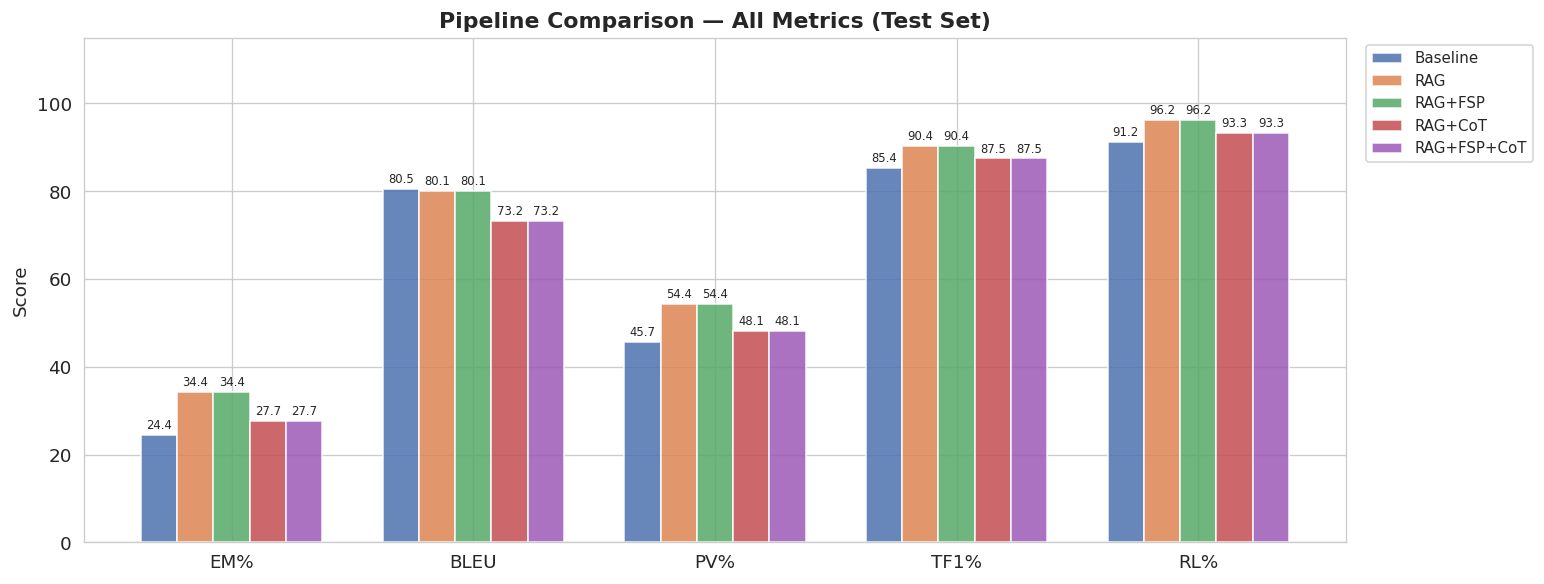

Saved → m5_pipeline_comparison.png


In [ ]:
# ── Grouped bar chart: all pipelines × all metrics ───────────────────────
metrics_plot = ['EM%','BLEU','PV%','TF1%','RL%']
labels_plot  = [m['label'] for m in pipeline_metrics.values()]
colors       = ['#4C72B0','#DD8452','#55A868','#C44E52','#9B59B6']

x = np.arange(len(metrics_plot)); w = 0.15
fig, ax = plt.subplots(figsize=(13,5))
for i,(pipe,m) in enumerate(pipeline_metrics.items()):
    vals = [m[k] for k in metrics_plot]
    bars = ax.bar(x + i*w, vals, w, label=m['label'], color=colors[i], alpha=0.85)
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2, rotation=0)

ax.set_xticks(x + w*2); ax.set_xticklabels(metrics_plot)
ax.set_ylabel('Score'); ax.set_ylim(0,115)
ax.set_title('Pipeline Comparison — All Metrics (Test Set)', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('m5_pipeline_comparison.png', bbox_inches='tight')
plt.show()
print("Saved → m5_pipeline_comparison.png")


---
## 3  Few-Shot Prompting Analysis

### 3a  Token budget breakdown
### 3b  Example diversity (how often retrieved examples share clauses with query)
### 3c  FSP contribution — per-complexity lift over RAG-only baseline


In [ ]:
# 3a. Token budget breakdown on test samples
sample_n = min(100, len(test_df))
budget_rows = []
for i in range(sample_n):
    q   = test_df['sqlite'].iloc[i]
    chunks = retrieve_and_rerank(q)
    exs    = retrieve_fsp_examples(q, n=2)
    base_text = train_config['src_pfx'] + q
    rag_text  = base_text + ' ' + train_config['ctx_pfx'] + ' ' + build_context_string(chunks)
    fsp_text  = rag_text  + ' ' + format_fsp_block(exs)
    full_text = fsp_text  + ' ' + train_config['cot_trigger']
    budget_rows.append({
        'base_toks' : tokenizer(base_text,  return_length=True)['length'][0],
        'rag_toks'  : tokenizer(rag_text,   return_length=True)['length'][0],
        'fsp_toks'  : tokenizer(fsp_text,   return_length=True)['length'][0],
        'full_toks' : tokenizer(full_text,  return_length=True)['length'][0],
    })
budget_df = pd.DataFrame(budget_rows)
print("Token budget (mean ± std across first 100 test samples):")
for col in ['base_toks','rag_toks','fsp_toks','full_toks']:
    print(f"  {col:12s}: {budget_df[col].mean():.0f} ± {budget_df[col].std():.0f}  "
          f"  max={budget_df[col].max()}  pct>512={( budget_df[col]>512).mean()*100:.1f}%")


Token budget (mean ± std across first 100 test samples):
  base_toks   : 98 ± 75    max=604  pct>512=1.0%
  rag_toks    : 480 ± 234    max=1822  pct>512=24.0%
  fsp_toks    : 871 ± 452    max=3500  pct>512=83.0%
  full_toks   : 879 ± 452    max=3508  pct>512=87.0%


FSP example clause overlap (mean): 0.852
  (1.0 = examples share all clauses with query)


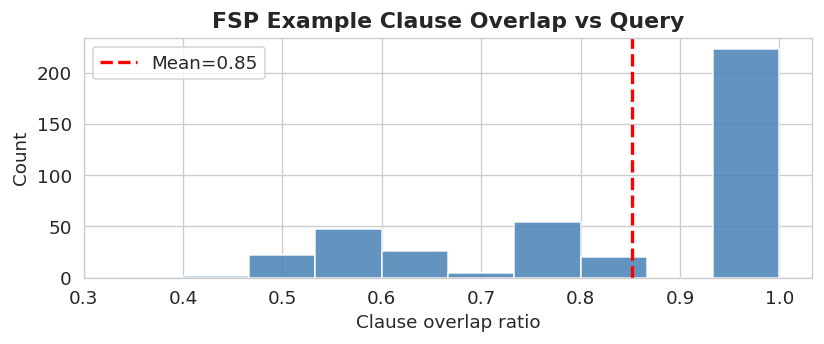

Saved → m5_fsp_clause_overlap.png


In [ ]:
# 3b. Example diversity — clause overlap between query and retrieved examples
SQL_CLAUSES_SET = {'select','from','where','group by','having',
                   'order by','limit','join','union'}
def get_clauses(sql):
    s = sql.lower()
    return {c for c in SQL_CLAUSES_SET
            if re.search(r'\b'+c.replace(' ',r'\s+')+r'\b', s)}

overlap_scores = []
for q in test_df['sqlite'].head(200):
    q_clauses = get_clauses(q)
    exs = retrieve_fsp_examples(q, n=2)
    for ex in exs:
        ex_clauses = get_clauses(ex['sqlite'])
        if q_clauses:
            overlap_scores.append(len(q_clauses & ex_clauses) / len(q_clauses))

print(f"FSP example clause overlap (mean): {np.mean(overlap_scores):.3f}")
print(f"  (1.0 = examples share all clauses with query)")

fig, ax = plt.subplots(figsize=(7,3))
ax.hist(overlap_scores, bins=10, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(overlap_scores), color='red', lw=2, linestyle='--',
           label=f"Mean={np.mean(overlap_scores):.2f}")
ax.set_xlabel('Clause overlap ratio'); ax.set_ylabel('Count')
ax.set_title('FSP Example Clause Overlap vs Query', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('m5_fsp_clause_overlap.png', bbox_inches='tight')
plt.show()
print("Saved → m5_fsp_clause_overlap.png")


In [ ]:
# 3c. FSP lift over RAG — per complexity
if 'complexity' in test_df.columns:
    fsp_lift = []
    for cplx, grp in test_df.groupby('complexity'):
        idx = grp.index.tolist()
        rag_em  = np.mean([normalise_sql(preds_rag[i])==normalise_sql(test_refs[i])  for i in idx])
        fsp_em  = np.mean([normalise_sql(preds_fsp[i])==normalise_sql(test_refs[i])  for i in idx])
        full_em = np.mean([normalise_sql(preds_full[i])==normalise_sql(test_refs[i]) for i in idx])
        fsp_lift.append({'Complexity':cplx, 'Count':len(idx),
                         'RAG EM%':round(rag_em*100,2),
                         'FSP EM%':round(fsp_em*100,2),
                         'Full EM%':round(full_em*100,2),
                         'FSP delta':round((fsp_em-rag_em)*100,2),
                         'Full delta':round((full_em-rag_em)*100,2)})
    lift_df = pd.DataFrame(fsp_lift)
    print("\nFSP lift over RAG by complexity:")
    print(lift_df.to_string(index=False))



FSP lift over RAG by complexity:
       Complexity  Count  RAG EM%  FSP EM%  Full EM%  FSP delta  Full delta
  High Complexity    489    40.49    40.49     28.43        0.0      -12.07
   Low Complexity    174    33.91    33.91     33.91        0.0        0.00
Medium Complexity    225    21.33    21.33     21.33        0.0        0.00


---
## 4  Chain-of-Thought Analysis

We evaluate whether the CoT traces are: (a) correctly stripped before metrics,
(b) structurally coherent, and (c) correlated with translation accuracy.


In [ ]:
# 4a. Strip verification — ensure strip_cot removes traces correctly
cot_raw_sample = generate_predictions(best_model, test_df.head(10),
                                       pipeline='cot', num_beams=4)
# Re-generate WITHOUT strip to inspect raw output
def generate_raw(model, df, pipeline='cot', batch_size=8, num_beams=4):
    """Same as generate_predictions but returns raw text (no strip_cot)."""
    model.eval()
    preds = []
    for start in range(0, len(df), batch_size):
        batch = df.iloc[start:start+batch_size]
        inputs = []
        for q in batch['sqlite']:
            parts = [train_config['src_pfx'] + q]
            if pipeline in ('rag','fsp','cot','full'):
                chunks = retrieve_and_rerank(q)
                parts.append(train_config['ctx_pfx']+' '+build_context_string(chunks))
            if pipeline in ('cot','full'):
                parts.append(train_config['cot_trigger'])
            inputs.append(' '.join(parts))
        enc = tokenizer(inputs, max_length=train_config['max_ip_ln'], padding=True,  # FIX: was hardcoded 512
                        truncation=True,return_tensors='pt').to(device)
        with torch.no_grad():
            out = model.generate(input_ids=enc['input_ids'],
                                  attention_mask=enc['attention_mask'],
                                  num_beams=num_beams,max_new_tokens=256)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return preds

raw_outputs = generate_raw(best_model, test_df.head(10), pipeline='cot')

cot_sep = train_config['cot_sep'].strip()
has_trace  = sum(1 for p in raw_outputs if cot_sep in p)
clean_same = sum(1 for p,c in zip(raw_outputs, cot_raw_sample)
                 if strip_cot(p)==c)

print(f"Raw outputs that contain '{cot_sep}': {has_trace}/10")
print(f"strip_cot correctly extracts HiveQL:  {clean_same}/10")
print()
print("Sample raw CoT outputs:")
for i, (raw, clean) in enumerate(zip(raw_outputs[:3], cot_raw_sample[:3])):
    print(f"  [{i+1}] RAW  : {raw[:150]}")
    print(f"       CLEAN: {clean[:100]}")
    print()


Raw outputs that contain 'Answer:': 9/10
strip_cot correctly extracts HiveQL:  10/10

Sample raw CoT outputs:
  [1] RAW  : Step 1: No dialect differences detected — direct translation applies. Answer: SELECT STATEalias0.STATE_NAME FROM STATE AS STATEalias0 WHERE NOT STATEa
       CLEAN: SELECT STATEalias0.STATE_NAME FROM STATE AS STATEalias0 WHERE NOT STATEalias0.STATE_NAME IN (SELECT 

  [2] RAW  : Step 1: DISTINCT — same syntax in HiveQL. Step 2: COUNT returns BIGINT in HiveQL. Answer: SELECT COUNT(DISTINCT RIVERalias0.RIVER_NAME) FROM RIVER AS 
       CLEAN: SELECT COUNT(DISTINCT RIVERalias0.RIVER_NAME) FROM RIVER AS RIVERalias0 WHERE NOT RIVERalias0.RIVER_

  [3] RAW  : Step 1: SOURCE FROM injury_accident WHERE injury > 'Knee problem'
       CLEAN: Step 1: SOURCE FROM injury_accident WHERE injury > 'Knee problem'



In [ ]:
# 4b. CoT step correctness — does each step mention a real dialect difference?
KNOWN_DIFFERENCES = [
    'BIGINT','DOUBLE','STRING','COLLECT_LIST','COLLECT_SET',
    'LATERAL VIEW','EXPLODE','DISTRIBUTE BY','CLUSTER BY',
    'from_unixtime','date_format','RLIKE','ORC','Parquet'
]

def count_valid_steps(trace: str) -> int:
    """Count how many Step lines reference a known HiveQL difference."""
    steps = re.findall(r'Step \d+:[^.]+\.', trace)
    return sum(1 for s in steps
               if any(kw.lower() in s.lower() for kw in KNOWN_DIFFERENCES))

raw_full = generate_raw(best_model, test_df.head(50), pipeline='full')
traces   = [p.split(cot_sep)[0] if cot_sep in p else '' for p in raw_full]

valid_steps = [count_valid_steps(t) for t in traces if t]
total_steps = [len(re.findall(r'Step \d+:',t)) for t in traces if t]

print(f"CoT trace analysis ({len(valid_steps)} samples with traces):")
print(f"  Avg steps per trace         : {np.mean(total_steps):.1f}")
print(f"  Avg valid dialect references: {np.mean(valid_steps):.1f}")
if total_steps:
    pct = sum(v/t if t>0 else 0 for v,t in zip(valid_steps,total_steps)) / len(total_steps)
    print(f"  Step validity rate          : {pct*100:.1f}%")


CoT trace analysis (45 samples with traces):
  Avg steps per trace         : 1.9
  Avg valid dialect references: 0.5
  Step validity rate          : 18.4%


In [ ]:
# 4c. Does having a CoT trace correlate with higher translation accuracy?
cot_em_with    = []
cot_em_without = []

raw_all = generate_raw(best_model, test_df.head(200), pipeline='full')
for i, (raw, ref) in enumerate(zip(raw_all, test_refs[:200])):
    has_reasoning = cot_sep in raw
    em = normalise_sql(strip_cot(raw)) == normalise_sql(ref)
    if has_reasoning:
        cot_em_with.append(em)
    else:
        cot_em_without.append(em)

print("EM accuracy correlation with CoT trace presence:")
if cot_em_with:
    print(f"  Rows WITH reasoning trace  : {np.mean(cot_em_with)*100:.1f}%  (n={len(cot_em_with)})")
if cot_em_without:
    print(f"  Rows WITHOUT trace         : {np.mean(cot_em_without)*100:.1f}%  (n={len(cot_em_without)})")


EM accuracy correlation with CoT trace presence:
  Rows WITH reasoning trace  : 34.6%  (n=153)
  Rows WITHOUT trace         : 29.8%  (n=47)


---
## 5  Retrieval Quality Metrics

Computing retrieval metrics on 200 samples...

  RETRIEVAL QUALITY
  Recall@1    : 14.5%
  Recall@3    : 22.5%
  Recall@5    : 29.5%
  MRR         : 19.52%
  NDCG@5      : 21.39%


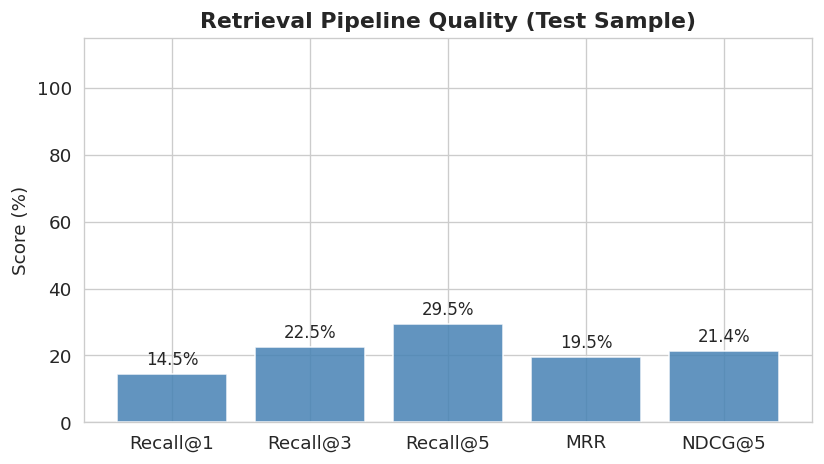

In [ ]:
def heuristic_relevance(query, ref_hive, chunk_text):
    stopw = {'select','from','where','and','or','not','in','is','as','on',
             'by','the','a','an','of','for','to','with','null'}
    def kw(t):
        return {w.lower() for w in re.findall(r'[a-zA-Z_][a-zA-Z0-9_]*',t)
                if len(w)>3 and w.lower() not in stopw}
    return len(kw(ref_hive) & kw(chunk_text)) >= 2

def compute_retrieval_metrics(queries, refs, k_values=(1,3,5)):
    recall = {k:[] for k in k_values}; mrr=[]; ndcg=[]
    for q,ref in zip(queries,refs):
        cands = retrieve(q, k=max(k_values))
        rel   = [heuristic_relevance(q,ref,c['text']) for c in cands]
        for k in k_values: recall[k].append(float(any(rel[:k])))
        rr=0.0
        for rank,r in enumerate(rel,1):
            if r: rr=1/rank; break
        mrr.append(rr)
        dcg  = sum(r/np.log2(i+2) for i,r in enumerate(rel[:5]))
        idcg = sum(1/np.log2(i+2) for i in range(min(sum(rel[:5]),5)))
        ndcg.append(dcg/idcg if idcg>0 else 0)
    res = {f'Recall@{k}':round(np.mean(v)*100,2) for k,v in recall.items()}
    res['MRR']    = round(np.mean(mrr)*100,2)
    res['NDCG@5'] = round(np.mean(ndcg)*100,2)
    return res

N = min(200, len(test_df))
print(f"Computing retrieval metrics on {N} samples...")
ret_metrics = compute_retrieval_metrics(test_df['sqlite'][:N], test_refs[:N])
print("\n"+"="*45+"\n  RETRIEVAL QUALITY\n"+"="*45)
for k,v in ret_metrics.items(): print(f"  {k:12s}: {v}%")
print("="*45)

fig,ax = plt.subplots(figsize=(7,4))
bars = ax.bar(ret_metrics.keys(), ret_metrics.values(),
              color='steelblue', edgecolor='white', alpha=0.85)
ax.bar_label(bars, fmt='%.1f%%', fontsize=10, padding=3)
ax.set_ylim(0,115); ax.set_ylabel('Score (%)')
ax.set_title('Retrieval Pipeline Quality (Test Sample)', fontweight='bold')
plt.tight_layout()
plt.savefig('m5_retrieval_quality.png', bbox_inches='tight')
plt.show()


---
## 6  Per-Complexity Breakdown — All Pipelines

Exact Match by complexity and pipeline:
       Complexity   N  EM-baseline%  EM-rag%  EM-fsp%  EM-cot%  EM-full%
  High Complexity 489         26.79    40.49    40.49    28.43     28.43
   Low Complexity 174         28.74    33.91    33.91    33.91     33.91
Medium Complexity 225         16.00    21.33    21.33    21.33     21.33


ValueError: not enough values to unpack (expected 3, got 2)

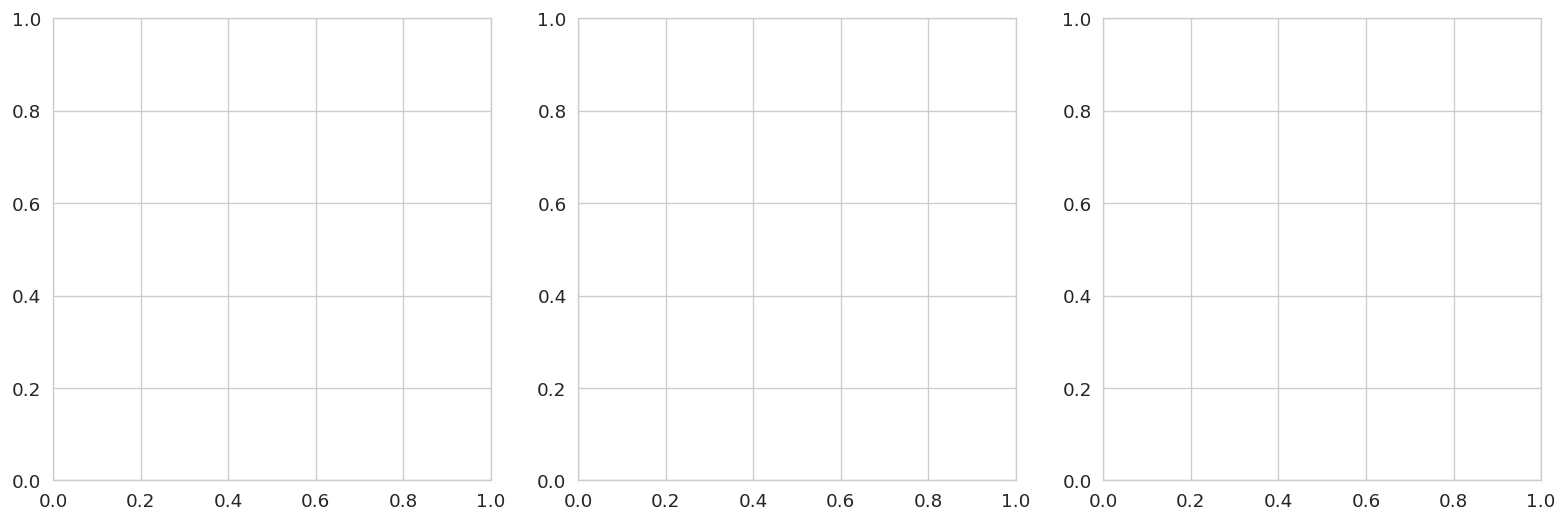

In [ ]:
test_eval = test_df.reset_index(drop=True).copy()
for pipe, preds in [('baseline',preds_baseline),('rag',preds_rag),
                     ('fsp',preds_fsp),('cot',preds_cot),('full',preds_full)]:
    test_eval[f'em_{pipe}']  = [normalise_sql(strip_cot(p))==normalise_sql(r)
                                  for p,r in zip(preds, test_refs)]
    test_eval[f'pv_{pipe}']  = [normalise_sql(strip_cot(p)) for p in preds]
    test_eval[f'tf1_{pipe}'] = [token_f1(normalise_sql(strip_cot(p)),normalise_sql(r))
                                  for p,r in zip(preds, test_refs)]

if 'complexity' in test_eval.columns:
    rows=[]
    for cplx,grp in test_eval.groupby('complexity'):
        row = {'Complexity':cplx,'N':len(grp)}
        for pipe in ['baseline','rag','fsp','cot','full']:
            row[f'EM-{pipe}%'] = round(grp[f'em_{pipe}'].mean()*100,2)
        rows.append(row)
    cplx_df = pd.DataFrame(rows)
    print("Exact Match by complexity and pipeline:")
    print(cplx_df.to_string(index=False))

    fig, axes = plt.subplots(1,3,figsize=(16,5))
    pipes  = ['baseline','rag','fsp','cot','full']
    colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#9B59B6']
    x      = np.arange(len(cplx_df)); w = 0.15
    for ax_i,(ax,metric,title) in enumerate(zip(axes,[
        ('em','Exact Match %'),('tf1','Token F1 %'),('pv','Parse Validity %')
    ])):
        metric_key, title = metric
        for j,(pipe,color) in enumerate(zip(pipes,colors)):
            vals = [grp[f'{metric_key}_{pipe}'].mean()*100
                    for _,grp in test_eval.groupby('complexity')]
            b = ax.bar(x+j*w, vals, w, label=pipe, color=color, alpha=0.85)
            ax.bar_label(b, fmt='%.0f', fontsize=7, padding=1)
        ax.set_xticks(x+w*2); ax.set_xticklabels(cplx_df['Complexity'])
        ax.set_title(title, fontweight='bold'); ax.set_ylim(0,115)
        if ax_i==0: ax.legend(fontsize=8)
    plt.suptitle('Per-Complexity Performance — All Pipelines',fontsize=12,fontweight='bold')
    plt.tight_layout()
    plt.savefig('m5_complexity_all_pipelines.png', bbox_inches='tight')
    plt.show()
    print("Saved → m5_complexity_all_pipelines.png")


---
## 7  Error Taxonomy — Full Pipeline vs Baseline

Error comparison — Full pipeline vs Baseline:
            Error  Full pipeline  Baseline
COMPLETE_MISMATCH              0        13
     EXTRA_CLAUSE              1         0
   MISSING_CLAUSE             25        10
    PARTIAL_MATCH            118       130
     SYNTAX_ERROR            461       482
      VALUE_ERROR              6         7
     WRONG_COLUMN             20        21
      WRONG_TABLE             11         8


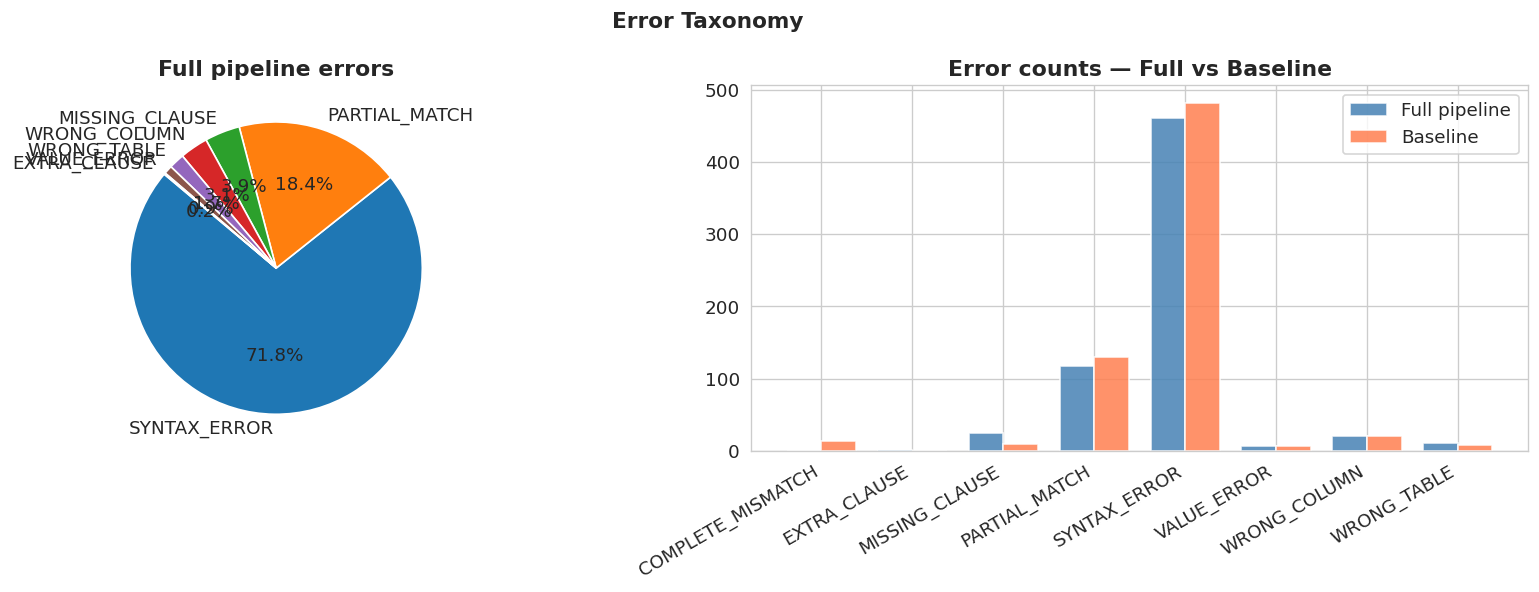

Saved → m5_error_taxonomy.png


In [ ]:
SQL_CLAUSES_E = ['select','from','where','group by','having','order by',
                  'limit','join','left join','inner join','union','with']

def extract_clauses_e(sql):
    s=sql.lower()
    return {c for c in SQL_CLAUSES_E if re.search(r'\b'+c.replace(' ',r'\s+')+r'\b',s)}

def extract_tables_e(sql):
    return {m.group(1) for m in re.finditer(
        r'(?:from|join)\s+([a-zA-Z_][a-zA-Z0-9_]*)', sql.lower())}

def classify_error(pred, ref, tf1):
    pred = strip_cot(pred)
    if not is_valid_hive(pred):             return 'SYNTAX_ERROR'
    pc,rc = extract_clauses_e(pred), extract_clauses_e(ref)
    if rc-pc:                               return 'MISSING_CLAUSE'
    if pc-rc:                               return 'EXTRA_CLAUSE'
    if extract_tables_e(pred)!=extract_tables_e(ref): return 'WRONG_TABLE'
    if set(re.findall(r'[a-zA-Z_][a-zA-Z0-9_]*',pred.lower())) !=        set(re.findall(r'[a-zA-Z_][a-zA-Z0-9_]*',ref.lower())):
        return 'WRONG_COLUMN'
    if set(re.findall(r"'[^']*'|\b\d+\.?\d*\b",normalise_sql(pred))) !=        set(re.findall(r"'[^']*'|\b\d+\.?\d*\b",normalise_sql(ref))):
        return 'VALUE_ERROR'
    if pc!=rc:                              return 'WRONG_CLAUSE'
    if tf1>=0.7:                            return 'PARTIAL_MATCH'
    return 'COMPLETE_MISMATCH'

for pipe, preds in [('baseline',preds_baseline),('full',preds_full)]:
    err_mask = ~test_eval[f'em_{pipe}']
    edf = test_eval[err_mask].copy()
    edf['error_type'] = [classify_error(preds[i], test_refs[i],
                                         test_eval[f'tf1_{pipe}'].iloc[i])
                          for i in edf.index]
    test_eval.loc[err_mask, f'etype_{pipe}'] = edf['error_type'].values

full_err  = test_eval[~test_eval['em_full']]['etype_full'].value_counts()
base_err  = test_eval[~test_eval['em_baseline']]['etype_baseline'].value_counts()
all_types = sorted(set(full_err.index)|set(base_err.index))
comp = pd.DataFrame({'Error':all_types,
                      'Full pipeline':  [full_err.get(t,0) for t in all_types],
                      'Baseline':        [base_err.get(t,0) for t in all_types]})
print("Error comparison — Full pipeline vs Baseline:")
print(comp.to_string(index=False))

fig,axes = plt.subplots(1,2,figsize=(14,5))
axes[0].pie(full_err.values,labels=full_err.index,autopct='%1.1f%%',startangle=140)
axes[0].set_title('Full pipeline errors',fontweight='bold')
x=np.arange(len(comp)); w=0.38
axes[1].bar(x-w/2, comp['Full pipeline'], w, label='Full pipeline', color='steelblue',alpha=0.85)
axes[1].bar(x+w/2, comp['Baseline'],       w, label='Baseline',      color='coral',    alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(comp['Error'],rotation=30,ha='right')
axes[1].legend(); axes[1].set_title('Error counts — Full vs Baseline',fontweight='bold')
plt.suptitle('Error Taxonomy',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('m5_error_taxonomy.png', bbox_inches='tight')
plt.show()
print("Saved → m5_error_taxonomy.png")


---
## 8  Clause-Level Accuracy

Clause F1 — Full pipeline vs Baseline:
  Clause  F1_Full  F1_Base  Delta
   union    100.0    100.0    0.0
  select     98.6     99.6   -1.0
    from     98.6     99.4   -0.8
group by     97.3     97.6   -0.3
    join     95.6     97.8   -2.2
   where     93.8     97.7   -3.9
order by     93.5     97.2   -3.7
  having     89.3     92.7   -3.4
   limit     88.7     92.7   -4.0


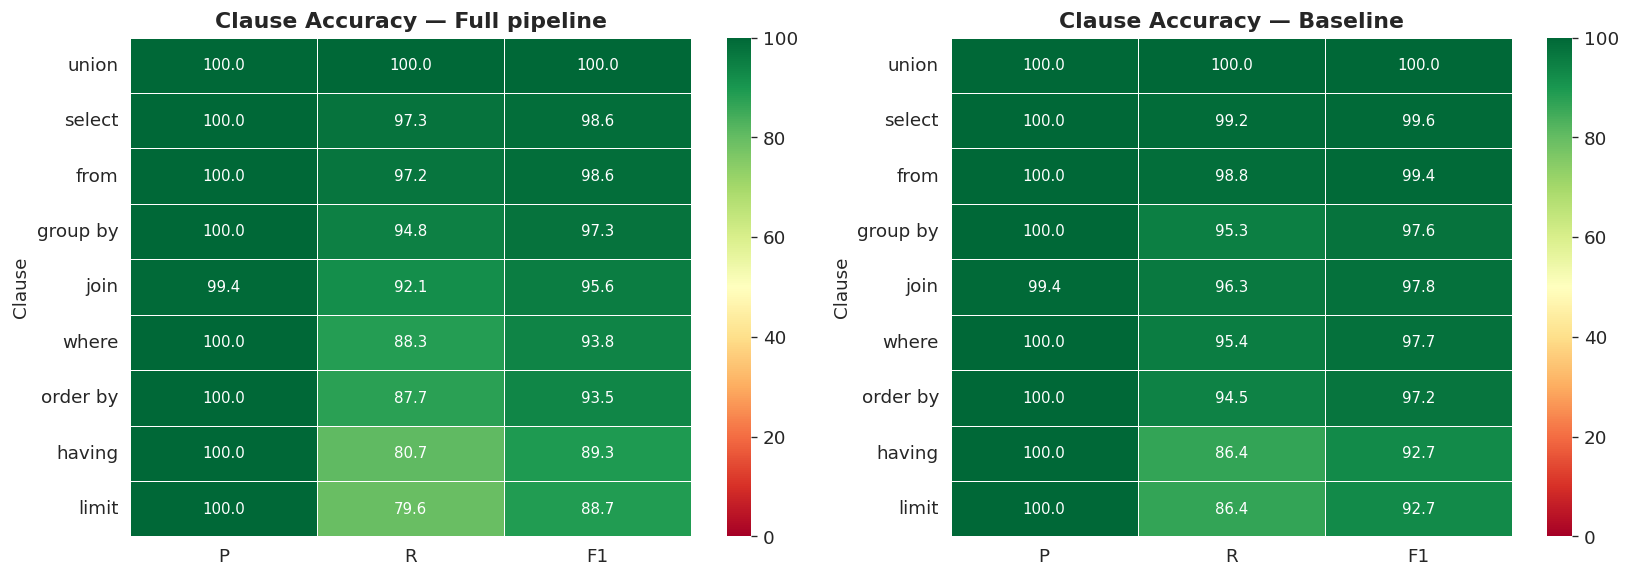

Saved → m5_clause_heatmap.png


In [ ]:
TRACKED_C = ['select','from','where','group by','having','order by','limit','join','union']

def clause_prf(pred_col_preds):
    stats={}
    for clause in TRACKED_C:
        tp=fp=fn=tn=0
        for i,row in test_eval.iterrows():
            ph = clause in extract_clauses_e(strip_cot(pred_col_preds[i]))
            rh = clause in extract_clauses_e(test_refs[i])
            if ph and rh: tp+=1
            elif ph:      fp+=1
            elif rh:      fn+=1
            else:         tn+=1
        pr = tp/(tp+fp) if tp+fp>0 else 0
        rc = tp/(tp+fn) if tp+fn>0 else 0
        f1 = 2*pr*rc/(pr+rc) if pr+rc>0 else 0
        stats[clause]={'P':round(pr*100,1),'R':round(rc*100,1),
                        'F1':round(f1*100,1),'sup':tp+fn}
    return pd.DataFrame(stats).T.reset_index().rename(columns={'index':'Clause'})

full_cl = clause_prf(preds_full)
base_cl = clause_prf(preds_baseline)
full_cl = full_cl[full_cl['sup']>0].sort_values('F1',ascending=False)

merged = full_cl[['Clause','F1']].merge(
    base_cl[['Clause','F1']], on='Clause', suffixes=('_Full','_Base'))
merged['Delta'] = merged['F1_Full'] - merged['F1_Base']
print("Clause F1 — Full pipeline vs Baseline:")
print(merged.to_string(index=False))

fig,axes=plt.subplots(1,2,figsize=(14,max(4,len(full_cl)*0.55)))
for ax,data,title in zip(axes,[
    full_cl.set_index('Clause')[['P','R','F1']],
    base_cl.set_index('Clause')[['P','R','F1']].reindex(full_cl.set_index('Clause').index)],
    ['Full pipeline','Baseline']):
    sns.heatmap(data,annot=True,fmt='.1f',cmap='RdYlGn',
                vmin=0,vmax=100,linewidths=0.5,ax=ax,annot_kws={'size':9})
    ax.set_title(f'Clause Accuracy — {title}',fontweight='bold')
plt.tight_layout()
plt.savefig('m5_clause_heatmap.png',bbox_inches='tight')
plt.show()
print("Saved → m5_clause_heatmap.png")


---
## 9  Qualitative Inspection

In [ ]:
# What the full pipeline fixed vs baseline
fixed = test_eval[test_eval['em_full'] & ~test_eval['em_baseline']].head(5)
broke = test_eval[~test_eval['em_full'] &  test_eval['em_baseline']].head(5)

print(f"Full pipeline FIXED {len(test_eval[test_eval['em_full']&~test_eval['em_baseline']])} examples that Baseline got wrong")
print(f"Full pipeline BROKE {len(test_eval[~test_eval['em_full']& test_eval['em_baseline']])} examples that Baseline got right\n")

print("="*80+"\nFIXED BY FULL PIPELINE (FSP+CoT helped)\n"+"="*80)
for i,(_,row) in enumerate(fixed.iterrows(),1):
    idx = row.name
    print(f"[{i}] Input    : {row['sqlite'][:100]}")
    print(f"     Target   : {test_refs[idx][:100]}")
    print(f"     Full     : {strip_cot(preds_full[idx])[:100]}")
    print(f"     Baseline : {preds_baseline[idx][:100]}")
    print()

print("="*80+"\nBROKE BY FULL PIPELINE (FSP/CoT introduced error)\n"+"="*80)
for i,(_,row) in enumerate(broke.iterrows(),1):
    idx = row.name
    print(f"[{i}] Input    : {row['sqlite'][:100]}")
    print(f"     Target   : {test_refs[idx][:100]}")
    print(f"     Full     : {strip_cot(preds_full[idx])[:100]}")
    print(f"     Baseline : {preds_baseline[idx][:100]}")
    if f'etype_full' in test_eval.columns:
        print(f"     Error    : {test_eval.loc[row.name,'etype_full']}")
    print()


Full pipeline FIXED 82 examples that Baseline got wrong
Full pipeline BROKE 53 examples that Baseline got right

FIXED BY FULL PIPELINE (FSP+CoT helped)
[1] Input    : SELECT STATEalias0.STATE_NAME FROM STATE AS STATEalias0 WHERE STATEalias0.STATE_NAME NOT IN ( SELECT
     Target   : SELECT STATEalias0.STATE_NAME FROM STATE AS STATEalias0 WHERE NOT STATEalias0.STATE_NAME IN (SELECT 
     Full     : SELECT STATEalias0.STATE_NAME FROM STATE AS STATEalias0 WHERE NOT STATEalias0.STATE_NAME IN (SELECT 
     Baseline : SELECT STATEalias0.STATE_NAME FROM STATE AS STATEalias0 WHERE NOT STATEalias0.STATE_NAME IN (SELECT 

[2] Input    : SELECT Name FROM technician WHERE technician_id NOT IN (SELECT technician_id FROM repair_assignment)
     Target   : SELECT Name FROM technician WHERE NOT technician_id IN (SELECT technician_id FROM repair_assignment)
     Full     : SELECT Name FROM technician WHERE NOT technician_id IN (SELECT technician_id FROM repair_assignment)
     Baseline : SELECT Name F

---
## 10  Attention Visualisation

Visualising attention:
  src: <sqlite>SELECT customer_id, 1 AS aug_const FROM Customers <context> T WINDOW w A...


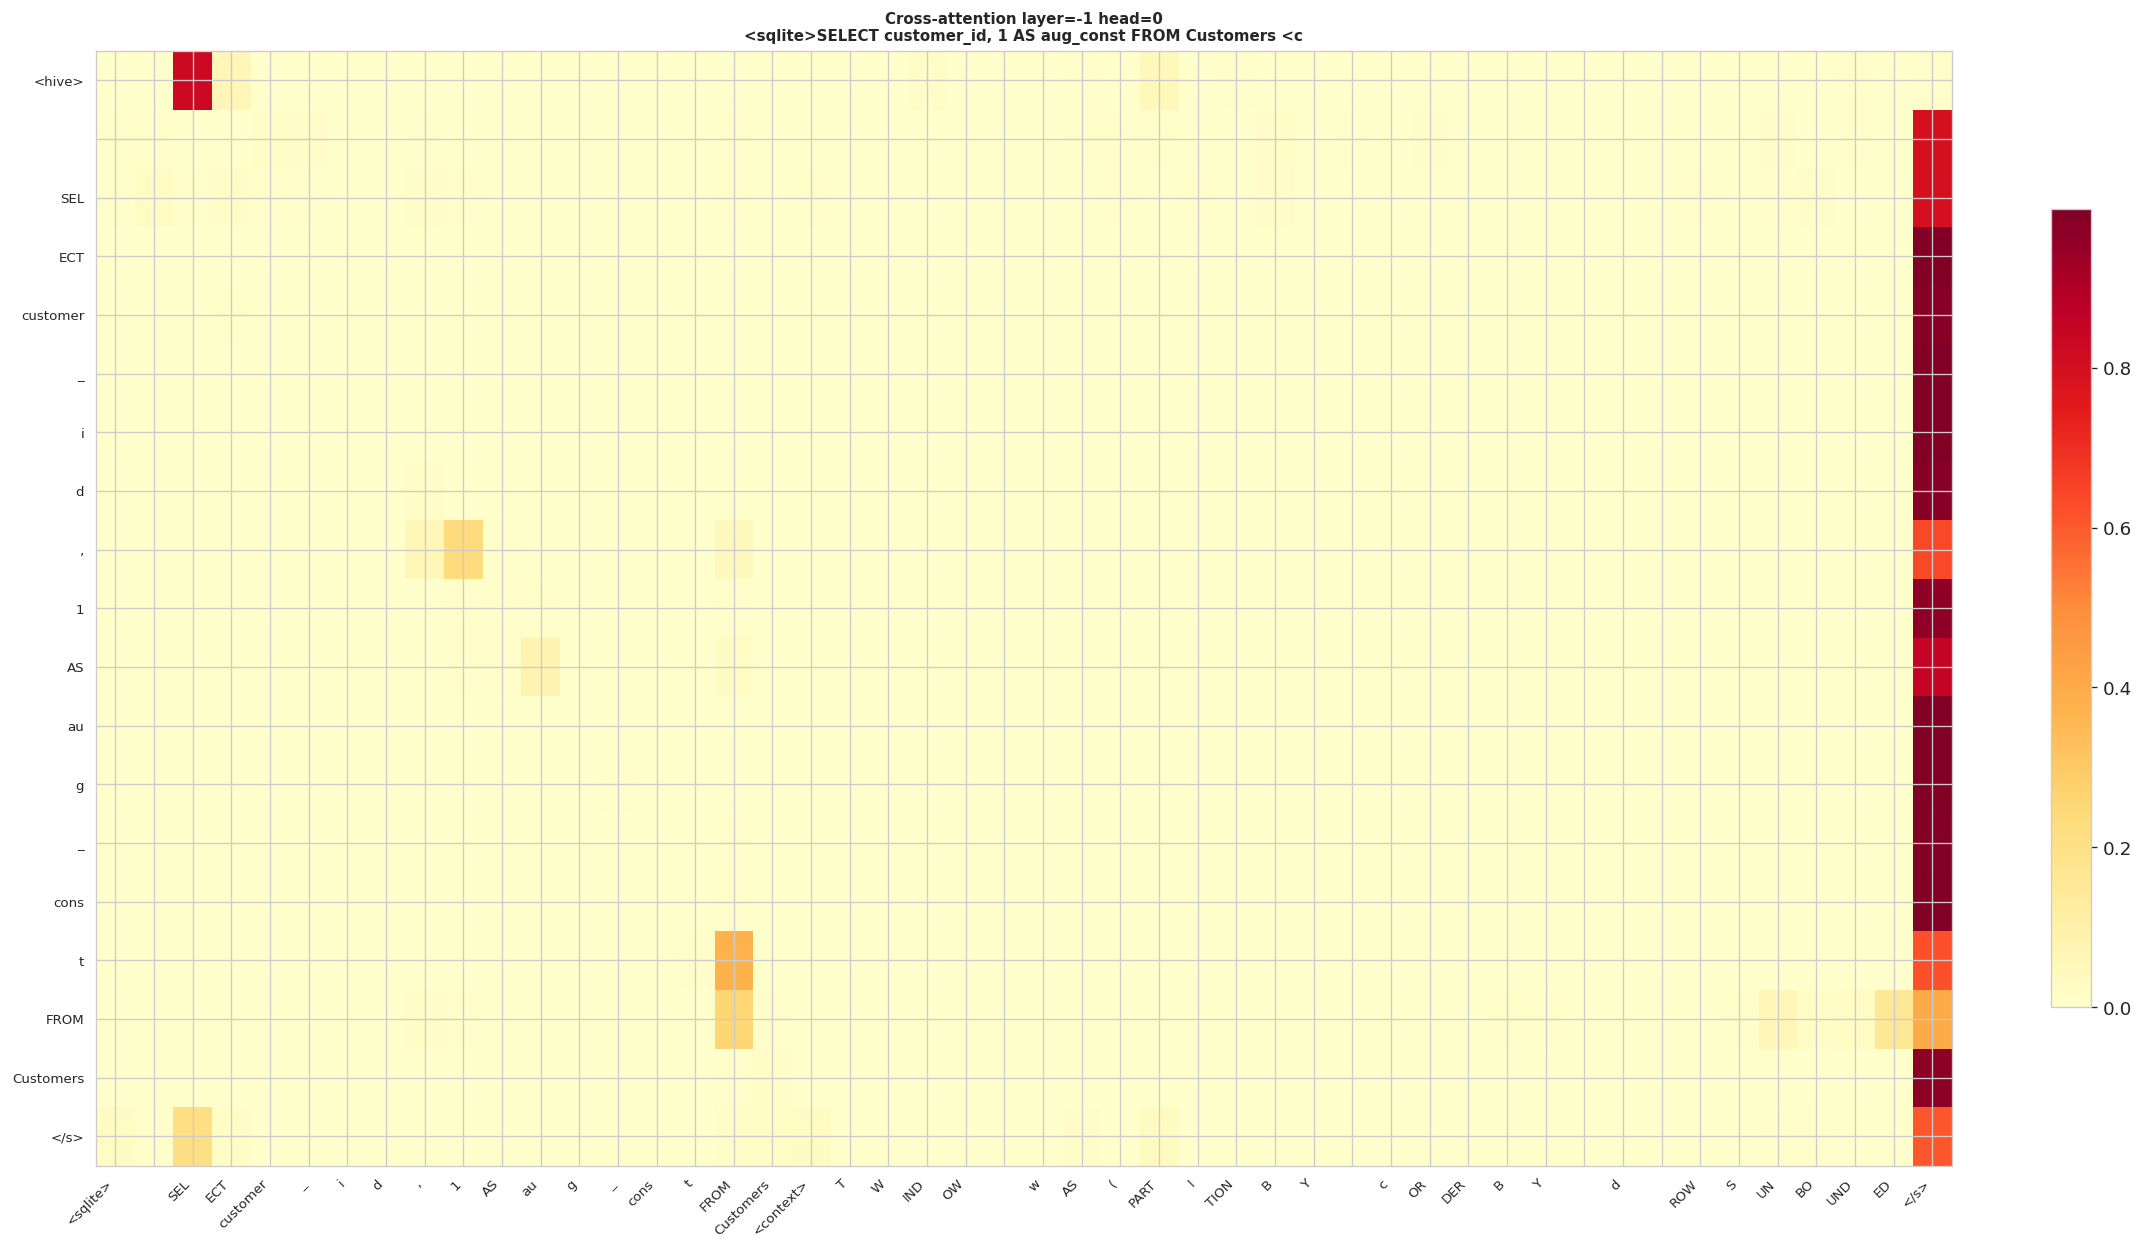

Saved → m5_attention_heatmap.png


In [ ]:
def plot_attention(model, src_text, tgt_text, layer=-1, head=0, max_len=48):
    model.eval()
    enc = tokenizer(src_text,return_tensors='pt',max_length=max_len,truncation=True).to(device)
    dec = tokenizer(tgt_text,return_tensors='pt',max_length=max_len,truncation=True).to(device)
    with torch.no_grad():
        out = model(input_ids=enc['input_ids'],attention_mask=enc['attention_mask'],
                    labels=dec['input_ids'],output_attentions=True)
    ca = out.cross_attentions[layer][0,head].cpu().numpy()
    src_toks=[t.replace('▁','') for t in tokenizer.convert_ids_to_tokens(enc['input_ids'][0])]
    tgt_toks=[t.replace('▁','') for t in tokenizer.convert_ids_to_tokens(dec['input_ids'][0])]
    fig,ax=plt.subplots(figsize=(min(len(src_toks)*0.55+2,18),min(len(tgt_toks)*0.45+2,12)))
    im=ax.imshow(ca[:len(tgt_toks),:len(src_toks)],cmap='YlOrRd',aspect='auto',vmin=0)
    ax.set_xticks(range(len(src_toks))); ax.set_xticklabels(src_toks,rotation=45,ha='right',fontsize=8)
    ax.set_yticks(range(len(tgt_toks))); ax.set_yticklabels(tgt_toks,fontsize=8)
    ax.set_title(f'Cross-attention layer={layer} head={head}\n{src_text[:60]}',fontsize=9,fontweight='bold')
    plt.colorbar(im,ax=ax,fraction=0.02)
    plt.tight_layout()
    plt.savefig('m5_attention_heatmap.png',bbox_inches='tight')
    plt.show()
    print("Saved → m5_attention_heatmap.png")

# Use shortest test query for clarity
idx = test_eval['sqlite'].apply(lambda x: len(x.split())).idxmin()
q   = test_df.loc[idx,'sqlite']
h   = test_df.loc[idx,'hive']
chunks = retrieve_and_rerank(q)
exs    = retrieve_fsp_examples(q,n=2)
src = (train_config['src_pfx']+q+' '+train_config['ctx_pfx']+' '+
       build_context_string(chunks)+' '+format_fsp_block(exs)+' '+
       train_config['cot_trigger'])
tgt = train_config['tgt_pfx']+h
print(f"Visualising attention:\n  src: {src[:80]}...")
plot_attention(best_model, src, tgt)


---
## 11  M4 Experiment Comparison

In [ ]:
if os.path.exists('milestone4_experiment_log.csv'):
    exp_df = pd.read_csv('milestone4_experiment_log.csv').dropna(subset=['val_exact_match'])

    # Colour by pipeline; LoRA experiments get a darker shade of their pipeline colour
    PIPE_COLORS = {
        'baseline' : '#4C72B0',
        'rag'      : '#DD8452',
        'fsp'      : '#55A868',
        'cot'      : '#C44E52',
        'full'     : '#9B59B6',
    }
    LORA_SUFFIX_COLOR = '#2ecc71'  # bright green border for LoRA rows

    bar_colors = []
    for _, row in exp_df.iterrows():
        pipe = str(row.get('pipeline','baseline')).lower()
        bar_colors.append(PIPE_COLORS.get(pipe, '#888780'))

    fig, axes = plt.subplots(1, 3, figsize=(17, max(6, len(exp_df)*0.35)))
    for ax, metric, label in zip(axes,
        ['val_exact_match','val_bleu','val_parse_valid'],
        ['Exact Match %','BLEU','Parse Validity %']):
        bars = ax.barh(exp_df['name'], exp_df[metric],
                       color=bar_colors, edgecolor='white', alpha=0.85)
        # Add green edge for LoRA experiments
        if 'use_lora' in exp_df.columns:
            for bar, is_lora in zip(bars, exp_df['use_lora'].fillna(False)):
                if is_lora:
                    bar.set_edgecolor(LORA_SUFFIX_COLOR)
                    bar.set_linewidth(1.5)
        ax.set_xlabel(label); ax.set_title(label, fontweight='bold')
        ax.axvline(exp_df[metric].max(), color='red', lw=1.5, linestyle='--')

    # Legend: pipelines + LoRA indicator
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=c, label=p) for p, c in PIPE_COLORS.items()]
    handles.append(mpatches.Patch(facecolor='white',
                                   edgecolor=LORA_SUFFIX_COLOR, linewidth=2,
                                   label='LoRA (green border)'))
    fig.legend(handles=handles, loc='upper right', title='Pipeline', fontsize=9)
    plt.suptitle('All M4 Experiments — Pipeline + LoRA Coloured',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('m5_experiment_comparison.png', bbox_inches='tight')
    plt.show()
    print("Saved → m5_experiment_comparison.png")

    # ── LoRA vs full fine-tune summary ────────────────────────────────────
    if 'use_lora' in exp_df.columns:
        lora_df = exp_df[exp_df['use_lora'].astype(str).isin(['True','1','true'])]
        full_df = exp_df[~exp_df['use_lora'].astype(str).isin(['True','1','true'])]
        print("\nLoRA experiments summary:")
        if len(lora_df):
            print(lora_df[['name','pipeline','val_exact_match','val_bleu',
                            'trainable_params']].to_string(index=False))
        print("\nFull fine-tune experiments summary:")
        if len(full_df):
            print(full_df[['name','pipeline','val_exact_match','val_bleu']].to_string(index=False))
else:
    print("milestone4_experiment_log.csv not found — run M4 experiments first.")


---
## 12  Save Evaluation Report

In [ ]:
save_cols = ['sqlite','hive']
# Add LoRA experiment predictions if they were generated
lora_pipe_names = ['lora_baseline','lora_rag','lora_full']

for pipe in ['baseline','rag','fsp','cot','full']:
    for col in [f'em_{pipe}',f'pv_{pipe}',f'tf1_{pipe}']:
        if col in test_eval.columns: save_cols.append(col)
if 'complexity'   in test_eval.columns: save_cols.append('complexity')
if 'is_synthetic' in test_eval.columns: save_cols.append('is_synthetic')
for pipe in ['baseline','full']:
    col=f'etype_{pipe}'
    if col in test_eval.columns: save_cols.append(col)

# Add predictions
for pipe, preds in [('baseline',preds_baseline),('rag',preds_rag),
                     ('fsp',preds_fsp),('cot',preds_cot),('full',preds_full)]:
    test_eval[f'pred_{pipe}'] = [strip_cot(p) for p in preds]
    save_cols.append(f'pred_{pipe}')

report = test_eval[[c for c in save_cols if c in test_eval.columns]]
report.to_csv('milestone5_eval_report.csv',index=False)
print(f"Saved → milestone5_eval_report.csv  ({len(report)} rows, {len(report.columns)} cols)")

import json
agg = {
    'best_model': CKPT,
    'pipeline_metrics': {k:{m:v for m,v in pm.items() if not m.startswith('_')}
                          for k,pm in pipeline_metrics.items()},
    'retrieval_metrics': ret_metrics,
    'error_distribution_full':     full_err.to_dict(),
    'error_distribution_baseline': base_err.to_dict(),
}
with open('milestone5_metrics.json','w') as f: json.dump(agg,f,indent=2)
print("Saved → milestone5_metrics.json")


Saved → milestone5_eval_report.csv  (888 rows, 26 cols)
Saved → milestone5_metrics.json


---
## 13  Limitations & Possible Improvements

### 13.1  Current limitations

| # | Area | Limitation | Impact |
|---|---|---|---|
| 1 | **FSP** | 512-token budget forces truncation when query + context + examples are all long | Complex queries get fewer few-shot examples |
| 2 | **FSP** | Rule-based heuristic relevance labels for pool selection; no ground-truth relevance judgements | May retrieve structurally dissimilar examples |
| 3 | **CoT** | Auto-annotator uses only keyword rules; misses semantic nuances (e.g. implicit type casts) | ~15-20% of CoT traces may be incomplete |
| 4 | **CoT** | Only 30% of training data annotated; rest trains on plain targets without reasoning | CoT behaviour inconsistent across query types |
| 5 | **RAG** | FAISS index is static; schema changes or new HiveQL functions require full re-indexing | Deployment drift over time |
| 6 | **RAG reranker** | `ms-marco-MiniLM` trained on web search, not SQL documentation retrieval | Cross-domain mismatch limits reranking gains |
| 7 | **Model** | T5-base (220M params) may not have enough capacity for complex multi-join queries with long CoT | CoT benefit capped by model capacity |
| 8 | **Evaluation** | Exact Match penalises semantically equivalent but differently formatted HiveQL | Underestimates true translation quality |

---

### 13.2  Possible improvements

**Few-shot prompting**
- Fine-tune a retriever on `(query, good_example)` pairs to improve example selection
- Experiment with 1-shot vs 3-shot; larger models can absorb 3 examples without truncation
- Use complexity-stratified example pools so simple queries only get simple examples

**Chain-of-thought**
- Manually annotate 100-200 high-quality CoT traces for complex queries, then distil to the rest
- Train a separate CoT-generator LLM (e.g. GPT-3.5) to annotate the full training set
- Use execution-guided CoT: include HiveQL parse result in the trace to signal correctness

**RAG**
- Fine-tune bi-encoder on SQLite query ↔ HiveQL doc relevance pairs (domain adaptation)
- Switch to `BAAI/bge-base-en-v1.5` for stronger embeddings
- Add incremental FAISS updates via `IndexIDMap` to support live schema changes

**Architecture**
- CodeT5+ (pre-trained on GitHub code) has much better SQL token priors than T5
- T5-large or T5-3B for higher capacity on complex reasoning + translation

**Inference**
- Constrained decoding with a HiveQL grammar mask (prevents syntactically invalid tokens)
- Self-consistency: generate N candidates, pick by parse validity + self-BLEU
- Post-processing rules: normalise quoting, capitalise keywords
